# <center> Redes neuronales para el Procesamiento del Lenguaje Natural </center>  
# <center> Práctica final </center>



# Detección de lenguaje ofensivo en redes sociales
## Jesús Ferrándiz Alarcón

En esta práctica vamos a utilizar el dataset OffendES el cual contiene 13368 instancias de entrenamiento y 3342 instancias 
de test. Tiene las siguientes etiquetas:
* Ofensivo, el objetivo es una persona (OFP)
* Ofensivo, el objetivo es un grupo de personas o colectivo (OFG)
* No ofensivo, aunque con lenguaje inapropiado o insultante (NOM)
* No ofensivo (NO)

Vamos a resolver la tarea de detección de lenguaje ofensivo a partir del entrenamiento de algoritmos de
aprendizaje automático en este dataset para clasificar las 4 clases mencionadas o la agrupación de estas en Ofensivo, No ofensivo.
Primero, vamos a definir unos baselines para tener unos resultados de referencia. Y posteriormente, vamos a entrenar
algoritmos basados en aprendizaje profundo y a compararlos entre ellos y con los baselines.

# Instalación

Proporciono un fichero **requirements.txt** que reproduce el entorno de Python de la práctica. Para instalarlo, ejecutar:
```bash
pip install -r requirements.txt
```

# Análisis de Datos y Representación de Textos

## Carga y visualización de datos

In [1]:
# Librerias necesarias
# Matplotlib conf
import matplotlib.pyplot as plt
%matplotlib inline
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 5),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':40,
         'ytick.labelsize': 40
}
plt.rcParams.update(params)
# Seaborn conf
import seaborn as sns
sns.set(style='darkgrid')
sns.set_palette(sns.color_palette("Blues"))

import sys

#Procesado de datos
import pandas as pd
import numpy as np
import operator

#Modelos
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
training_set = pd.read_csv('../OffendES_dataset/offendes/train.csv')
print(f"Training set shape: {training_set.shape}, columns: {training_set.columns.tolist()}")
test_set = pd.read_csv('../OffendES_dataset/offendes/test.csv')
print(f"Test set shape: {test_set.shape}, columns: {test_set.columns.tolist()}")

Training set shape: (13368, 3), columns: ['comment_id', 'comment', 'label']
Test set shape: (3342, 3), columns: ['comment_id', 'comment', 'label']


In [3]:
# Inspeccionamos el aspecto del conjunto de entrenamiento
training_set.head(20)

,comment_id,comment,label
0,2081,Dalas: hace una pregunta retórica Turbobo: *...,NO
1,21214,Por qué no solamente le diste a una fundación ...,NO
2,40888,Te ves guapísima y brillante con ese nuevo loo...,NO
3,40790,Se esta hablando de que Ariana Grande esta rel...,NO
4,55889,¡¡HAGO REVIEWS DE SERIES Y PELIS!! ¿ Quieres e...,NO
5,41294,"YouTube ya no es como antes, como en esos tiem...",NO
6,33127,Entrar a YouTube después de un día de mierda y...,NOM
7,40612,"Oye y no se puede pagar el curso, hacerlo y de...",NO
8,22418,"Hombre, Javi, se sobreentiende que cuando dice...",NO
9,18623,Lo que habla del hate de él y badabun yo creo ...,NO


In [4]:
# Inspeccionamos el aspecto del conjunto de test
test_set.head(20)

,comment_id,comment,label
0,30327,Eres el mejor Dalas no hagas caso a los haters...,NO
1,32217,La ballena blanca es el único mamífero que a c...,NO
2,799,"Sisi,yo ya estoy harta de él,y pensar que me g...",NO
3,12385,No quiero ser hater ni criticar mira mas abajo...,NO
4,10931,"Lo que dice el Rubius es cierto, mucha gente a...",NO
5,45843,Es el primer video q no me gusta !! Jeje miare...,NO
6,41627,windy por favor >:v deja de gritar me esta la...,NO
7,10540,De aquí a comentar a ese maldito video,NO
8,25087,Te odio BUUUU FALSA,OFP
9,18286,Haz un video opinando de la empresa in cruises...,NO


Vamos a revisar las etiquetas. Quiero ver que no haya errores de etiquetado en el sentido de que ninguna muestra
tenga alguna etiqueta que no sea ['NO', 'NOM', 'OFP', 'OFG'].

In [5]:
unique_labels_train = training_set['label'].unique()
print(f'Unique labels in training set: {unique_labels_train}')
unique_labels_test = test_set['label'].unique()
print(f'Unique labels in test set: {unique_labels_test}')

assert set(unique_labels_train) == set(unique_labels_test), "Train and test sets have different labels"

Unique labels in training set: <ArrowStringArray>
['NO', 'NOM', 'OFP', 'OFG']
Length: 4, dtype: str
Unique labels in test set: <ArrowStringArray>
['NO', 'OFP', 'NOM', 'OFG']
Length: 4, dtype: str


Las etiquetas son correctas. Todas las muestras tienen un valor que pertenece a la lista de etiquetas que esperábamos.

Ahora voy a crear una columna nueva para unir las etiquetas en 'Offensive' y 'No offensive'.

In [6]:
# Mapping dictionary
label_mapping = {
    'OFP': 'Offensive',
    'OFG': 'Offensive',
    'NOM': 'No offensive',
    'NO':  'No offensive'
}

# Apply mapping to create the new column
training_set['joint_label'] = training_set['label'].map(label_mapping)
test_set['joint_label']     = test_set['label'].map(label_mapping)

In [7]:
unique_labels_train = training_set['joint_label'].unique()
print(f'Unique labels in training set: {unique_labels_train}')
unique_labels_test = test_set['joint_label'].unique()
print(f'Unique labels in test set: {unique_labels_test}')

assert set(unique_labels_train) == set(unique_labels_test), "Train and test sets have different labels"

Unique labels in training set: <ArrowStringArray>
['No offensive', 'Offensive']
Length: 2, dtype: str
Unique labels in test set: <ArrowStringArray>
['No offensive', 'Offensive']
Length: 2, dtype: str


In [8]:
accepted_labels = {'No offensive', 'Offensive'}
rows_with_problems = training_set[training_set.joint_label.isin(accepted_labels) == False]
rows_with_problems

,comment_id,comment,label,joint_label


In [9]:
dataset = pd.concat([training_set, test_set])
dataset.shape
dataset.columns

Index(['comment_id', 'comment', 'label', 'joint_label'], dtype='str')

### Distribución de las muestras de entrenamiento
Ahora vamos a ver las distribución de las muestras en el set de datos de entrenamiento.

([0, 1, 2, 3],
 [Text(0, 0, 'NO'), Text(1, 0, 'OFP'), Text(2, 0, 'NOM'), Text(3, 0, 'OFG')])

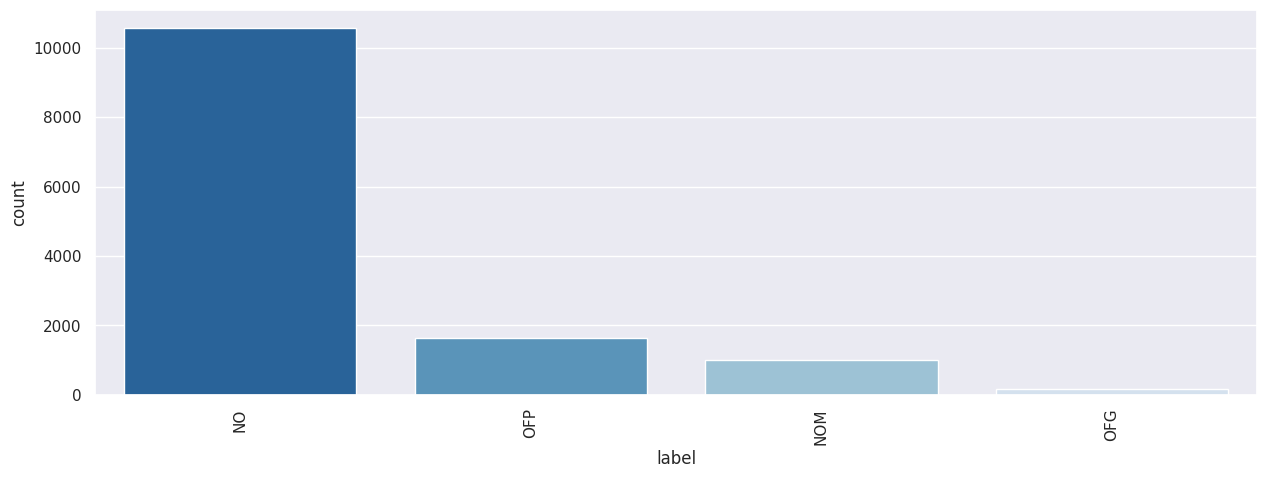

In [10]:
from collections import Counter
sns.countplot(data=training_set, x=training_set.label, order=[x for x, count in sorted(Counter(training_set.label).items(), key=lambda x: -x[1])], palette="Blues_r")
plt.xticks(rotation=90)

Se puede ver que este es un problema desbalanceado donde la clase no tiene más de 5 veces más muestras que la siguiente clase (OFP).
OFP tiene casi el doble de muestras que NOM. Y OFG a penas tiene muestras si la comparamos con las demás clases.

En apartados posteriores podremos utilizar ciertas técnicas que ayuden con el problema del desequilibrio de los datos.

A continuación muestro la misma visualización para el etiquetado conjunto.

([0, 1], [Text(0, 0, 'No offensive'), Text(1, 0, 'Offensive')])

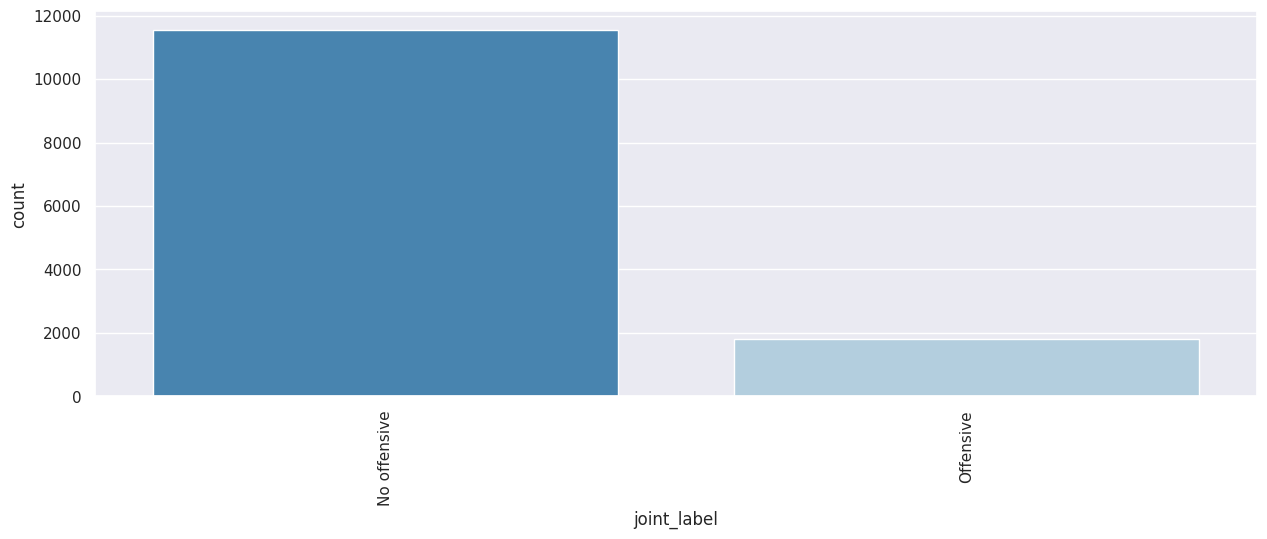

In [11]:
from collections import Counter
sns.countplot(data=training_set, x=training_set.joint_label, order=[x for x, count in sorted(Counter(training_set.joint_label).items(), key=lambda x: -x[1])], palette="Blues_r")
plt.xticks(rotation=90)

Si el etiquetado es binario, tendremos que la clase No ofensiva, tiene alrededor de 6 veces más muestras que la clase ofensiva.

### Palabras más frecuentes por clase y procesado del texto
Vamos a ver ahora, para el etiquetado conjunto, qué términos son más comunes para cada clase.

In [12]:
from matplotlib import interactive

# Agrupamos las reviews por su etiqueta
df = pd.DataFrame({"text": training_set.comment, "label": training_set.joint_label})
grouped = df.groupby(['label']).apply(lambda x: x['text'].sum())
grouped_df = pd.DataFrame({'label': grouped.index, 'text': grouped.values})

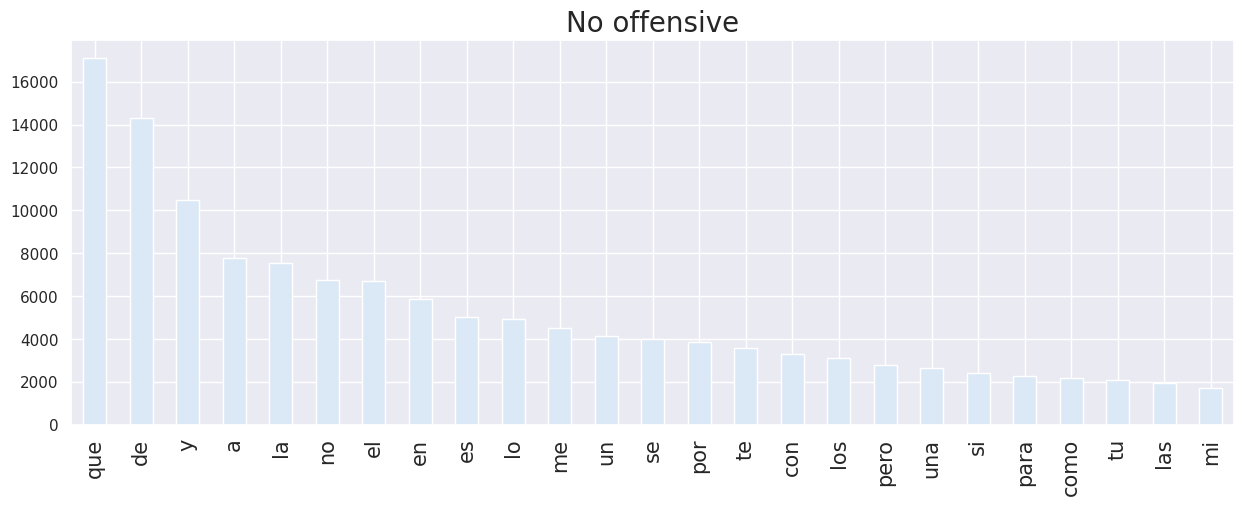

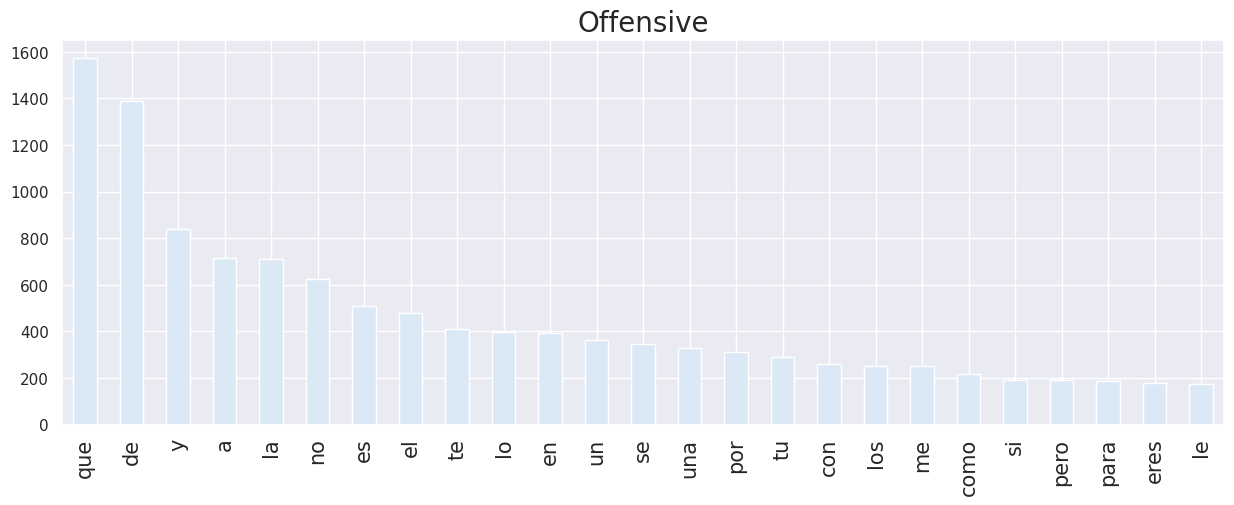

In [13]:
from nltk.tokenize import WhitespaceTokenizer
import matplotlib.pyplot as plt

tokenizer = WhitespaceTokenizer()

for ii, text in enumerate(grouped_df.text):
    tokens = tokenizer.tokenize(text)
    
    word_counts = pd.Series(tokens).value_counts().head(25)
    
    word_counts.plot(kind="bar")
    plt.title(grouped_df.label[ii], fontsize=20)
    plt.xticks(fontsize=15)
    plt.show()

Se puede ver que en los datos sin procesar, los términos más comunes son stopwords del español. Esto no ayuda a diferenciar entre clases. Vamos
a hacer la misma visualización, pero normalizando el texto en el siguiente orden:
- Filtrar y quedarse solo con letras
- Convertir todo a minúscula
- Aplicar lematización
- Eliminar acentos

Si hubiese algún problema, por favor, ejecutar:
```bash
pip install spacy
python -m spacy download es_core_news_sm
```


In [14]:
import spacy
import unicodedata
import re

nlp = spacy.load("es_core_news_sm")
spanish_stopwords = nlp.Defaults.stop_words


def remove_accents(text, keep_enye=True):
    if keep_enye:
        text = text.replace('ñ', '\0n').replace('Ñ', '\0N')
    nfkd = unicodedata.normalize('NFD', text)
    stripped = ''.join(c for c in nfkd if unicodedata.category(c) != 'Mn')
    if keep_enye:
        stripped = stripped.replace('\0n', 'ñ').replace('\0N', 'Ñ')
    return stripped


def process_text(raw_text):
    # Keep letters with accents so the lemmatizer works correctly
    pattern = "[^a-zA-ZáéíóúÁÉÍÓÚñÑüÜ]"
    letters_only = re.sub(pattern, " ", raw_text)

    # Lowercase
    text = letters_only.lower()

    # Lemmatize and remove stopwords
    doc = nlp(text)
    lemmas = [
        token.lemma_
        for token in doc
        if token.lemma_ not in spanish_stopwords and token.lemma_.strip()
    ]

    # Remove accents after lemmatization
    lemmas = [remove_accents(lemma) for lemma in lemmas]

    return " ".join(lemmas)

Procesamos los comentarios y los guardamos en una columna nueva.

In [15]:
from tqdm import tqdm
tqdm.pandas()

dataset['clean_comment'] = dataset['comment'].progress_apply(lambda x: process_text(x))

100%|██████████| 16710/16710 [01:24<00:00, 198.92it/s]


In [16]:
dataset.head()

,comment_id,comment,label,joint_label,clean_comment
0,2081,Dalas: hace una pregunta retórica Turbobo: *...,NO,No offensive,da el pregunta retorico turbobo contar el vida...
1,21214,Por qué no solamente le diste a una fundación ...,NO,No offensive,distir fundacion dale mil dolar alguien probab...
2,40888,Te ves guapísima y brillante con ese nuevo loo...,NO,No offensive,guapisimo brillante look fantastico video apor...
3,40790,Se esta hablando de que Ariana Grande esta rel...,NO,No offensive,hablar arianar relacionado movida atentado ocu...
4,55889,¡¡HAGO REVIEWS DE SERIES Y PELIS!! ¿ Quieres e...,NO,No offensive,reviews serie pelis querer empezar serie empez...


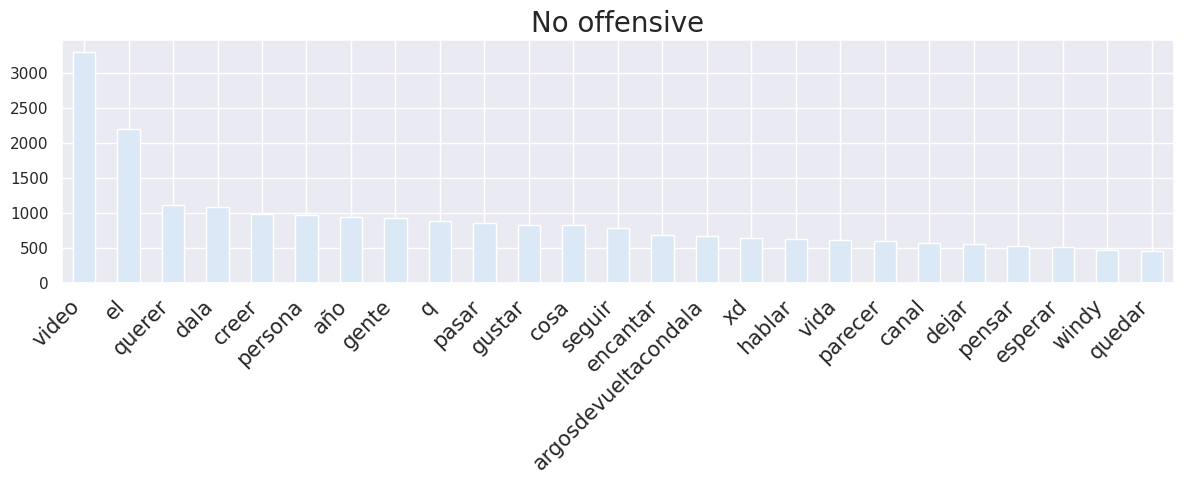

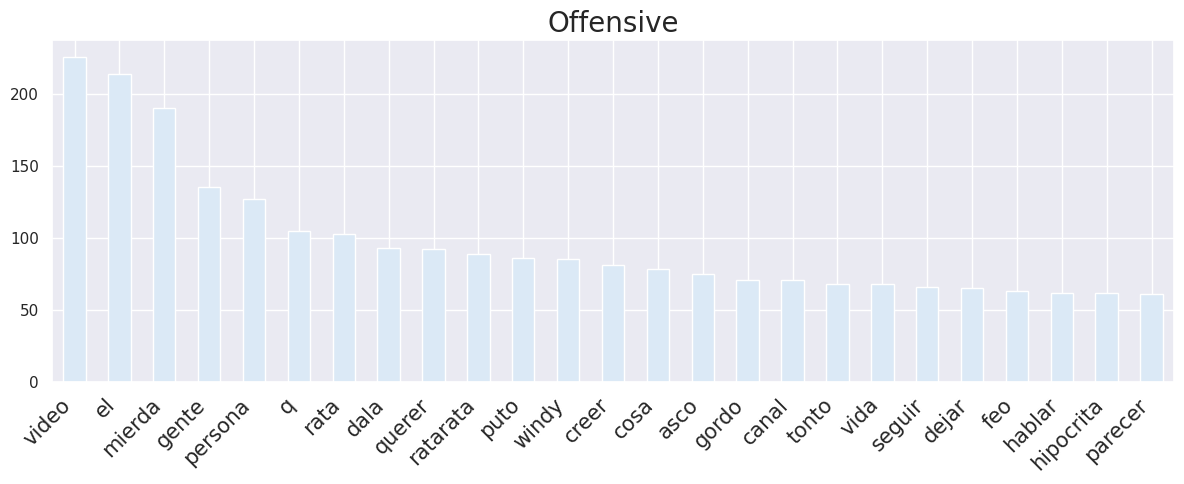

In [17]:
from nltk.tokenize import WhitespaceTokenizer
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "text": dataset[0:len(training_set)].clean_comment,
    "CLASS": dataset[0:len(training_set)].joint_label
})

grouped_df = (
    df.groupby("CLASS")["text"]
      .apply(lambda x: " ".join(x.astype(str)))
      .reset_index()
)

tokenizer = WhitespaceTokenizer()

for ii, text in enumerate(grouped_df.text):
    tokens = tokenizer.tokenize(text)
    word_counts = pd.Series(tokens).value_counts().head(25)
    
    plt.figure(figsize=(12, 5))
    word_counts.plot(kind="bar")
    plt.title(grouped_df.CLASS[ii], fontsize=20)
    plt.xticks(fontsize=15, rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

Antes sin procesar el texto veíamos en ambas clases que las stopwords eran las palabras más frecuentes. Ahora, en cambio, aparecen en la clase
Offensive palabras que la ayudan a identificar y que no están en la clase No offensive: mierda, rata, puto, asco, feo, hipocrita, etc.

### Estadísticas sobre las longitudes de los comentarios
Vamos a ver ahora estadísticas sobre las longitudes de los comentarios. Estas estadísticas servirán posteriormente para dimensionar la entreada
(max len) de ciertos algoritmos.

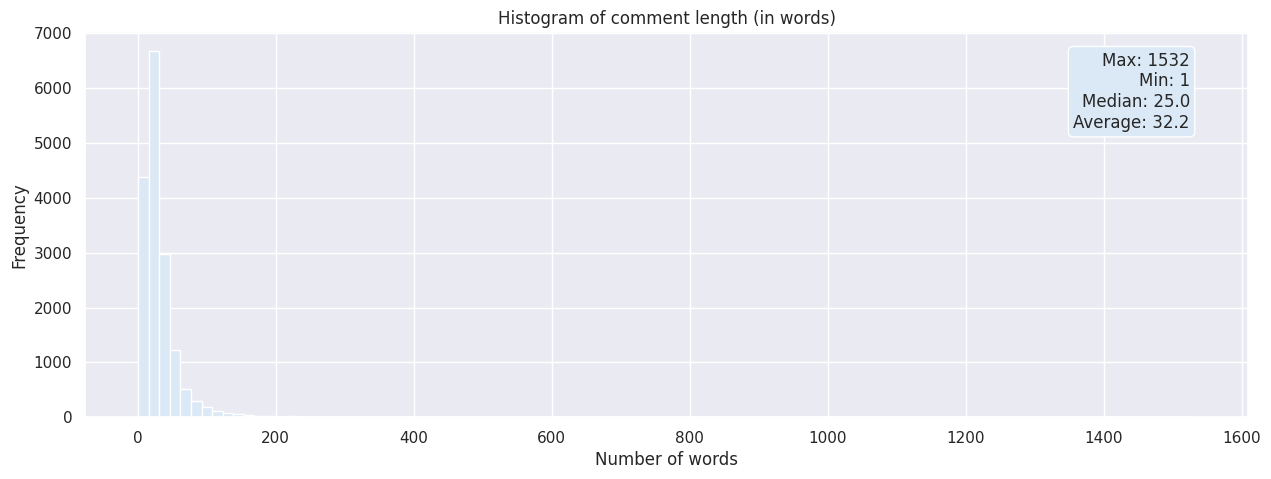

In [18]:
import matplotlib.pyplot as plt

# Count words in each string
word_counts = dataset.comment.str.split().str.len()

# Calculate statistics
max_len = word_counts.max()
min_len = word_counts.min()
median_len = word_counts.median()
avg_len = word_counts.mean()

# Plot histogram
word_counts.plot.hist(bins=100)
plt.xlabel('Number of words')
plt.ylabel('Frequency')
plt.title('Histogram of comment length (in words)')

# Add statistics as text box
stats_text = (f'Max: {max_len}\n'
              f'Min: {min_len}\n'
              f'Median: {median_len:.1f}\n'
              f'Average: {avg_len:.1f}')
plt.text(0.95, 0.95, stats_text,
         transform=plt.gca().transAxes,
         verticalalignment='top',
         horizontalalignment='right',
         bbox=dict(boxstyle='round'))

plt.show()

Sin procesar el texto, se ve que la longitud de los comentarios tiene una mediana de 25 palabras, con un outlier en 1532 palabras. Parece bastante seguro establecer una longitud máxima de 200 palabras.

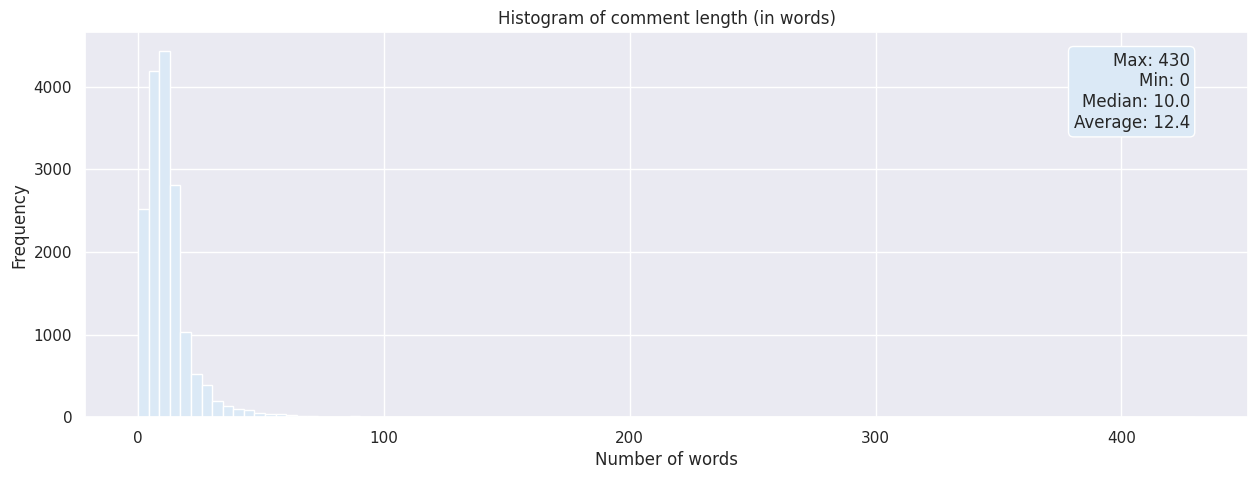

In [19]:
import matplotlib.pyplot as plt

# Count words in each string
word_counts = dataset.clean_comment.str.split().str.len()

# Calculate statistics
max_len = word_counts.max()
min_len = word_counts.min()
median_len = word_counts.median()
avg_len = word_counts.mean()

# Plot histogram
word_counts.plot.hist(bins=100)
plt.xlabel('Number of words')
plt.ylabel('Frequency')
plt.title('Histogram of comment length (in words)')

# Add statistics as text box
stats_text = (f'Max: {max_len}\n'
              f'Min: {min_len}\n'
              f'Median: {median_len:.1f}\n'
              f'Average: {avg_len:.1f}')
plt.text(0.95, 0.95, stats_text,
         transform=plt.gca().transAxes,
         verticalalignment='top',
         horizontalalignment='right',
         bbox=dict(boxstyle='round'))

plt.show()

Con los datos procesados, la mediana se reduce a 10 palabras. En este espacio sería bastante seguro utilizar una longitud máxima de secuencia de 100 palabras.

## Representaciones vectoriales

### Codificación de las etiquetas

In [20]:
X_train = dataset[0:len(training_set)][["comment_id", "clean_comment"]]
y_train = dataset[0:len(training_set)][["joint_label"]]

X_test = dataset[len(training_set):len(dataset)][["comment_id", "clean_comment"]]
y_test = dataset[len(training_set):len(dataset)][["joint_label"]]

In [21]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
print(f"Values before encoding: {y_train.joint_label.values}")
le.fit(y_train.joint_label.values)
target_labels = le.classes_
encoded_y_train = le.transform(y_train.joint_label.values)
print(f"Labels after encoding: {encoded_y_train}")

print(f"Target labels: {target_labels}")

Values before encoding: <ArrowStringArray>
['No offensive', 'No offensive', 'No offensive', 'No offensive',
 'No offensive', 'No offensive', 'No offensive', 'No offensive',
 'No offensive', 'No offensive',
 ...
 'No offensive', 'No offensive', 'No offensive', 'No offensive',
 'No offensive', 'No offensive', 'No offensive', 'No offensive',
 'No offensive', 'No offensive']
Length: 13368, dtype: str
Labels after encoding: [0 0 0 ... 0 0 0]
Target labels: ['No offensive' 'Offensive']


In [22]:
print(encoded_y_train)
print(encoded_y_train.shape)

[0 0 0 ... 0 0 0]
(13368,)


### Representación TF

In [23]:
X_train = dataset[0:len(training_set)][["comment_id", "clean_comment"]]
y_train = dataset[0:len(training_set)][["joint_label"]]

X_test = dataset[len(training_set):len(dataset)][["comment_id", "clean_comment"]]
y_test = dataset[len(training_set):len(dataset)][["joint_label"]]

In [24]:
count_vect = CountVectorizer(analyzer = "word")

train_features = count_vect.fit_transform(X_train.clean_comment)
test_features = count_vect.transform(X_test.clean_comment)

In [25]:
# Observemos el vocabulario
print('Longitud del vocabulario: ')
print(len(count_vect.vocabulary_))
print()
print("Observemos el vocabulario:")
print(count_vect.vocabulary_)
print()


Longitud del vocabulario: 
22969

Observemos el vocabulario:
{'da': 5406, 'el': 7141, 'pregunta': 16998, 'retorico': 18546, 'turbobo': 21473, 'contar': 4680, 'vida': 22090, 'año': 2148, 'llegar': 12739, 'xdd': 22678, 'distir': 6694, 'fundacion': 9307, 'dale': 5462, 'mil': 13925, 'dolar': 6781, 'alguien': 897, 'probablemente': 17166, 'siquiera': 19740, 'internet': 11343, 'quieres': 17684, 'ayudar': 2105, 'gente': 9517, 'excusa': 8389, 'video': 22102, 'seguidor': 19279, 'guapisimo': 9862, 'brillante': 2797, 'look': 12871, 'fantastico': 8713, 'aportar': 1458, 'hora': 10549, 'ejercicio': 7129, 'beso': 2473, 'hablar': 10021, 'arianar': 1608, 'relacionado': 18260, 'movida': 14336, 'atentado': 1858, 'ocurrio': 15095, 'concierto': 4458, 'pertenecer': 16267, 'mafia': 13047, 'arian': 1606, 'rechazar': 17972, 'titulo': 20971, 'dama': 5475, 'reina': 18235, 'isabel': 11489, 'ofrecer': 15157, 'reviews': 18606, 'serie': 19430, 'pelis': 16017, 'querer': 17640, 'empezar': 7290, 'bola': 2659, 'dejame': 

In [26]:
# Ejemplo original de una review
print("Original:")
print(dataset.comment.head()[0])
print()

# Ejemplo tras el preprocesado
print("Pre-procesado:")
print(X_train.clean_comment[0])
print()

# Convertimos la primera review
v0 = count_vect.transform([X_train.clean_comment[0]]).toarray()[0]
print('Convertido: ')
print(v0)
print()

# Es demasiado grande para observarlo, imprimimos su longitud
print('Longitud del vector: ')
print(len(v0))
print()

# ¿Cuántas palabras contiene la frase?
print('Número de palabras: ')
print(np.sum(v0))
print()


Original:
Dalas: hace una pregunta retórica   Turbobo: *se pone a contarle su vida a partir de los 15 años y de cómo llegó hasta hoy*   Xdd

Pre-procesado:
da el pregunta retorico turbobo contar el vida año llegar xdd

Convertido: 
[0 0 0 ... 0 0 0]

Longitud del vector: 
22969

Número de palabras: 
11



### Representación TF-IDF

In [27]:
from sklearn.feature_extraction.text import TfidfTransformer

X_train["all"] = X_train[['clean_comment']].apply(lambda x: ''.join(x), axis=1)
X_test["all"] = X_test[['clean_comment']].apply(lambda x: ''.join(x), axis=1)

count_vect = CountVectorizer(analyzer = "word")
train_features = count_vect.fit_transform(X_train['all'])
test_features = count_vect.transform(X_test['all'])

# Se utiliza L2 (norma euclídea) para normalizar los vectores resultantes
tfidf = TfidfTransformer(norm="l2")
train_text_tfidf_features = tfidf.fit_transform(train_features)
test_text_tfidf_features = tfidf.transform(test_features)                


### Bigramas

In [28]:
bigram_count_vect = CountVectorizer(analyzer = "word", ngram_range=(1,2))
train_bigram_features = bigram_count_vect.fit_transform(X_train.clean_comment)
test_bigram_features = bigram_count_vect.transform(X_test.clean_comment)

### Bigramas con TF-IDF

In [29]:
tfidf = TfidfTransformer(norm="l2")
train_text_bigram_tfidf_features = tfidf.fit_transform(train_bigram_features)
test_text_bigram_tfidf_features = tfidf.fit_transform(test_bigram_features)

### Bigramas con TF-IDF y reducción de características a 5000

In [30]:
bigram_tfidf_chi2_vect = TfidfVectorizer(norm="l2", ngram_range=(1,2))
train_text_bigram_tfidf_chi2_features = bigram_tfidf_chi2_vect.fit_transform(X_train.clean_comment)
test_text_bigram_tfidf_chi2_features = bigram_tfidf_chi2_vect.transform(X_test.clean_comment)

ch2 = SelectKBest(chi2, k=5000)
train_text_bigram_tfidf_chi2_features = ch2.fit_transform(train_text_bigram_tfidf_chi2_features, y_train)
test_text_bigram_tfidf_chi2_features = ch2.transform(test_text_bigram_tfidf_chi2_features)

# Definición de baselines

Como baselines, vamos a utilizar algoritmos de **Machine Learning** clásicos. Primero, vamos a representar los comentarios en una representación vectorial del tipo: TF, TF-IDF y con bigramas. Posteriormente, entrenaremos algoritmos de ML con estas features e identificaremos el que mejor resultados tenga. Se considera esto un baseline por que:
- Son rápidos de entrenar
- Son rápidos de implementar. Al menos en las prácticas no han requerido mucha ingeniería ni finetuning.
- En las prácticas anteriores se demostró que obtienen buenos resultados.


## Utilidades

In [31]:
import numpy as np
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        scoring='f1_macro',
                        train_sizes=np.linspace(.1, 1.0, 5)):
    """
    Generate a simple plot of the test and traning learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : integer, cross-validation generator, optional
        If an integer is passed, it is the number of folds (defaults to 3).
        Specific cross-validation objects can be passed, see
        sklearn.cross_validation module for the list of possible objects

    scoring : string, optional
        Scoring metric for the learning curve (default: 'f1_macro').
    """

    plt.figure()
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=1, train_sizes=train_sizes,
        scoring=scoring)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.xlabel("Training examples")
    plt.ylabel(scoring)
    plt.legend(loc="best")
    plt.grid("on")
    if ylim:
        plt.ylim(ylim)
    plt.title(title)

In [32]:
def train_and_evaluate_classifier(X, yt, estimator, grid):
    """Train and Evaluate a estimator (defined as input parameter) on the given labeled data using F1 Macro."""

    # Se realiza validación cruzada estratificada sobre el clasificador seleccionado
    from sklearn.model_selection import StratifiedShuffleSplit
    cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

    from sklearn.model_selection import GridSearchCV
    classifier = GridSearchCV(estimator=estimator, cv=cv, param_grid=grid,
                              scoring='f1_macro', error_score=0.0,
                              n_jobs=-1, verbose=5)
    
    # Entrenamiento
    print("Training model")
    classifier.fit(X, yt)

    # Puntuación de la validación cruzada
    print("CV-scores for each grid configuration")
    means = classifier.cv_results_['mean_test_score']
    stds = classifier.cv_results_['std_test_score']
    for mean, std, params in sorted(zip(means, stds, classifier.cv_results_['params']), key=lambda x: -x[0]):
        print("F1 Macro: %0.3f (+/-%0.03f) for params: %r" % (mean, std * 2, params))
    print()
        
    # Curva de aprendizaje
    print("Learning curve for the best estimator")
    title = 'Learning Curves (' + str(estimator.__class__).replace("'>", "").split(".")[-1] + ' )'
    plot_learning_curve(classifier.best_estimator_, title, X, yt, cv=cv)
    plt.show()
    
    return classifier

In [33]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    import itertools
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')
    plt.figure()
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()


## Baselines 2 classes

### Naive Bayes

Training model
Fitting 5 folds for each of 1 candidates, totalling 5 fits


[CV 1/5] END ..................................., score=0.647 total time=   0.0s[CV 4/5] END ..................................., score=0.642 total time=   0.0s
[CV 2/5] END ..................................., score=0.668 total time=   0.0s

[CV 3/5] END ..................................., score=0.628 total time=   0.0s
[CV 5/5] END ..................................., score=0.640 total time=   0.0s
CV-scores for each grid configuration
F1 Macro: 0.645 (+/-0.026) for params: {}

Learning curve for the best estimator


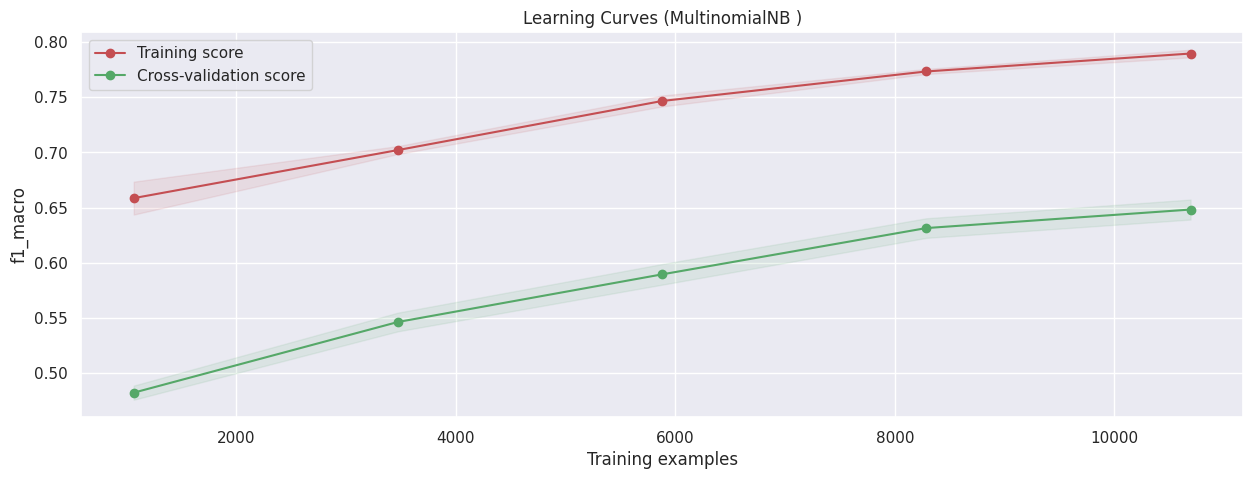

In [81]:
from sklearn.naive_bayes import MultinomialNB

#En este caso no hace falta optimizar ningún parámetro
nb_grid= {} 

nb_text_cls = train_and_evaluate_classifier(train_features, encoded_y_train, MultinomialNB(), nb_grid)

In [82]:
print("Predicting on the test set")
y_pred = nb_text_cls.predict(test_features)

y_pred = le.inverse_transform(y_pred)

Predicting on the test set


Classification Report
              precision    recall  f1-score   support

No offensive       0.89      0.99      0.94      2889
   Offensive       0.84      0.24      0.37       453

    accuracy                           0.89      3342
   macro avg       0.87      0.62      0.66      3342
weighted avg       0.89      0.89      0.86      3342

Confusion matrix, without normalization


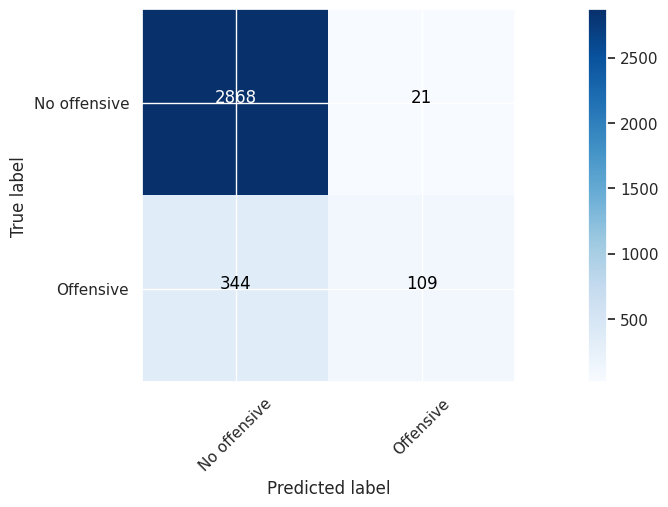

F1 Macro: 0.6571


In [83]:
print("Classification Report")
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)

plot_confusion_matrix(cm, classes=target_labels)

print("F1 Macro: %.4f" % f1_score(y_test, y_pred, average='macro'))

### SVM

Training model
Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV 3/5] END ..............C=100, kernel=linear;, score=0.694 total time=   5.0s
[CV 2/5] END ..............C=100, kernel=linear;, score=0.705 total time=   5.5s
[CV 4/5] END ..............C=100, kernel=linear;, score=0.687 total time=   6.6s
[CV 5/5] END ..............C=100, kernel=linear;, score=0.685 total time=   7.2s
[CV 5/5] END ...............C=10, kernel=linear;, score=0.717 total time=   4.6s
[CV 1/5] END ..............C=100, kernel=linear;, score=0.686 total time=   5.8s
[CV 4/5] END ...............C=10, kernel=linear;, score=0.699 total time=   5.9s
[CV 1/5] END ...............C=10, kernel=linear;, score=0.709 total time=   5.6s
[CV 2/5] END ................C=1, kernel=linear;, score=0.748 total time=   6.0s
[CV 1/5] END ................C=1, kernel=linear;, score=0.747 total time=   5.8s
[CV 5/5] END ................C=1, kernel=linear;, score=0.745 total time=   5.9s
[CV 4/5] END ................C=1, 

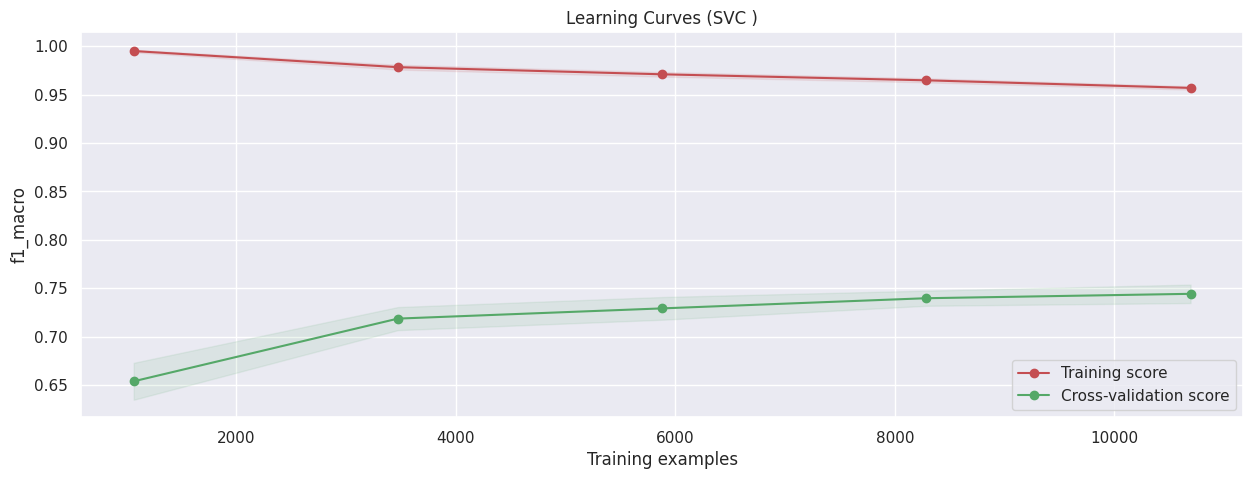

In [84]:
# SVM
from sklearn.svm import SVC

svm_grid = [
  {'C': [1, 10, 100], 'kernel': ['linear']},
  {'C': [10, 100, 1000], 'gamma': [0.0001], 'kernel': ['rbf']},
 ]

svm_cls = train_and_evaluate_classifier(train_features, encoded_y_train, SVC(class_weight='balanced'), svm_grid)

In [85]:
print("Best estimator found by grid search:")
print(svm_cls.best_estimator_)

Best estimator found by grid search:
SVC(C=1, class_weight='balanced', kernel='linear')


In [86]:
print("Predicting sentiment reviews on the test set")
y_pred = svm_cls.predict(test_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

Predicting sentiment reviews on the test set


Classification Report
              precision    recall  f1-score   support

No offensive       0.94      0.91      0.92      2889
   Offensive       0.52      0.63      0.57       453

    accuracy                           0.87      3342
   macro avg       0.73      0.77      0.75      3342
weighted avg       0.88      0.87      0.88      3342

Confusion matrix, without normalization


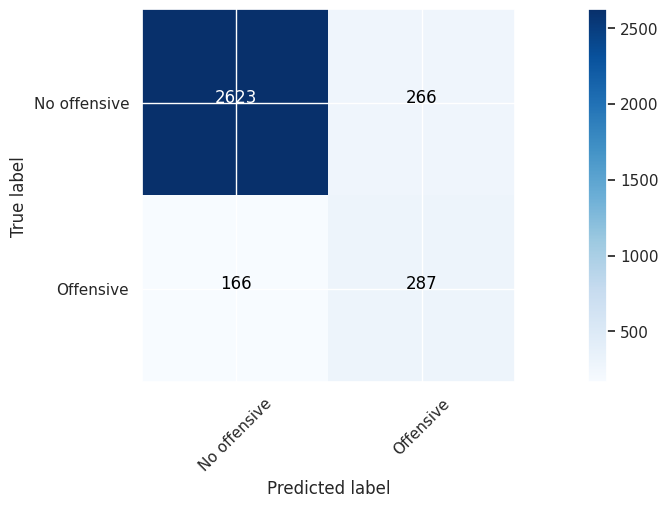

F1 Macro: 0.7472


In [87]:
print("Classification Report")
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)

plot_confusion_matrix(cm, classes=target_labels)

print("F1 Macro: %.4f" % f1_score(y_test, y_pred, average='macro'))

### MaxEnt

Training model
Fitting 5 folds for each of 14 candidates, totalling 70 fits
[CV 2/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 3/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 1/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s[CV 4/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s

[CV 5/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 2/5] END ...............C=0.001, penalty=l2;, score=0.581 total time=   0.0s
[CV 1/5] END ...............C=0.001, penalty=l2;, score=0.585 total time=   0.0s
[CV 3/5] END ...............C=0.001, penalty=l2;, score=0.594 total time=   0.0s
[CV 4/5] END ...............C=0.001, penalty=l2;, score=0.603 total time=   0.0s
[CV 1/5] END ................C=0.01, penalty=l1;, score=0.396 total time=   0.0s
[CV 2/5] END ................C=0.01, penalty=l1;, score=0.389 total time=   0.0s
[CV 5/5] END ...............C=0.0

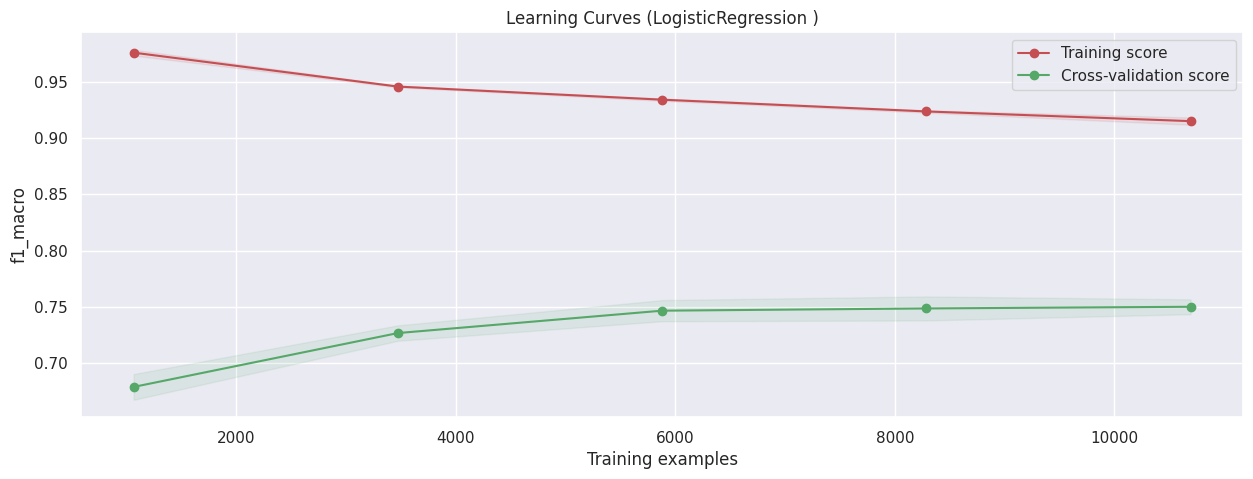

In [88]:
from sklearn.linear_model import LogisticRegression
max_ent_grid= {'penalty': ['l1','l2'], 'C': [0.001,0.01,0.1,1,10,100,1000]}
max_ent_cls = train_and_evaluate_classifier(train_features, encoded_y_train, LogisticRegression(solver='liblinear', class_weight='balanced'), max_ent_grid)

In [89]:
print("Best estimator found by grid search:")
print(max_ent_cls.best_estimator_)

Best estimator found by grid search:
LogisticRegression(C=1, class_weight='balanced', penalty='l2',
                   solver='liblinear')


In [90]:
print("Predicting sentiment on the test set")
y_pred = max_ent_cls.predict(test_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

Predicting sentiment on the test set


Classification Report
              precision    recall  f1-score   support

No offensive       0.95      0.89      0.92      2889
   Offensive       0.51      0.70      0.59       453

    accuracy                           0.87      3342
   macro avg       0.73      0.80      0.76      3342
weighted avg       0.89      0.87      0.88      3342

Confusion matrix, without normalization


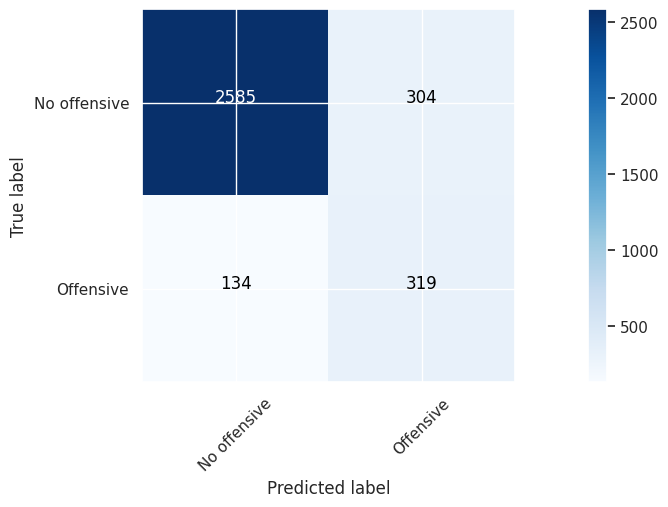

F1 Macro: 0.7574


In [91]:
print("Classification Report")
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)
 
plot_confusion_matrix(cm, classes=target_labels)

print("F1 Macro: %.4f" % f1_score(y_test, y_pred, average='macro'))

### MaxEnt Pesado con TF-IDF

Training model
Fitting 5 folds for each of 14 candidates, totalling 70 fits
[CV 1/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 2/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 3/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 4/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 5/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 2/5] END ...............C=0.001, penalty=l2;, score=0.734 total time=   0.0s
[CV 1/5] END ...............C=0.001, penalty=l2;, score=0.739 total time=   0.0s
[CV 3/5] END ...............C=0.001, penalty=l2;, score=0.751 total time=   0.0s
[CV 4/5] END ...............C=0.001, penalty=l2;, score=0.729 total time=   0.0s
[CV 1/5] END ................C=0.01, penalty=l1;, score=0.464 total time=   0.0s
[CV 2/5] END ................C=0.01, penalty=l1;, score=0.464 total time=   0.0s
[CV 3/5] END ................C=0.

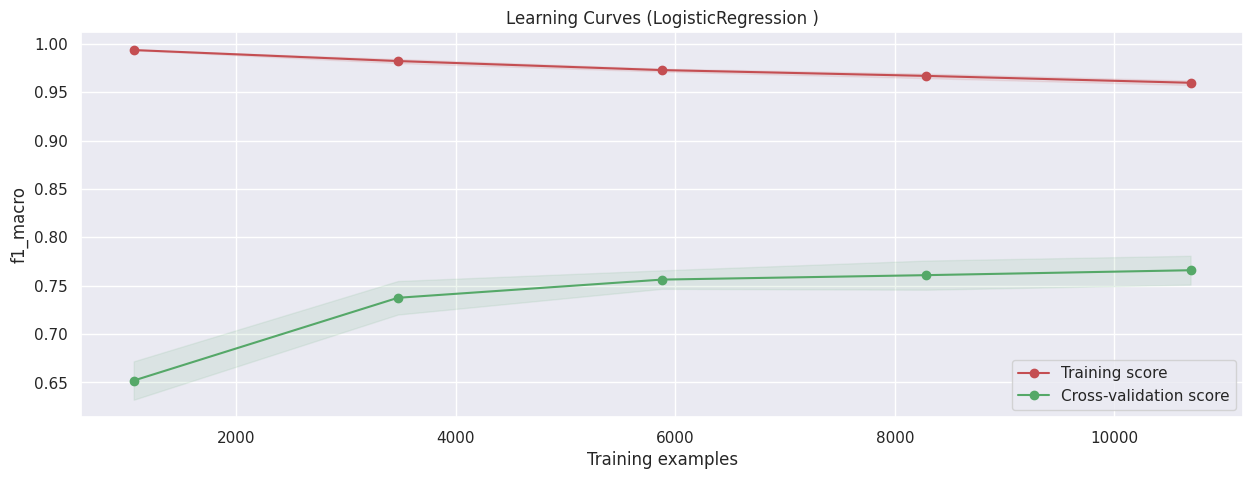

In [92]:
max_ent_grid= {'penalty': ['l1','l2'], 'C': [0.001,0.01,0.1,1,10,100,1000]}
max_ent_tfidf_cls = train_and_evaluate_classifier(train_text_tfidf_features, encoded_y_train, LogisticRegression(solver='liblinear', class_weight='balanced'), max_ent_grid)

In [93]:
print("Best estimator found by grid search:")
print(max_ent_tfidf_cls.best_estimator_)

Best estimator found by grid search:
LogisticRegression(C=10, class_weight='balanced', penalty='l2',
                   solver='liblinear')


In [94]:
print("Predicting sentiment on the test set")
y_pred = max_ent_tfidf_cls.predict(test_text_tfidf_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

Predicting sentiment on the test set


Classification Report
              precision    recall  f1-score   support

No offensive       0.94      0.93      0.94      2889
   Offensive       0.59      0.62      0.61       453

    accuracy                           0.89      3342
   macro avg       0.77      0.78      0.77      3342
weighted avg       0.89      0.89      0.89      3342

Confusion matrix, without normalization


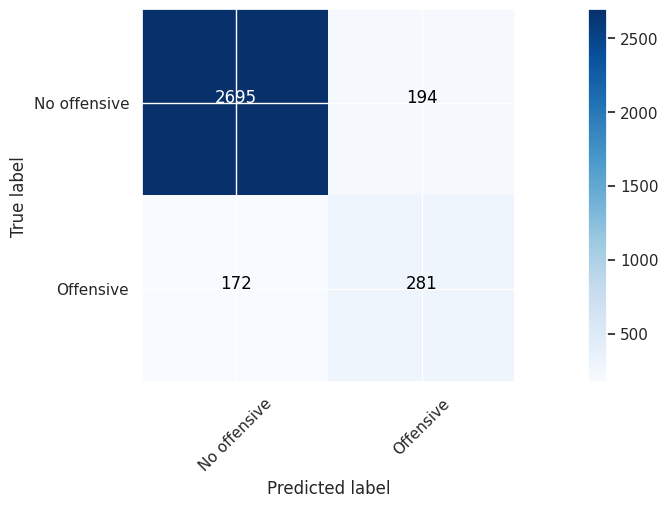

F1 Macro: 0.7710


In [95]:
print("Classification Report")
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)

plot_confusion_matrix(cm, classes=target_labels)

print("F1 Macro: %.4f" % f1_score(y_test, y_pred, average='macro'))

### MaxEnt Bigramas

Training model
Fitting 5 folds for each of 14 candidates, totalling 70 fits
[CV 2/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 1/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 3/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 4/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 5/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.1s
[CV 2/5] END ...............C=0.001, penalty=l2;, score=0.587 total time=   0.1s
[CV 1/5] END ...............C=0.001, penalty=l2;, score=0.590 total time=   0.1s
[CV 2/5] END ................C=0.01, penalty=l1;, score=0.389 total time=   0.1s
[CV 5/5] END ................C=0.01, penalty=l1;, score=0.403 total time=   0.2s
[CV 1/5] END ................C=0.01, penalty=l1;, score=0.396 total time=   0.2s
[CV 3/5] END ...............C=0.001, penalty=l2;, score=0.597 total time=   0.2s
[CV 2/5] END ................C=0.

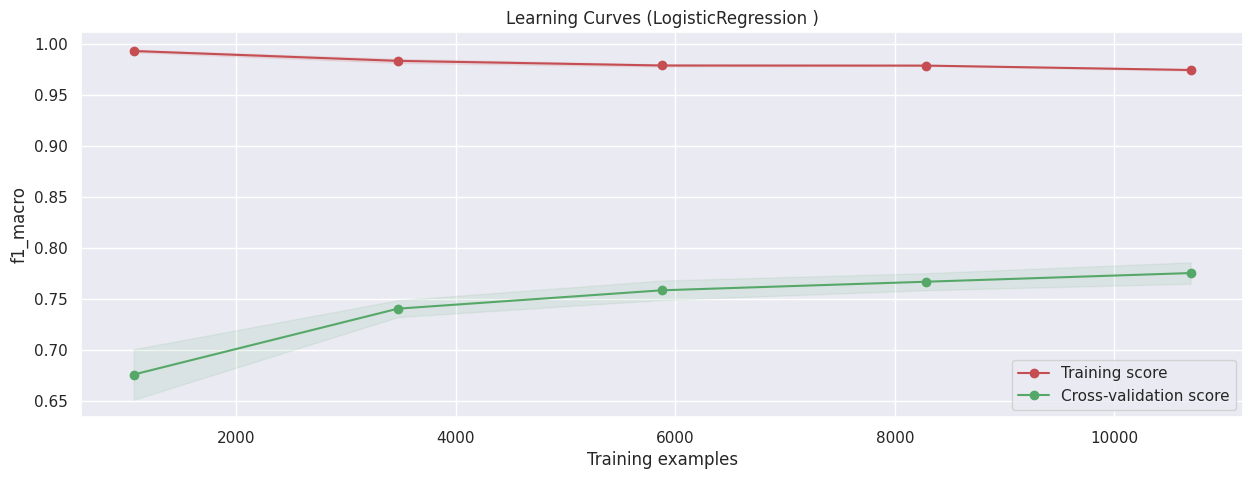

In [96]:
max_ent_bigram_cls = train_and_evaluate_classifier(train_bigram_features, encoded_y_train, LogisticRegression(solver='liblinear', class_weight='balanced'), max_ent_grid)

In [97]:
print("Best estimator found by grid search:")
print(max_ent_bigram_cls.best_estimator_)

Best estimator found by grid search:
LogisticRegression(C=1, class_weight='balanced', penalty='l2',
                   solver='liblinear')


In [98]:
print("Predicting sentiment on the test set")
y_pred = max_ent_bigram_cls.predict(test_bigram_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

Predicting sentiment on the test set


Classification Report
              precision    recall  f1-score   support

No offensive       0.94      0.93      0.94      2889
   Offensive       0.60      0.63      0.62       453

    accuracy                           0.89      3342
   macro avg       0.77      0.78      0.78      3342
weighted avg       0.90      0.89      0.89      3342

Confusion matrix, without normalization


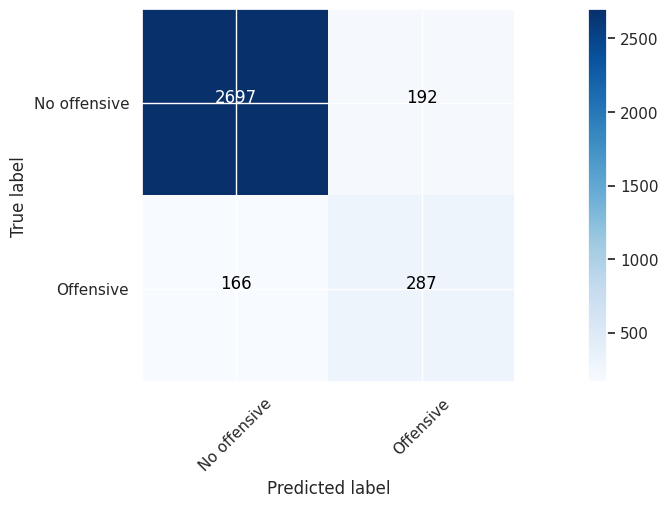

F1 Macro: 0.7768


In [99]:
print("Classification Report")
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)

plot_confusion_matrix(cm, classes=target_labels)

print("F1 Macro: %.4f" % f1_score(y_test, y_pred, average='macro'))

### MaxEnt Bigramas con TF-IDF

Training model
Fitting 5 folds for each of 14 candidates, totalling 70 fits
[CV 1/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 3/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 5/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 2/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 4/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 2/5] END ...............C=0.001, penalty=l2;, score=0.747 total time=   0.0s
[CV 1/5] END ................C=0.01, penalty=l1;, score=0.464 total time=   0.0s
[CV 2/5] END ................C=0.01, penalty=l1;, score=0.464 total time=   0.0s
[CV 3/5] END ................C=0.01, penalty=l1;, score=0.464 total time=   0.0s
[CV 5/5] END ................C=0.01, penalty=l1;, score=0.464 total time=   0.0s
[CV 2/5] END ................C=0.01, penalty=l2;, score=0.754 total time=   0.0s
[CV 4/5] END ...............C=0.0

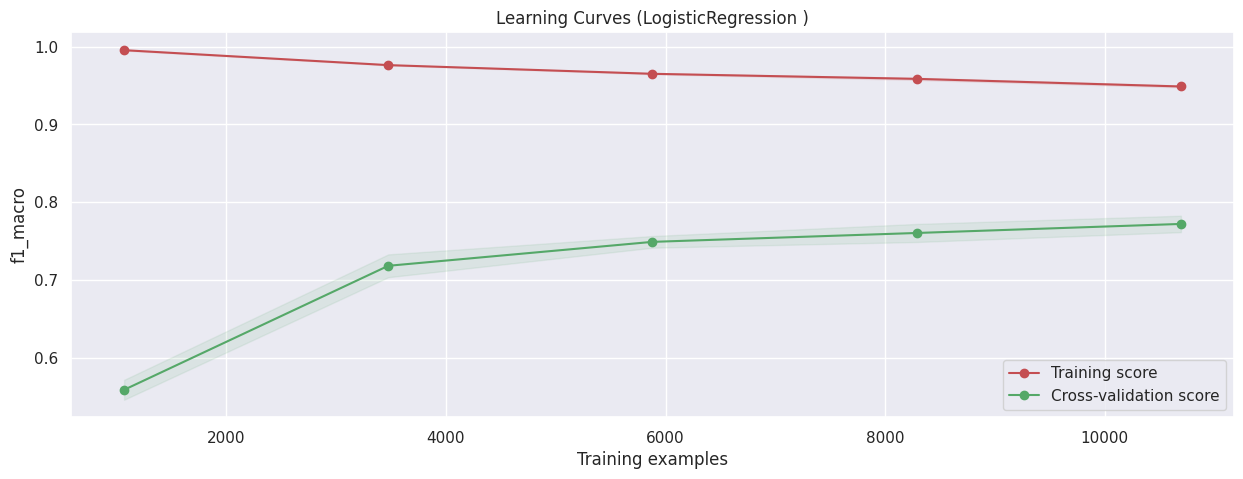

In [100]:
max_ent_bigram_tfidf_cls = train_and_evaluate_classifier(train_text_bigram_tfidf_features, encoded_y_train, LogisticRegression(solver='liblinear', class_weight='balanced'), max_ent_grid)

In [101]:
print("Best estimator found by grid search:")
print(max_ent_bigram_tfidf_cls.best_estimator_)

Best estimator found by grid search:
LogisticRegression(C=1, class_weight='balanced', penalty='l2',
                   solver='liblinear')


In [102]:
print("Predicting sentiment on the test set")
y_pred = max_ent_bigram_tfidf_cls.predict(test_text_bigram_tfidf_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

Predicting sentiment on the test set


Classification Report
              precision    recall  f1-score   support

No offensive       0.95      0.92      0.93      2889
   Offensive       0.58      0.68      0.62       453

    accuracy                           0.89      3342
   macro avg       0.76      0.80      0.78      3342
weighted avg       0.90      0.89      0.89      3342

Confusion matrix, without normalization


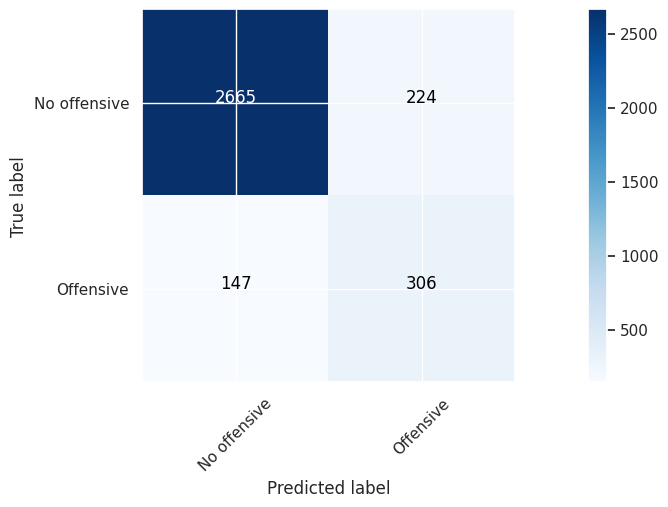

F1 Macro: 0.7788


In [103]:
print("Classification Report")
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)

plot_confusion_matrix(cm, classes=target_labels)

print("F1 Macro: %.4f" % f1_score(y_test, y_pred, average='macro'))

In [104]:
def most_informative_feature_for_binary_classification(vectorizer, classifier, n=100):
    """
    See: https://stackoverflow.com/a/26980472
    
    Identify most important features if given a vectorizer and binary classifier. Set n to the number
    of weighted features you would like to show. (Note: current implementation merely prints and does not 
    return top classes.)
    """

    class_labels = classifier.classes_
    feature_names = vectorizer.get_feature_names_out()
    topn_class1 = sorted(zip(feature_names, classifier.coef_[0]), key=lambda u: u[1])[:n]
    topn_class2 = sorted(zip(feature_names, classifier.coef_[0]), key=lambda u: -u[1])[:n]

    return topn_class1, topn_class2

In [105]:
# Remember negative is index 0 and positive is index 1
negative_features, positive_features = most_informative_feature_for_binary_classification(bigram_count_vect, max_ent_cls.best_estimator_, n=30)

<Axes: title={'center': 'Most important features to identify negative reviews'}, xlabel='feature'>

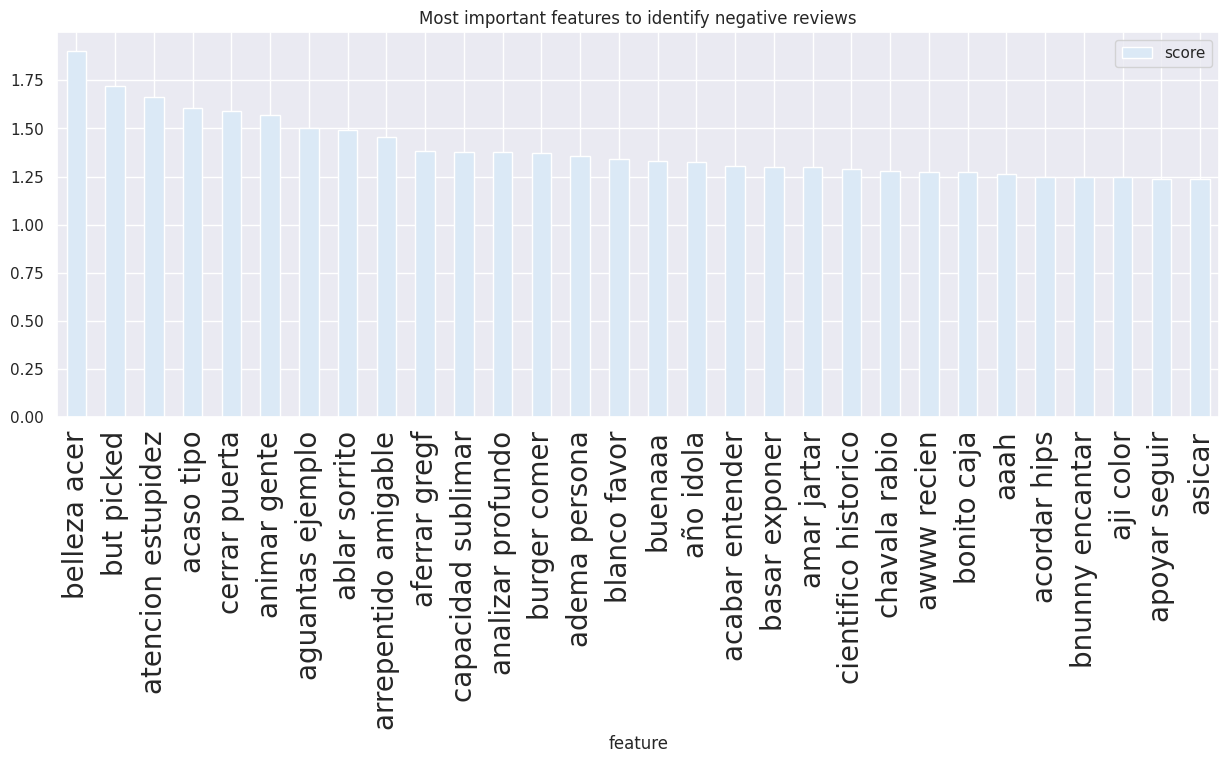

In [106]:
top_negative_features = pd.DataFrame(negative_features, columns=["feature", "score"])
top_negative_features.score = abs(top_negative_features.score)
plt.rc('xtick', labelsize=20)    # fontsize of the tick labels
top_negative_features.plot(x="feature", y="score", kind="bar", title="Most important features to identify negative reviews")

<Axes: title={'center': 'Most important features to identify positive reviews'}, xlabel='feature'>

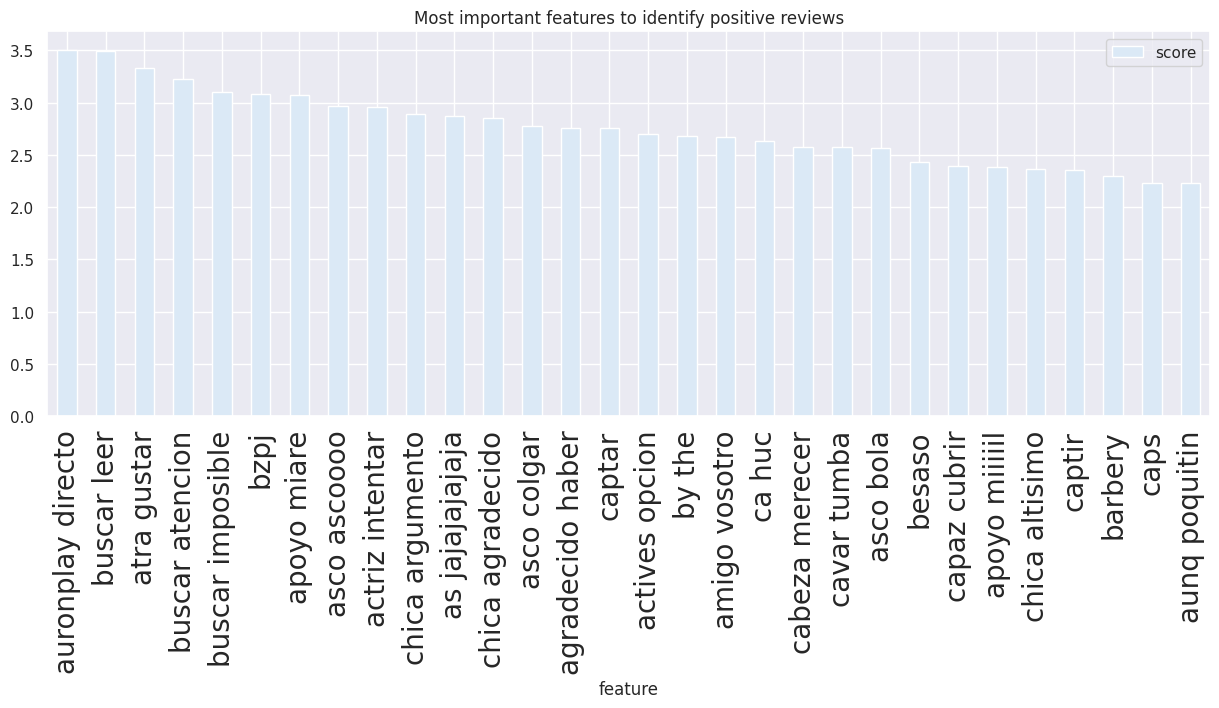

In [107]:
top_positive_features = pd.DataFrame(positive_features, columns=["feature", "score"])
plt.rc('xtick', labelsize=20)    # fontsize of the tick labels
top_positive_features.plot(x="feature", y="score", kind="bar", title="Most important features to identify positive reviews")

### MaxEnt Bigramas con TF-IDF y reducción de características a 5000

Training model
Fitting 5 folds for each of 14 candidates, totalling 70 fits
[CV 1/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 2/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 3/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 4/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 5/5] END ...............C=0.001, penalty=l1;, score=0.464 total time=   0.0s
[CV 1/5] END ...............C=0.001, penalty=l2;, score=0.739 total time=   0.0s
[CV 2/5] END ...............C=0.001, penalty=l2;, score=0.751 total time=   0.0s
[CV 3/5] END ...............C=0.001, penalty=l2;, score=0.759 total time=   0.0s
[CV 4/5] END ...............C=0.001, penalty=l2;, score=0.734 total time=   0.0s
[CV 1/5] END ................C=0.01, penalty=l1;, score=0.464 total time=   0.0s
[CV 2/5] END ................C=0.01, penalty=l1;, score=0.464 total time=   0.0s
[CV 5/5] END ...............C=0.0

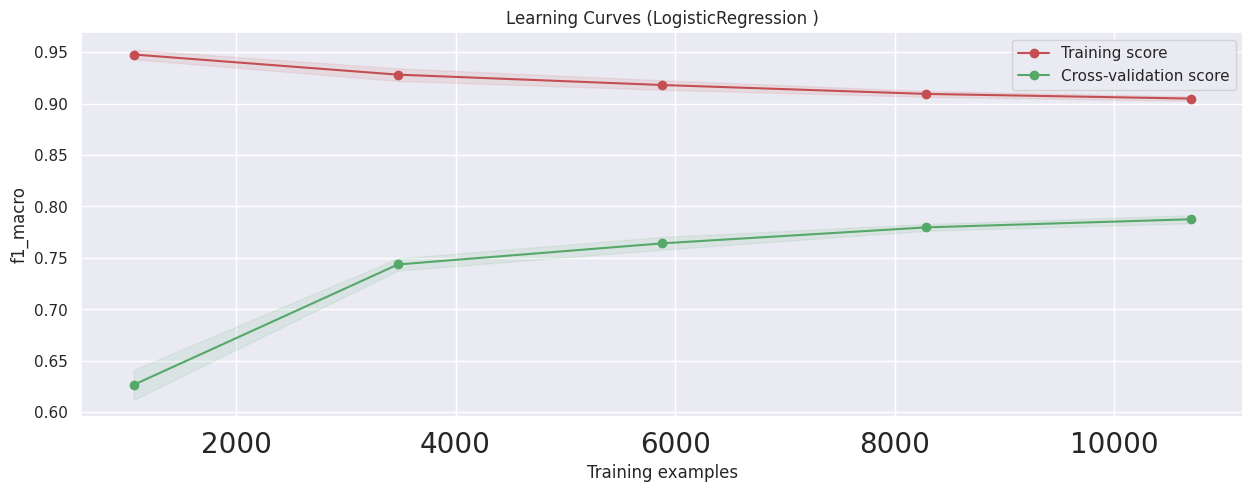

In [108]:
max_ent_bigram_tfidf_chi2_cls = train_and_evaluate_classifier(train_text_bigram_tfidf_chi2_features, encoded_y_train, LogisticRegression(solver='liblinear', class_weight='balanced'), max_ent_grid)

Predicting sentiment on the test set
Classification Report
              precision    recall  f1-score   support

No offensive       0.95      0.92      0.93      2889
   Offensive       0.56      0.67      0.61       453

    accuracy                           0.89      3342
   macro avg       0.76      0.79      0.77      3342
weighted avg       0.89      0.89      0.89      3342

Confusion matrix, without normalization


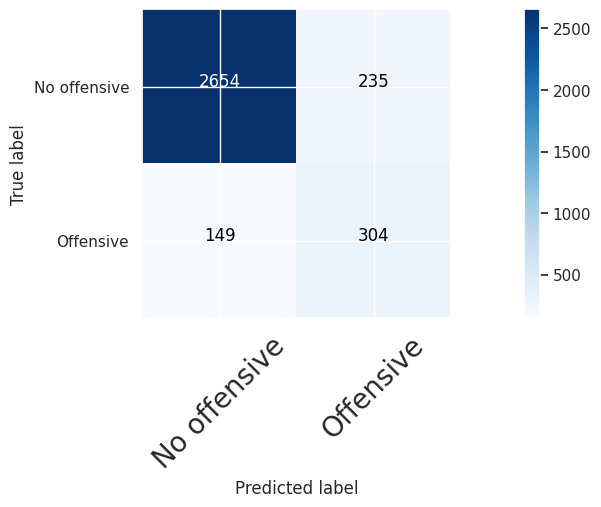

F1 Macro: 0.7727


In [109]:
print("Predicting sentiment on the test set")
y_pred = max_ent_bigram_tfidf_chi2_cls.predict(test_text_bigram_tfidf_chi2_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

print("Classification Report")
print
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)
 
plot_confusion_matrix(cm, classes=target_labels)

print("F1 Macro: %.4f" % f1_score(y_test, y_pred, average='macro'))

## Resumen de Experimentos (2 classes)

| Representación + Algoritmo | F1 Macro |
|---|---|
| BoW (unigramas) + Naive Bayes | 0.6571 |
| BoW (unigramas) + SVM lineal | 0.7472 |
| BoW (unigramas) + Regresión Logística (MaxEnt) | 0.7574 |
| TF-IDF (unigramas) + Regresión Logística (MaxEnt) | 0.7710 |
| BoW (uni+bigramas) + Regresión Logística (MaxEnt) | 0.7768 |
| TF-IDF (uni+bigramas) + Regresión Logística (MaxEnt) | 0.7788 |
| TF-IDF (uni+bigramas) + Chi² (k=5000) + Regresión Logística (MaxEnt) | 0.7727 |

## Baselines con 4 clases

Hasta ahora hemos entrenado los baselines con las etiquetas binarias (Offensive / No offensive). Ahora vamos a repetir los mismos experimentos pero con las 4 clases originales del dataset: **NO** (No ofensivo), **NOM** (Ofensivo menor), **OFG** (Ofensivo grupal) y **OFP** (Ofensivo personal). Reutilizamos las mismas representaciones vectoriales y las mismas funciones de utilidad.

Codificamos las etiquetas esta vez con las 4 clases.

In [40]:
from sklearn import preprocessing

# Etiquetas originales de 4 clases
y_train_4c = dataset[0:len(training_set)][["label"]]
y_test_4c = dataset[len(training_set):len(dataset)][["label"]]

le_4c = preprocessing.LabelEncoder()
le_4c.fit(y_train_4c.label.values)
target_labels_4c = le_4c.classes_
encoded_y_train_4c = le_4c.transform(y_train_4c.label.values)

print(f"Clases: {target_labels_4c}")
print(f"Distribución en train: {dict(zip(*np.unique(encoded_y_train_4c, return_counts=True)))}")

Clases: ['NO' 'NOM' 'OFG' 'OFP']
Distribución en train: {np.int64(0): np.int64(10570), np.int64(1): np.int64(988), np.int64(2): np.int64(169), np.int64(3): np.int64(1641)}


In [38]:
def predict_and_report(classifier, X_test_feat, y_test_true, label_encoder, labels):
    """Predice, muestra classification report y confusion matrix."""
    y_pred = classifier.predict(X_test_feat)
    y_pred = label_encoder.inverse_transform(y_pred)
    
    print("Classification Report")
    print(classification_report(y_test_true, y_pred, target_names=labels))
    
    cm = confusion_matrix(y_test_true, y_pred, labels=labels)
    plot_confusion_matrix(cm, classes=labels)
    plot_confusion_matrix(cm, classes=labels, normalize=True, title='Confusion matrix (normalized)')
    
    f1 = f1_score(y_test_true, y_pred, average='macro')
    print("F1 Macro: %.4f" % f1)
    return f1

### Naive Bayes (4 clases)

Training model
Fitting 5 folds for each of 1 candidates, totalling 5 fits


[CV 2/5] END ..................................., score=0.393 total time=   0.0s[CV 3/5] END ..................................., score=0.400 total time=   0.0s[CV 4/5] END ..................................., score=0.408 total time=   0.0s


[CV 1/5] END ..................................., score=0.422 total time=   0.0s
[CV 5/5] END ..................................., score=0.406 total time=   0.0s
CV-scores for each grid configuration
F1 Macro: 0.406 (+/-0.019) for params: {}

Learning curve for the best estimator


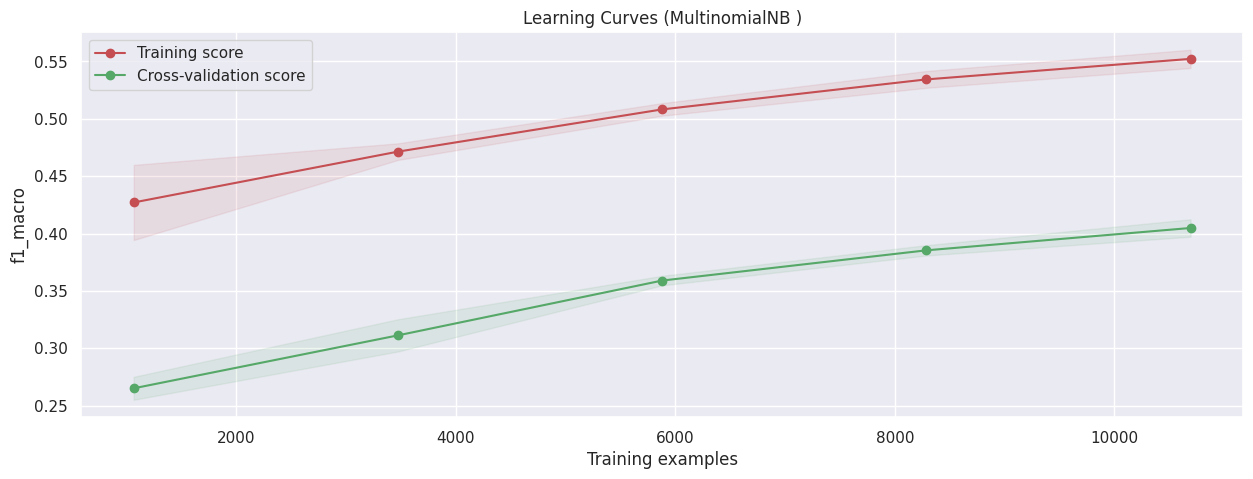

In [39]:
from sklearn.naive_bayes import MultinomialNB

nb_4c_cls = train_and_evaluate_classifier(train_features, encoded_y_train_4c, MultinomialNB(), {})

Classification Report
              precision    recall  f1-score   support

          NO       0.84      0.99      0.91      2642
         NOM       0.75      0.21      0.33       247
         OFG       0.00      0.00      0.00        43
         OFP       0.81      0.27      0.41       410

    accuracy                           0.83      3342
   macro avg       0.60      0.37      0.41      3342
weighted avg       0.82      0.83      0.79      3342

Confusion matrix, without normalization


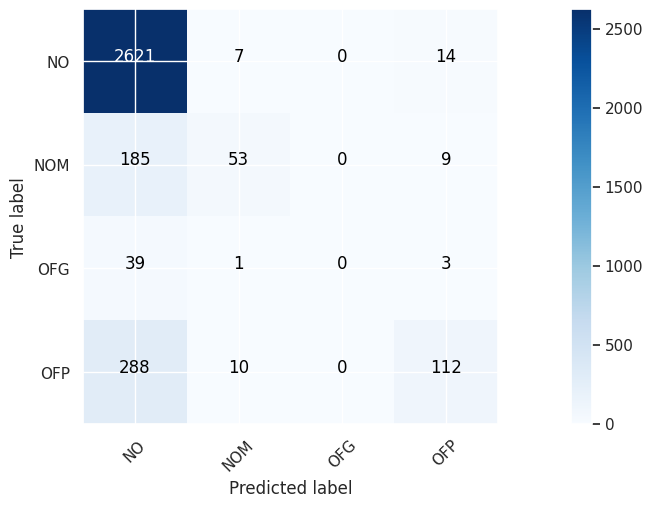

Normalized confusion matrix


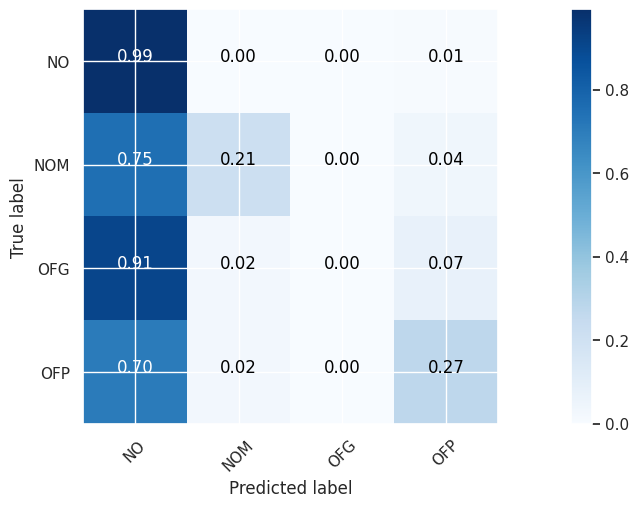

F1 Macro: 0.4124


In [40]:
nb_4c_f1 = predict_and_report(nb_4c_cls, test_features, y_test_4c.label.values, le_4c, target_labels_4c)

### SVM (4 clases)

Training model
Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV 4/5] END ..............C=100, kernel=linear;, score=0.547 total time=   7.5s
[CV 5/5] END ..............C=100, kernel=linear;, score=0.514 total time=   8.1s
[CV 2/5] END ..............C=100, kernel=linear;, score=0.497 total time=   8.5s
[CV 4/5] END ................C=1, kernel=linear;, score=0.597 total time=   7.5s
[CV 3/5] END ................C=1, kernel=linear;, score=0.537 total time=   7.6s
[CV 5/5] END ................C=1, kernel=linear;, score=0.552 total time=   7.6s
[CV 3/5] END ...............C=10, kernel=linear;, score=0.526 total time=   7.9s
[CV 2/5] END ................C=1, kernel=linear;, score=0.544 total time=   7.9s
[CV 1/5] END ..............C=100, kernel=linear;, score=0.509 total time=   7.7s
[CV 4/5] END ...............C=10, kernel=linear;, score=0.572 total time=   7.8s
[CV 1/5] END ................C=1, kernel=linear;, score=0.568 total time=   8.4s
[CV 5/5] END ...............C=10, 

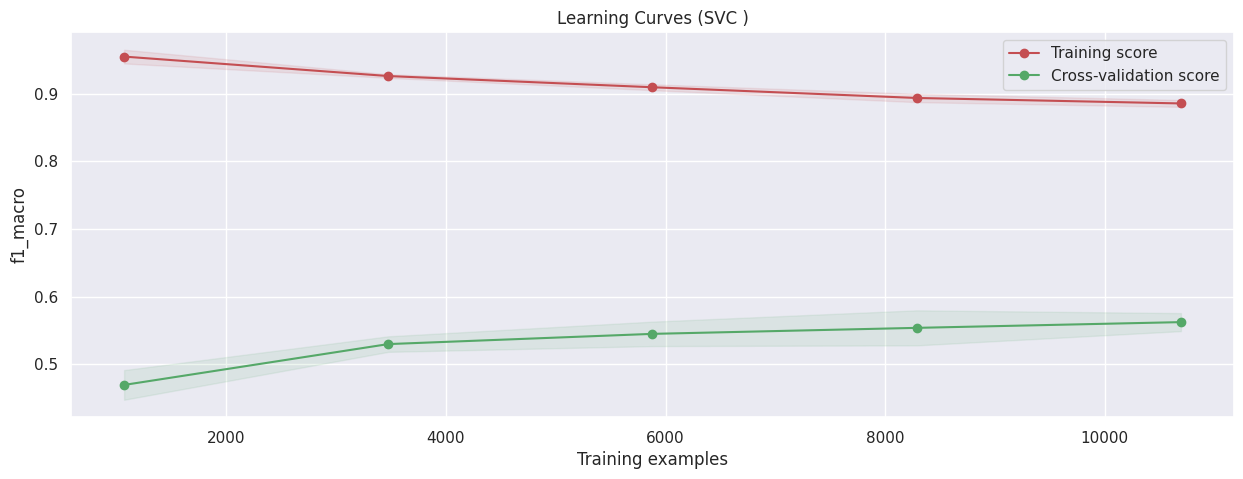

In [41]:
from sklearn.svm import SVC

svm_4c_grid = [
  {'C': [1, 10, 100], 'kernel': ['linear']},
  {'C': [10, 100, 1000], 'gamma': [0.0001], 'kernel': ['rbf']},
]

svm_4c_cls = train_and_evaluate_classifier(train_features, encoded_y_train_4c, SVC(class_weight='balanced'), svm_4c_grid)

Best estimator found by grid search:
SVC(C=1000, class_weight='balanced', gamma=0.0001)
Classification Report
              precision    recall  f1-score   support

          NO       0.94      0.89      0.91      2642
         NOM       0.57      0.74      0.64       247
         OFG       0.07      0.05      0.05        43
         OFP       0.50      0.60      0.55       410

    accuracy                           0.83      3342
   macro avg       0.52      0.57      0.54      3342
weighted avg       0.85      0.83      0.84      3342

Confusion matrix, without normalization


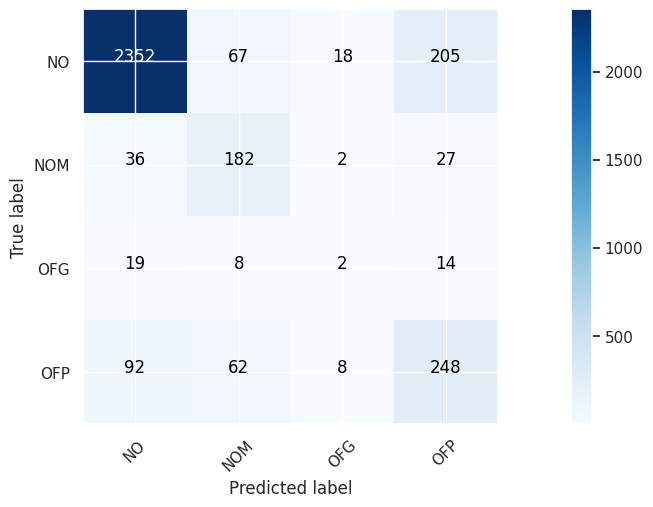

Normalized confusion matrix


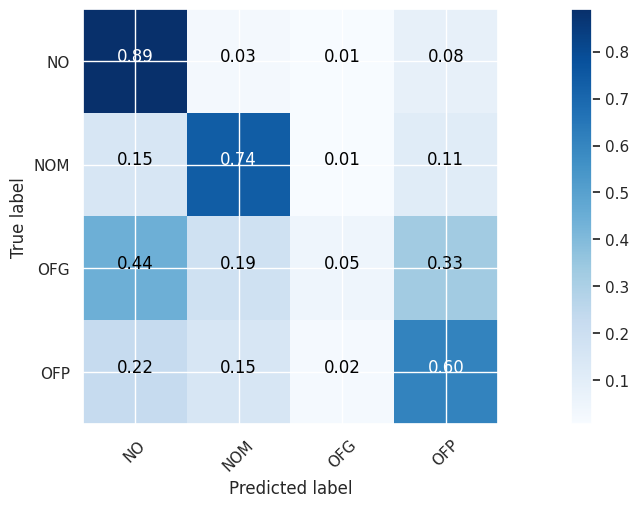

F1 Macro: 0.5404


In [42]:
print("Best estimator found by grid search:")
print(svm_4c_cls.best_estimator_)

svm_4c_f1 = predict_and_report(svm_4c_cls, test_features, y_test_4c.label.values, le_4c, target_labels_4c)

### MaxEnt - BoW unigramas (4 clases)

Training model
Fitting 5 folds for each of 7 candidates, totalling 35 fits
[CV 5/5] END ...............C=0.001, penalty=l2;, score=0.414 total time=   0.1s
[CV 4/5] END ...............C=0.001, penalty=l2;, score=0.417 total time=   0.1s
[CV 1/5] END ...............C=0.001, penalty=l2;, score=0.420 total time=   0.1s
[CV 2/5] END ...............C=0.001, penalty=l2;, score=0.426 total time=   0.1s
[CV 3/5] END ...............C=0.001, penalty=l2;, score=0.432 total time=   0.1s
[CV 1/5] END ................C=0.01, penalty=l2;, score=0.489 total time=   0.2s
[CV 2/5] END ................C=0.01, penalty=l2;, score=0.500 total time=   0.2s
[CV 4/5] END ................C=0.01, penalty=l2;, score=0.493 total time=   0.2s
[CV 3/5] END ................C=0.01, penalty=l2;, score=0.502 total time=   0.4s
[CV 5/5] END ................C=0.01, penalty=l2;, score=0.487 total time=   0.5s
[CV 2/5] END .................C=0.1, penalty=l2;, score=0.565 total time=   0.5s
[CV 2/5] END ...................C=

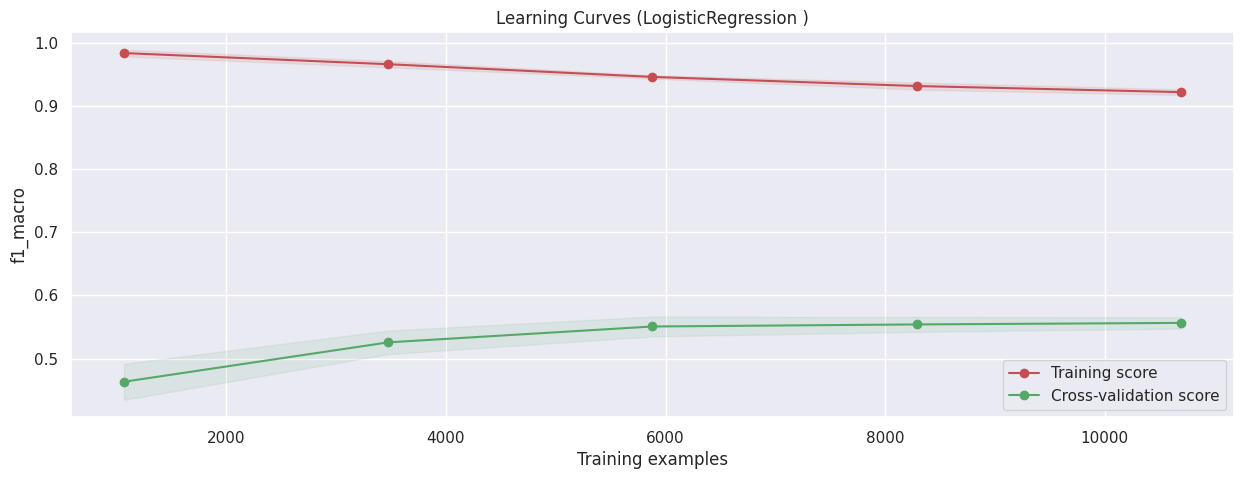

In [43]:
from sklearn.linear_model import LogisticRegression

max_ent_4c_grid = {'penalty': ['l2'], 'C': [0.001,0.01,0.1,1,10,100,1000]}
max_ent_4c_cls = train_and_evaluate_classifier(
    train_features, encoded_y_train_4c,
    LogisticRegression(solver='lbfgs', max_iter=1000, class_weight='balanced'),
    max_ent_4c_grid
)

Best estimator found by grid search:
LogisticRegression(C=1, class_weight='balanced', max_iter=1000, penalty='l2')
Classification Report
              precision    recall  f1-score   support

          NO       0.94      0.90      0.92      2642
         NOM       0.61      0.71      0.66       247
         OFG       0.14      0.14      0.14        43
         OFP       0.54      0.63      0.58       410

    accuracy                           0.84      3342
   macro avg       0.56      0.60      0.57      3342
weighted avg       0.86      0.84      0.85      3342

Confusion matrix, without normalization


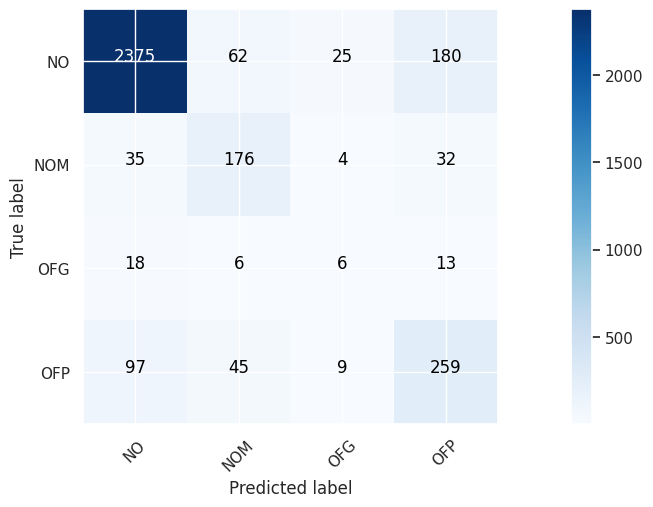

Normalized confusion matrix


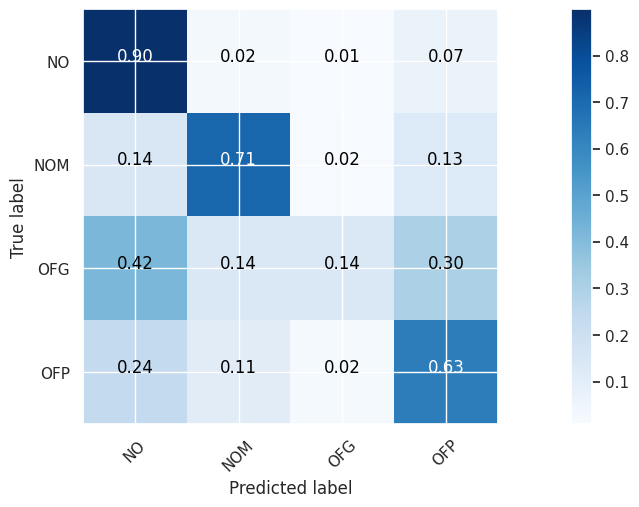

F1 Macro: 0.5733


In [44]:
print("Best estimator found by grid search:")
print(max_ent_4c_cls.best_estimator_)

maxent_bow_4c_f1 = predict_and_report(max_ent_4c_cls, test_features, y_test_4c.label.values, le_4c, target_labels_4c)

### MaxEnt - TF-IDF (4 clases)

Training model
Fitting 5 folds for each of 7 candidates, totalling 35 fits
[CV 3/5] END ...............C=0.001, penalty=l2;, score=0.532 total time=   0.0s
[CV 4/5] END ...............C=0.001, penalty=l2;, score=0.549 total time=   0.0s
[CV 5/5] END ...............C=0.001, penalty=l2;, score=0.522 total time=   0.0s
[CV 1/5] END ...............C=0.001, penalty=l2;, score=0.539 total time=   0.0s
[CV 2/5] END ...............C=0.001, penalty=l2;, score=0.536 total time=   0.1s
[CV 3/5] END ................C=0.01, penalty=l2;, score=0.544 total time=   0.1s
[CV 1/5] END ................C=0.01, penalty=l2;, score=0.547 total time=   0.1s
[CV 2/5] END ................C=0.01, penalty=l2;, score=0.547 total time=   0.1s
[CV 4/5] END ................C=0.01, penalty=l2;, score=0.557 total time=   0.1s
[CV 5/5] END ................C=0.01, penalty=l2;, score=0.533 total time=   0.2s
[CV 2/5] END .................C=0.1, penalty=l2;, score=0.575 total time=   0.6s
[CV 3/5] END .................C=0.

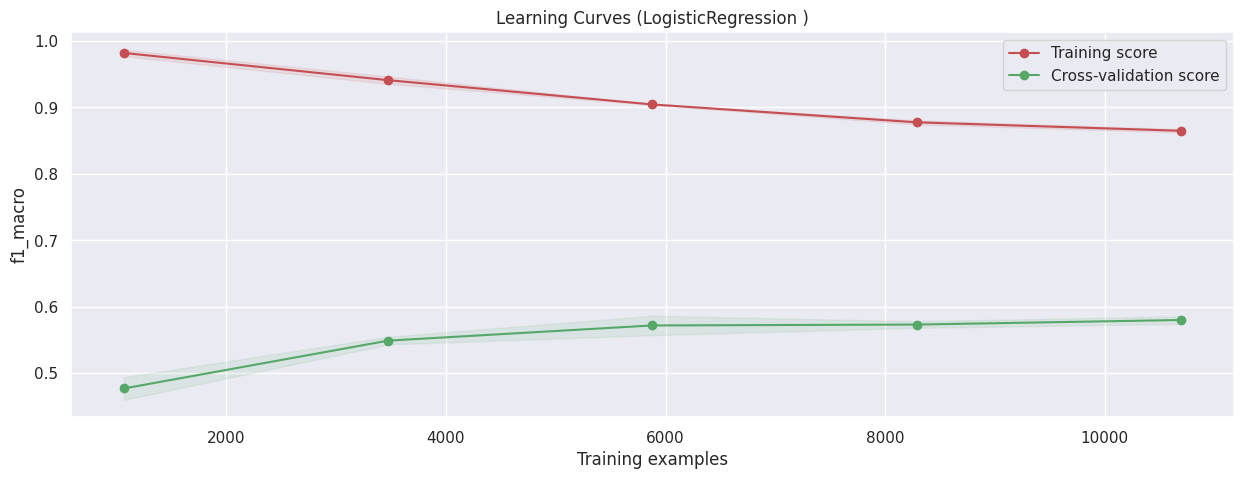

In [45]:
max_ent_tfidf_4c_cls = train_and_evaluate_classifier(
    train_text_tfidf_features, encoded_y_train_4c,
    LogisticRegression(solver='lbfgs', max_iter=1000, class_weight='balanced'),
    max_ent_4c_grid
)

Best estimator found by grid search:
LogisticRegression(C=1, class_weight='balanced', max_iter=1000, penalty='l2')
Classification Report
              precision    recall  f1-score   support

          NO       0.94      0.91      0.93      2642
         NOM       0.63      0.72      0.67       247
         OFG       0.15      0.19      0.17        43
         OFP       0.57      0.61      0.59       410

    accuracy                           0.85      3342
   macro avg       0.57      0.61      0.59      3342
weighted avg       0.86      0.85      0.86      3342

Confusion matrix, without normalization


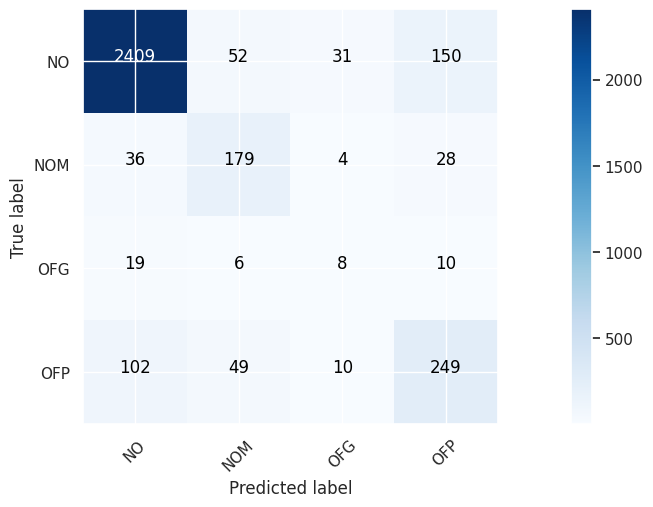

Normalized confusion matrix


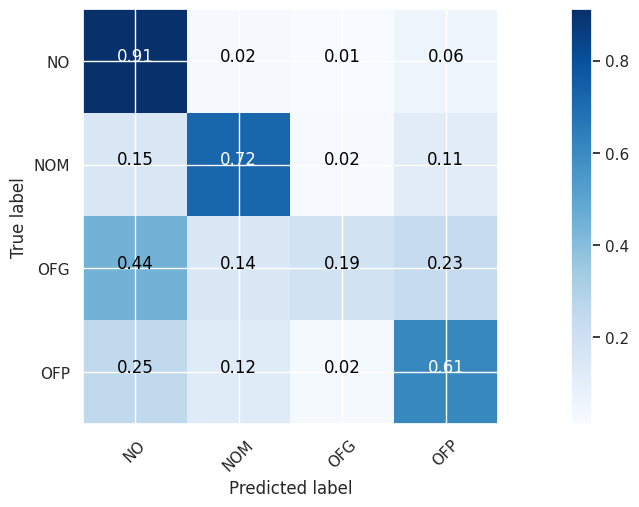

F1 Macro: 0.5879


In [46]:
print("Best estimator found by grid search:")
print(max_ent_tfidf_4c_cls.best_estimator_)

maxent_tfidf_4c_f1 = predict_and_report(max_ent_tfidf_4c_cls, test_text_tfidf_features, y_test_4c.label.values, le_4c, target_labels_4c)

### MaxEnt - Bigramas (4 clases)

Training model
Fitting 5 folds for each of 7 candidates, totalling 35 fits
[CV 1/5] END ...............C=0.001, penalty=l2;, score=0.426 total time=   0.5s
[CV 5/5] END ...............C=0.001, penalty=l2;, score=0.420 total time=   0.6s
[CV 3/5] END ...............C=0.001, penalty=l2;, score=0.438 total time=   0.6s
[CV 2/5] END ...............C=0.001, penalty=l2;, score=0.432 total time=   0.7s
[CV 4/5] END ...............C=0.001, penalty=l2;, score=0.423 total time=   0.9s
[CV 1/5] END ................C=0.01, penalty=l2;, score=0.505 total time=   1.2s
[CV 5/5] END .................C=0.1, penalty=l2;, score=0.572 total time=   3.7s
[CV 3/5] END ................C=0.01, penalty=l2;, score=0.521 total time=   3.8s
[CV 5/5] END ................C=0.01, penalty=l2;, score=0.506 total time=   4.7s
[CV 4/5] END ................C=0.01, penalty=l2;, score=0.512 total time=   4.8s
[CV 3/5] END .................C=0.1, penalty=l2;, score=0.567 total time=   5.3s
[CV 3/5] END ...................C=

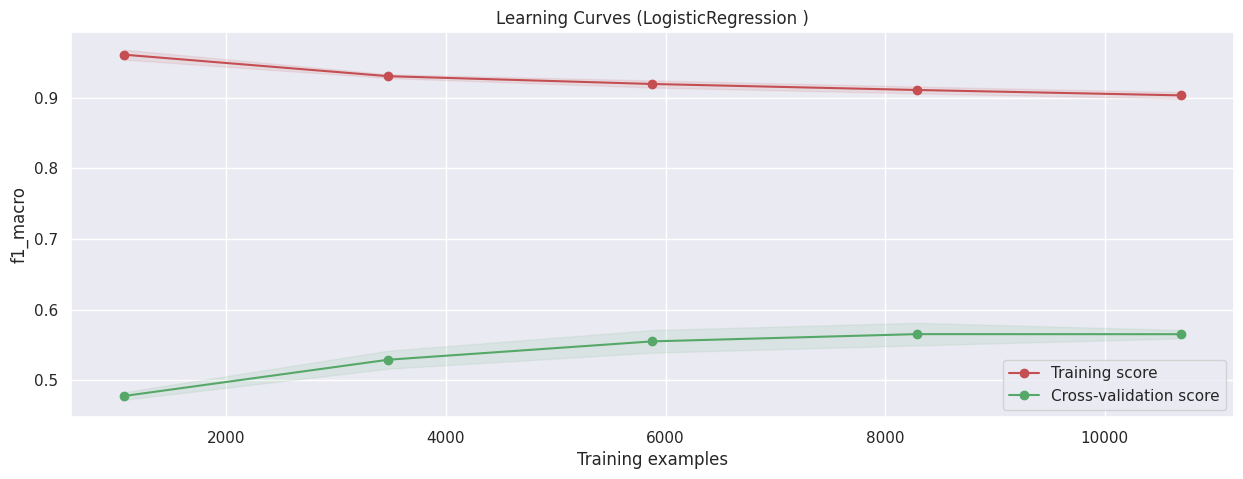

In [47]:
max_ent_bigram_4c_cls = train_and_evaluate_classifier(
    train_bigram_features, encoded_y_train_4c,
    LogisticRegression(solver='lbfgs', max_iter=1000, class_weight='balanced'),
    max_ent_4c_grid
)

Best estimator found by grid search:
LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000, penalty='l2')
Classification Report
              precision    recall  f1-score   support

          NO       0.94      0.90      0.92      2642
         NOM       0.63      0.74      0.68       247
         OFG       0.19      0.12      0.14        43
         OFP       0.52      0.63      0.57       410

    accuracy                           0.85      3342
   macro avg       0.57      0.60      0.58      3342
weighted avg       0.86      0.85      0.85      3342

Confusion matrix, without normalization


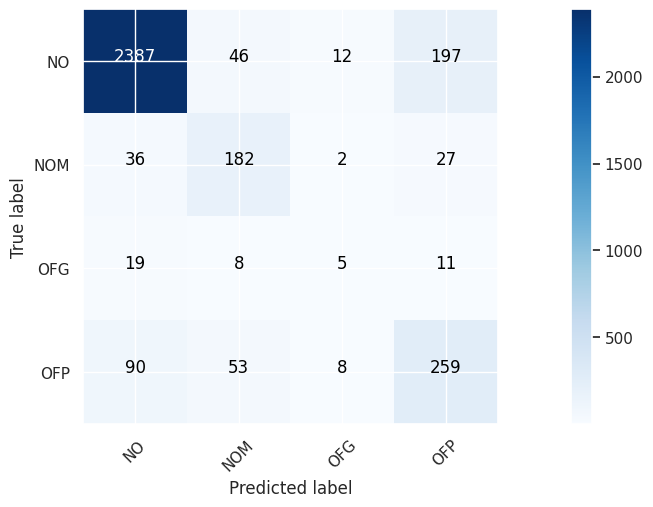

Normalized confusion matrix


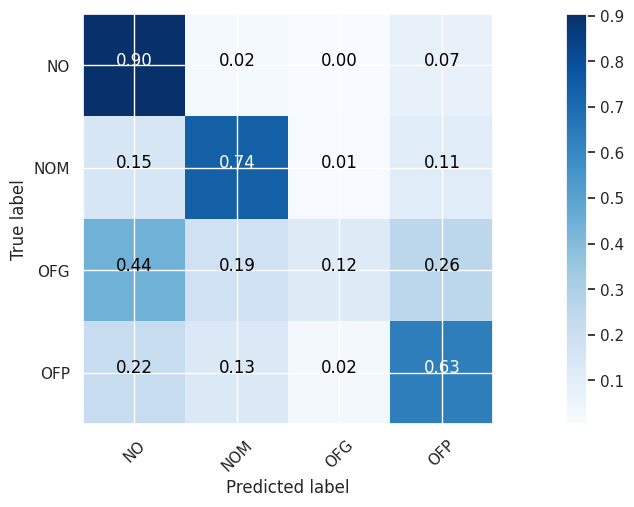

F1 Macro: 0.5794


In [48]:
print("Best estimator found by grid search:")
print(max_ent_bigram_4c_cls.best_estimator_)

maxent_bigram_4c_f1 = predict_and_report(max_ent_bigram_4c_cls, test_bigram_features, y_test_4c.label.values, le_4c, target_labels_4c)

### MaxEnt - Bigramas con TF-IDF (4 clases)

Training model
Fitting 5 folds for each of 7 candidates, totalling 35 fits
[CV 4/5] END ...............C=0.001, penalty=l2;, score=0.566 total time=   0.2s
[CV 5/5] END ...............C=0.001, penalty=l2;, score=0.545 total time=   0.2s
[CV 1/5] END ...............C=0.001, penalty=l2;, score=0.545 total time=   0.2s
[CV 3/5] END ...............C=0.001, penalty=l2;, score=0.548 total time=   0.2s
[CV 2/5] END ...............C=0.001, penalty=l2;, score=0.552 total time=   0.2s
[CV 1/5] END ................C=0.01, penalty=l2;, score=0.551 total time=   0.9s
[CV 2/5] END ................C=0.01, penalty=l2;, score=0.562 total time=   1.8s
[CV 4/5] END ................C=0.01, penalty=l2;, score=0.573 total time=   1.9s
[CV 3/5] END ................C=0.01, penalty=l2;, score=0.555 total time=   2.0s
[CV 5/5] END ................C=0.01, penalty=l2;, score=0.547 total time=   2.4s
[CV 3/5] END .................C=0.1, penalty=l2;, score=0.577 total time=   3.6s
[CV 4/5] END .................C=0.

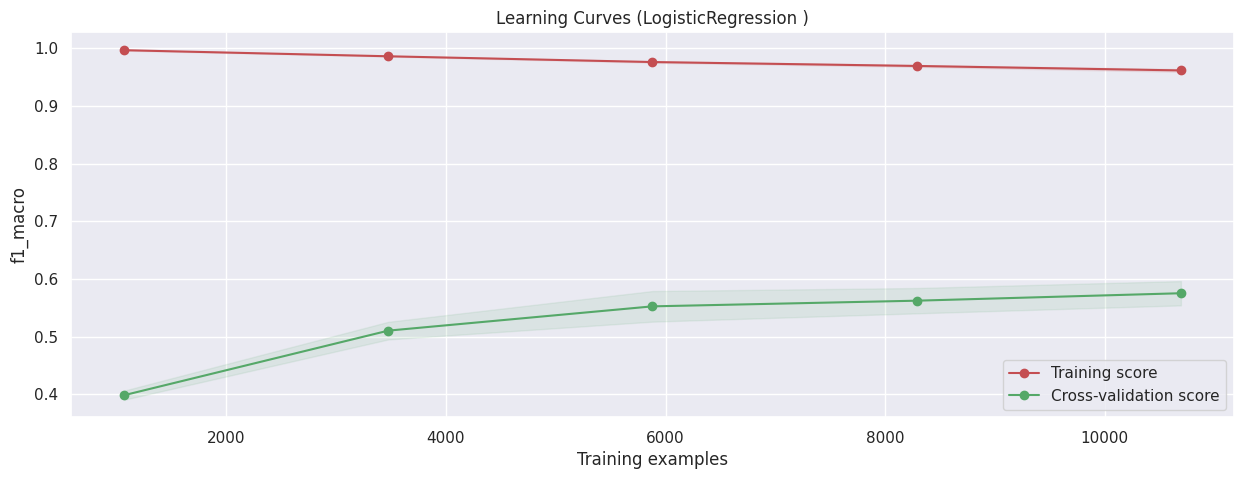

In [49]:
max_ent_bigram_tfidf_4c_cls = train_and_evaluate_classifier(
    train_text_bigram_tfidf_features, encoded_y_train_4c,
    LogisticRegression(solver='lbfgs', max_iter=1000, class_weight='balanced'),
    max_ent_4c_grid
)

Best estimator found by grid search:
LogisticRegression(C=1, class_weight='balanced', max_iter=1000, penalty='l2')
Classification Report
              precision    recall  f1-score   support

          NO       0.93      0.93      0.93      2642
         NOM       0.63      0.73      0.67       247
         OFG       0.17      0.14      0.15        43
         OFP       0.61      0.58      0.60       410

    accuracy                           0.86      3342
   macro avg       0.58      0.60      0.59      3342
weighted avg       0.86      0.86      0.86      3342

Confusion matrix, without normalization


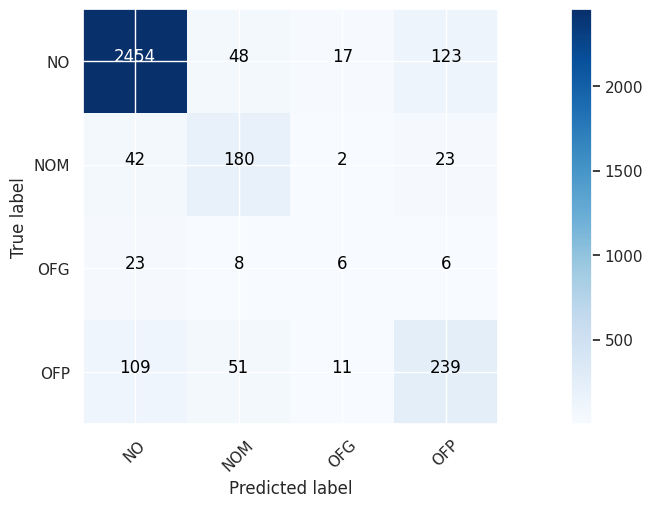

Normalized confusion matrix


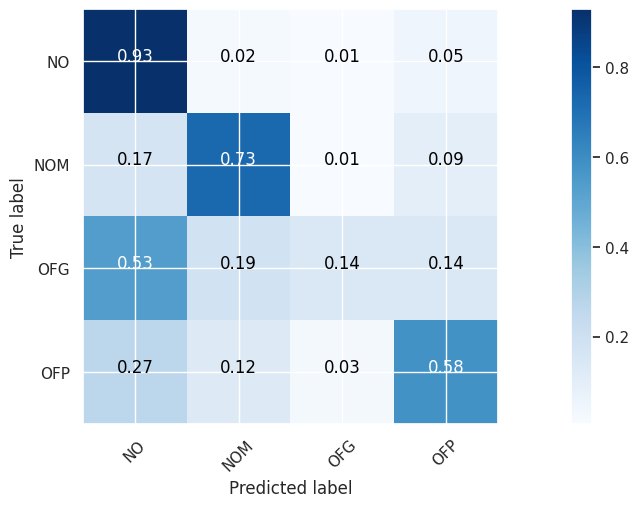

F1 Macro: 0.5885


In [50]:
print("Best estimator found by grid search:")
print(max_ent_bigram_tfidf_4c_cls.best_estimator_)

maxent_bigram_tfidf_4c_f1 = predict_and_report(max_ent_bigram_tfidf_4c_cls, test_text_bigram_tfidf_features, y_test_4c.label.values, le_4c, target_labels_4c)

### MaxEnt - Bigramas con TF-IDF y Chi² k=5000 (4 clases)

Training model
Fitting 5 folds for each of 7 candidates, totalling 35 fits
[CV 1/5] END ...............C=0.001, penalty=l2;, score=0.535 total time=   0.0s
[CV 2/5] END ...............C=0.001, penalty=l2;, score=0.546 total time=   0.0s
[CV 3/5] END ...............C=0.001, penalty=l2;, score=0.540 total time=   0.0s
[CV 4/5] END ...............C=0.001, penalty=l2;, score=0.559 total time=   0.0s
[CV 5/5] END ...............C=0.001, penalty=l2;, score=0.534 total time=   0.0s
[CV 1/5] END ................C=0.01, penalty=l2;, score=0.536 total time=   0.0s
[CV 2/5] END ................C=0.01, penalty=l2;, score=0.557 total time=   0.0s
[CV 4/5] END ................C=0.01, penalty=l2;, score=0.567 total time=   0.0s
[CV 5/5] END ................C=0.01, penalty=l2;, score=0.547 total time=   0.0s
[CV 3/5] END ................C=0.01, penalty=l2;, score=0.549 total time=   0.0s
[CV 5/5] END .................C=0.1, penalty=l2;, score=0.577 total time=   0.1s
[CV 3/5] END .................C=0.

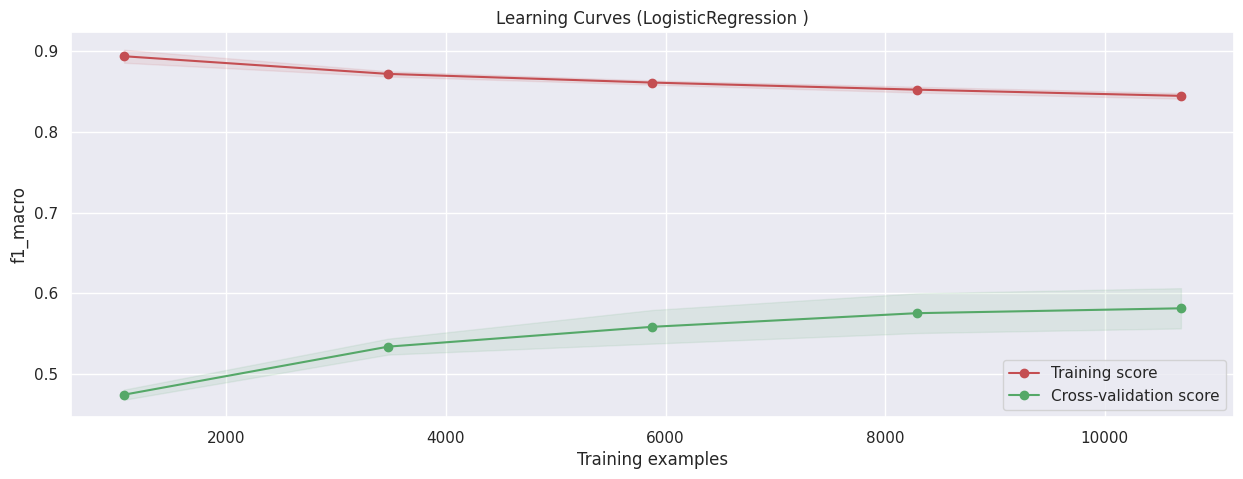

In [51]:
# Recomputamos chi2 con las 4 clases porque la selección de features depende de las etiquetas
bigram_tfidf_chi2_vect_4c = TfidfVectorizer(norm="l2", ngram_range=(1,2))
train_text_bigram_tfidf_chi2_4c = bigram_tfidf_chi2_vect_4c.fit_transform(X_train.clean_comment)
test_text_bigram_tfidf_chi2_4c = bigram_tfidf_chi2_vect_4c.transform(X_test.clean_comment)

ch2_4c = SelectKBest(chi2, k=5000)
train_text_bigram_tfidf_chi2_4c = ch2_4c.fit_transform(train_text_bigram_tfidf_chi2_4c, y_train_4c.label.values)
test_text_bigram_tfidf_chi2_4c = ch2_4c.transform(test_text_bigram_tfidf_chi2_4c)

max_ent_bigram_tfidf_chi2_4c_cls = train_and_evaluate_classifier(
    train_text_bigram_tfidf_chi2_4c, encoded_y_train_4c,
    LogisticRegression(solver='lbfgs', max_iter=1000, class_weight='balanced'),
    max_ent_4c_grid
)

Best estimator found by grid search:
LogisticRegression(C=1, class_weight='balanced', max_iter=1000, penalty='l2')
Classification Report
              precision    recall  f1-score   support

          NO       0.94      0.90      0.92      2642
         NOM       0.61      0.74      0.67       247
         OFG       0.13      0.14      0.13        43
         OFP       0.53      0.62      0.57       410

    accuracy                           0.84      3342
   macro avg       0.55      0.60      0.57      3342
weighted avg       0.86      0.84      0.85      3342

Confusion matrix, without normalization


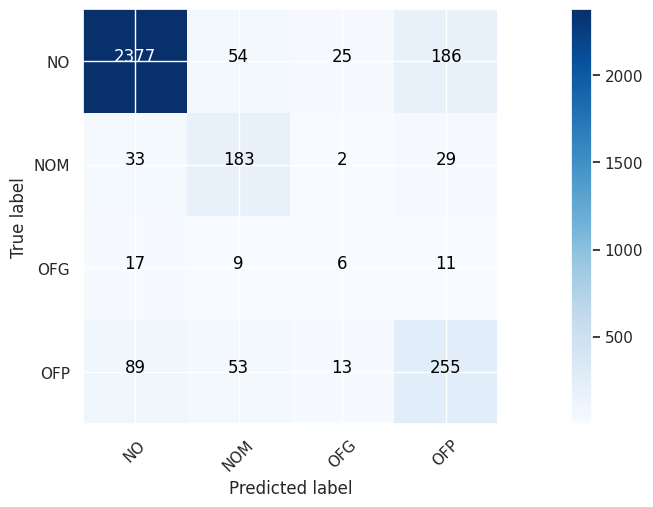

Normalized confusion matrix


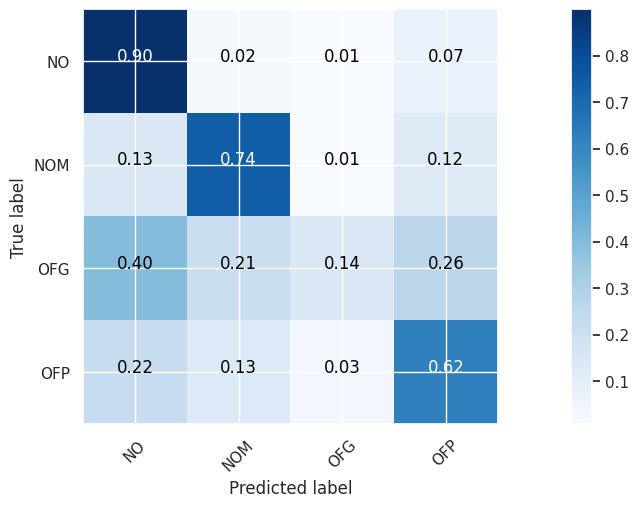

F1 Macro: 0.5748


In [52]:
print("Best estimator found by grid search:")
print(max_ent_bigram_tfidf_chi2_4c_cls.best_estimator_)

maxent_chi2_4c_f1 = predict_and_report(max_ent_bigram_tfidf_chi2_4c_cls, test_text_bigram_tfidf_chi2_4c, y_test_4c.label.values, le_4c, target_labels_4c)

## Resumen de Experimentos (4 clases)

| Representación + Algoritmo | F1 Macro (4 clases) |
|---|---|
| BoW (unigramas) + Naive Bayes | 0.4124 |
| BoW (unigramas) + SVM lineal | 0.5404 |
| BoW (unigramas) + Regresión Logística (MaxEnt) | 0.5733 |
| TF-IDF (unigramas) + Regresión Logística (MaxEnt) | 0.5879 |
| BoW (uni+bigramas) + Regresión Logística (MaxEnt) | 0.5794 |
| TF-IDF (uni+bigramas) + Regresión Logística (MaxEnt) | 0.5885 |
| TF-IDF (uni+bigramas) + Chi² (k=5000) + Regresión Logística (MaxEnt) | 0.5748 |

# Algoritmos de aprendizaje profundo
En los siguientes apartados vamos a implementar algoritmos de aprendizaje profundo.
Vamos a utilizar las librerías **Pytorch** y **transformers** de **Hugging Face**.

## Utilidades

In [37]:
# Importamos capas densas, capas de embeddings y capas para el aplanaEl hecho de que de una manera se pueda explicar el resultado del modelo ayuda do de dimensiones
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [86]:
def print_model_info(model):
    print("=" * 80)
    print("MODEL ARCHITECTURE")
    print("=" * 80)
    print(model)
    print()
    
    print("=" * 80)
    print("MODEL PARAMETERS")
    print("=" * 80)
    
    total_params = 0
    trainable_params = 0
    
    print(f"{'Layer':<40} {'Parameters':<15} {'Shape':<20}")
    print("-" * 80)
    
    for name, param in model.named_parameters():
        num_params = param.numel()
        total_params += num_params
        if param.requires_grad:
            trainable_params += num_params
        
        print(f"{name:<40} {num_params:<15,} {str(list(param.shape)):<20}")
    
    print("-" * 80)
    print(f"{'Total Parameters:':<40} {total_params:,}")
    print(f"{'Trainable Parameters:':<40} {trainable_params:,}")
    print(f"{'Non-trainable Parameters:':<40} {(total_params - trainable_params):,}")
    
    param_size = sum(p.numel() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.numel() * b.element_size() for b in model.buffers())
    size_mb = (param_size + buffer_size) / 1024**2
    
    print(f"{'Model Size:':<40} {size_mb:.2f} MB")
    print("=" * 80)

In [87]:
# Con esta función podremos ver cómo evoluciona el entrenamiento y la validación de los modelos.

import matplotlib.pyplot as plt
plt.style.use('ggplot')

# Clase similar a la estructura que se obtiene al entrenar los modelos en tf.keras
class History:
    def __init__(self):
        self.history = {
            'loss': [],
            'acc': [],
            'val_loss': [],
            'val_acc': []
        }

def plot_history(history, metric='acc'):
    acc = history.history[metric]
    val_acc = history.history[f'val_{metric}']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    x = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(x, acc, 'b', label='Training acc')
    plt.plot(x, val_acc, 'r', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(x, loss, 'b', label='Training loss')
    plt.plot(x, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

In [88]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np

def _is_binary_criterion(criterion):
    """Binary criteria expect float targets of shape [N, 1]."""
    return (
        isinstance(criterion, (nn.BCELoss, nn.BCEWithLogitsLoss))
        or getattr(criterion, 'expects_float_targets', False)
    )

def train_pytorch_model(
    model,
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    optimizer=None,
    criterion=None,
    device=None,
    patience=5,
    scheduler=None
):    
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    # Se mueve el modelo al device (CPU o GPU)
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    is_text_data = isinstance(X_train, torch.Tensor) and X_train.dtype == torch.long

    if hasattr(X_train, 'toarray'):
        X_train = X_train.toarray()

    if not isinstance(X_train, torch.Tensor):
        if is_text_data or X_train.dtype in [np.int32, np.int64]:
            X_train = torch.LongTensor(np.array(X_train))
        else:
            X_train = torch.FloatTensor(np.array(X_train).astype('float32'))

    if _is_binary_criterion(criterion):
        if not isinstance(y_train, torch.Tensor):
            y_train = torch.FloatTensor(np.array(y_train).astype('float32'))
    elif isinstance(criterion, nn.CrossEntropyLoss):
        if not isinstance(y_train, torch.Tensor):
            y_train = torch.LongTensor(np.array(y_train))
    else:
        if not isinstance(y_train, torch.Tensor):
            y_train = torch.FloatTensor(np.array(y_train).astype('float32'))

    # Train/validation split
    if validation_split > 0:
        X_numpy = X_train.numpy() if isinstance(X_train, torch.Tensor) else X_train
        y_numpy = y_train.numpy() if isinstance(y_train, torch.Tensor) else y_train
        
        X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
            X_numpy, y_numpy, test_size=validation_split, random_state=42
        )

        if X_train.dtype == torch.long:
            X_train_split = torch.LongTensor(X_train_split)
            X_val_split = torch.LongTensor(X_val_split)
        else:
            X_train_split = torch.FloatTensor(X_train_split)
            X_val_split = torch.FloatTensor(X_val_split)

        if y_train.dtype == torch.long:
            y_train_split = torch.LongTensor(y_train_split)
            y_val_split = torch.LongTensor(y_val_split)
        else:
            y_train_split = torch.FloatTensor(y_train_split)
            y_val_split = torch.FloatTensor(y_val_split)
    else:
        X_train_split, y_train_split = X_train, y_train
        X_val_split, y_val_split = None, None

    if _is_binary_criterion(criterion) and y_train_split.dim() == 1:
        y_train_split = y_train_split.unsqueeze(1)
        if validation_split > 0:
            y_val_split = y_val_split.unsqueeze(1)

    # Los datasets son directamente TensorDataset de Pytorch
    train_dataset = TensorDataset(X_train_split, y_train_split)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    if validation_split > 0:
        val_dataset = TensorDataset(X_val_split, y_val_split)
        val_loader = DataLoader(val_dataset, batch_size=batch_size)

    # Inicializar el histórico
    history = History()

    # Rutina de entrenamiento
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            # Forward pass
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            # Backward pass
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            
            if isinstance(criterion, nn.CrossEntropyLoss):
                predicted = torch.argmax(outputs, dim=1)
                train_total += batch_y.size(0)
                train_correct += (predicted == batch_y).sum().item()
            else:
                predicted = (outputs > 0.5).float()
                train_total += batch_y.size(0)
                train_correct += (predicted == batch_y).sum().item()

        # Métricas de entrenamiento: Train loss, train accuracy
        epoch_train_loss = train_loss / len(train_loader)
        epoch_train_acc = train_correct / train_total
        history.history['loss'].append(epoch_train_loss)
        history.history['acc'].append(epoch_train_acc)

        if validation_split > 0:
            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0

            # Modelo en modo inferencia sin guardar los gradientes
            with torch.no_grad():
                for batch_X, batch_y in val_loader:
                    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                    outputs = model(batch_X)
                    loss = criterion(outputs, batch_y)
                    val_loss += loss.item()

                    if isinstance(criterion, nn.CrossEntropyLoss):
                        predicted = torch.argmax(outputs, dim=1)
                    else:
                        predicted = (outputs > 0.5).float()

                    val_total += batch_y.size(0)
                    val_correct += (predicted == batch_y).sum().item()

            epoch_val_loss = val_loss / len(val_loader)
            epoch_val_acc = val_correct / val_total
            history.history['val_loss'].append(epoch_val_loss)
            history.history['val_acc'].append(epoch_val_acc)

            if scheduler is not None:
                if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    scheduler.step(epoch_val_loss)
                else:
                    scheduler.step()
                print(f"Stepping learning rate to value: {scheduler.get_lr()}")

            if epoch_val_loss < best_val_loss:
                best_val_loss = epoch_val_loss
                patience_counter = 0
                # Guardar mejor modelo
                best_model_state = model.state_dict().copy()
            else:
                patience_counter += 1
                print(f" (patience: {patience_counter}/{patience})")

            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                # Restaurar mejor modelo
                model.load_state_dict(best_model_state)
                break
        else:
            history.history['val_loss'].append(0.0)
            history.history['val_acc'].append(0.0)

        if validation_split > 0:
            print(f'Epoch {epoch+1}/{epochs} - '
                  f'loss: {epoch_train_loss:.4f} - '
                  f'acc: {epoch_train_acc:.4f} - '
                  f'val_loss: {epoch_val_loss:.4f} - '
                  f'val_acc: {epoch_val_acc:.4f}')
        else:
            print(f'Epoch {epoch+1}/{epochs} - '
                  f'loss: {epoch_train_loss:.4f} - '
                  f'acc: {epoch_train_acc:.4f}')

    return history


In [89]:
def evaluate_pytorch_model(model, X_test, y_test, le=None, target_labels=None, device=None, batch_size=32):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model.eval()

    if hasattr(X_test, 'toarray'):
        X_test_array = X_test.toarray().astype('float32')
        X_test_tensor = torch.FloatTensor(X_test_array)
    elif isinstance(X_test, torch.Tensor):
        X_test_tensor = X_test.cpu()
    else:
        X_test_array = np.array(X_test)
        if X_test_array.dtype in [np.int32, np.int64]:
            X_test_tensor = torch.LongTensor(X_test_array)
        else:
            X_test_tensor = torch.FloatTensor(X_test_array.astype('float32'))

    if isinstance(y_test, torch.Tensor):
        y_test = y_test.cpu().numpy()
    else:
        y_test = np.array(y_test)

    from torch.utils.data import TensorDataset, DataLoader

    dataset = TensorDataset(X_test_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    all_predictions = []

    with torch.no_grad():
        # En algunos entrenamientos con CNN, pasar como en la prácica anterior un batch del tamaño del test set
        # hacia que la GPU se quedara sin memoria, por eso paso un mini batch. Los resultados de 
        # evaluación deberían ser los mismos.
        for batch in dataloader:
            batch_X = batch[0].to(device)
            outputs = model(batch_X).cpu()
            
            if outputs.shape[1] == 1:
                # Si la salida es tamaño 1, como mencionado anteriormente, se usa un threshold
                # en 0.5 para diferenciar entre una clase u otra
                batch_pred = (outputs.numpy() > 0.5).astype(int).flatten()
            else:
                # Si la salida es de tamaño > 1, entonces la clase escogida
                # es aquella que tenga la probabilidad más alta (por eso argmax)
                batch_pred = torch.argmax(outputs, dim=1).numpy()
            
            all_predictions.append(batch_pred)
    
    y_pred = np.concatenate(all_predictions)
    
    if le is not None:
        y_pred_labels = le.inverse_transform(y_pred)
        if y_test.dtype in [np.int32, np.int64]:
            y_test_labels = le.inverse_transform(y_test)
        else:
            y_test_labels = y_test
    else:
        y_pred_labels = y_pred
        y_test_labels = y_test
    
    if target_labels is None:
        unique_labels = np.unique(np.concatenate([y_test_labels, y_pred_labels]))
        target_labels = sorted(unique_labels)
    
    print("Classification Report")
    print(classification_report(y_test_labels, y_pred_labels, target_names=target_labels))
    cm = confusion_matrix(y_test_labels, y_pred_labels, labels=target_labels)
    plot_confusion_matrix(cm, classes=target_labels)
    print("F1 Macro: %.4f" % f1_score(y_test_labels, y_pred_labels, average='macro'))
    
    return y_pred_labels

In [90]:
#Número de épocas (iteraciones globales)
epochs = 40
#Dimensión de la capa de embeddings
emb_dim = 50
#Tamaño de batch (lote)
batch_size = 32
#Número de palabras tenidas en cuenta (reducción del vocabulario)
n_most_common_words = 50000
#Máxima longitud del documento
max_len = 512

## Entrenamiento de modelos MLP
Vamos a comenzar con el entrenamiento de un modelo basado en redes neuronales Fully Connected con una representación TF-IDF.

In [35]:
Y_train = encoded_y_train  # Shape: (n_samples,)
Y_test = le.transform(y_test.values)

print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")

print(Y_train[0:10])

Y_train shape: (13368,)
Y_test shape: (3342,)
[0 0 0 0 0 0 0 0 0 0]


### Standard MLP

En este caso, la salida es una única neurona. La activación de salida puede estar entre 0 y 1. Si la salida es mayor de 0.5 corresponderá con una clase y si es menor, con la otra clase.

In [92]:
class BinaryClassifierMLP(nn.Module):
    def __init__(self, input_dim):
        super(BinaryClassifierMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        # Single output neuron
        self.fc3 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = F.softmax(x, dim=1)

        x = self.fc2(x)
        x = F.softmax(x, dim=1)
        
        x = self.fc3(x)
        x = F.sigmoid(x)

        return x

In [93]:
input_dim = train_text_tfidf_features.shape[1]
model = BinaryClassifierMLP(input_dim)
model = model.to(device)
print_model_info(model)

MODEL ARCHITECTURE
BinaryClassifierMLP(
  (fc1): Linear(in_features=22969, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
fc1.weight                               2,940,032       [128, 22969]        
fc1.bias                                 128             [128]               
fc2.weight                               8,192           [64, 128]           
fc2.bias                                 64              [64]                
fc3.weight                               64              [1, 64]             
fc3.bias                                 1               [1]                 
--------------------------------------------------------------------------------
Total Parameters:                        2,948,4

En estos entrenamientos vamos a usar siempre la técnica de **early stopping**. Se parará el entrenamiento cuando se detecte que **val_loss** no crece durante un determinado número de epochs **patience**.

Epoch 1/40 - loss: 0.6148 - acc: 0.7753 - val_loss: 0.5301 - val_acc: 0.8598
Epoch 2/40 - loss: 0.4753 - acc: 0.8658 - val_loss: 0.4437 - val_acc: 0.8598
Epoch 3/40 - loss: 0.4190 - acc: 0.8658 - val_loss: 0.4144 - val_acc: 0.8598
Epoch 4/40 - loss: 0.4003 - acc: 0.8658 - val_loss: 0.4054 - val_acc: 0.8598
Epoch 5/40 - loss: 0.3891 - acc: 0.8658 - val_loss: 0.3953 - val_acc: 0.8598
Epoch 6/40 - loss: 0.3629 - acc: 0.8658 - val_loss: 0.3642 - val_acc: 0.8598
Epoch 7/40 - loss: 0.3097 - acc: 0.8658 - val_loss: 0.3274 - val_acc: 0.8598
Epoch 8/40 - loss: 0.2546 - acc: 0.8658 - val_loss: 0.3017 - val_acc: 0.8598
Epoch 9/40 - loss: 0.2079 - acc: 0.9003 - val_loss: 0.2884 - val_acc: 0.9009
Epoch 10/40 - loss: 0.1747 - acc: 0.9455 - val_loss: 0.2848 - val_acc: 0.9069
 (patience: 1/5)
Epoch 11/40 - loss: 0.1504 - acc: 0.9546 - val_loss: 0.2864 - val_acc: 0.9031
 (patience: 2/5)
Epoch 12/40 - loss: 0.1320 - acc: 0.9608 - val_loss: 0.2902 - val_acc: 0.8987
 (patience: 3/5)
Epoch 13/40 - loss: 0.

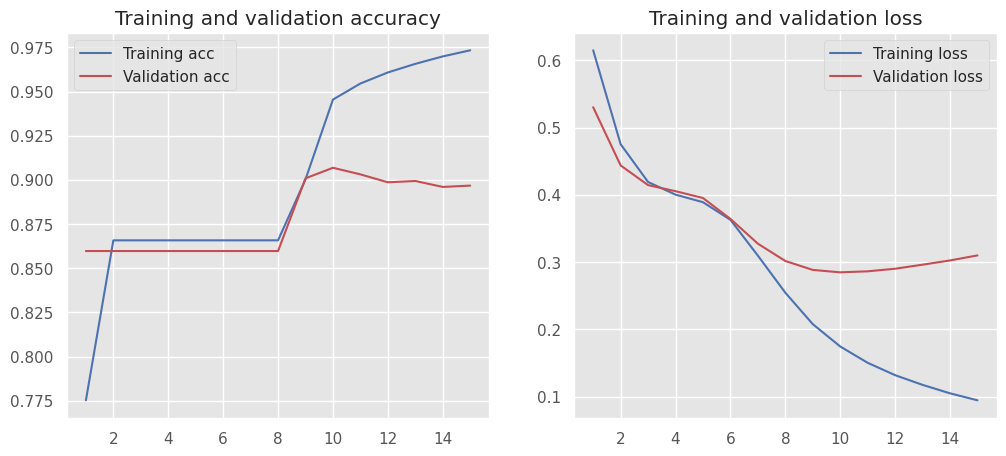

In [94]:
criterion = nn.BCELoss()
history = train_pytorch_model(
  model,
  train_text_tfidf_features,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
  criterion=criterion)
plot_history(history)

Classification Report
              precision    recall  f1-score   support

No offensive       0.93      0.96      0.94      2889
   Offensive       0.65      0.52      0.58       453

    accuracy                           0.90      3342
   macro avg       0.79      0.74      0.76      3342
weighted avg       0.89      0.90      0.89      3342

Confusion matrix, without normalization


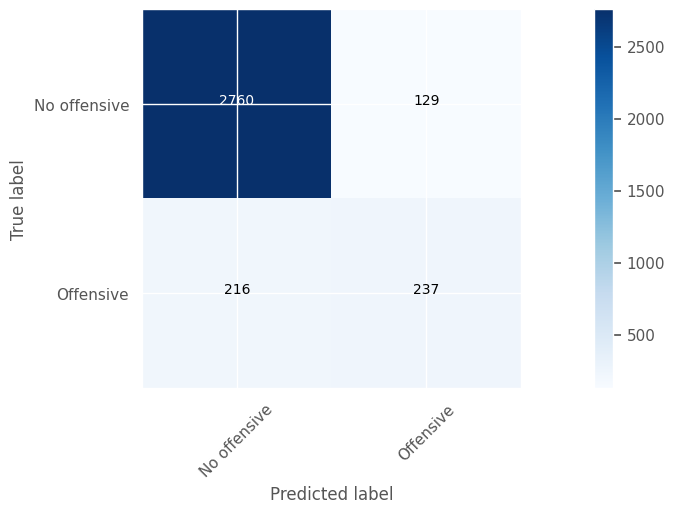

F1 Macro: 0.7600


In [95]:
y_pred = evaluate_pytorch_model(model, test_text_tfidf_features, Y_test, le, target_labels, device)

### MLP con class-weighted loss (BCEWithLogitsLoss)

Como el dataset no está balanceado, es decir, hay muchas más muestras de una clase que de otra, quiero explorar alguna
técnica que ayude con este problema. En el siguiente experimento vamos a usar la función de pérdidas **BCEWithLogitsLoss**
la cual permite añadir un peso a cada clase. Este peso será proporcional al número de muestras de cada clase en el dataset
de entrenamiento. La idea es penalizar más en el coste errores cometidos en la clase minoritaria.

Está función de pérdidas tiene una sigmoide, entonces, tener una sigmoide en la salida del modelo es redundante. Por eso
implemento otro modelo cuya salida son directamente los logits de la última capa fully connected.

In [96]:
class BinaryClassifierMLPLogits(nn.Module):
    def __init__(self, input_dim):
        super(BinaryClassifierMLPLogits, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)

    def forward(self, x):
        x = F.softmax(self.fc1(x), dim=1)
        x = F.softmax(self.fc2(x), dim=1)
        return self.fc3(x)

# pos_weight = número muestras negativas / número muestras positivas
n_neg = (Y_train == 0).sum()
n_pos = (Y_train == 1).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
print(f"Clase 0 (No offensive): {n_neg} | Clase 1 (Offensive): {n_pos} | pos_weight: {pos_weight.item():.2f}")

input_dim = train_text_tfidf_features.shape[1]
model_weighted = BinaryClassifierMLPLogits(input_dim).to(device)
print_model_info(model_weighted)

Clase 0 (No offensive): 11558 | Clase 1 (Offensive): 1810 | pos_weight: 6.39
MODEL ARCHITECTURE
BinaryClassifierMLPLogits(
  (fc1): Linear(in_features=22969, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
fc1.weight                               2,940,032       [128, 22969]        
fc1.bias                                 128             [128]               
fc2.weight                               8,192           [64, 128]           
fc2.bias                                 64              [64]                
fc3.weight                               64              [1, 64]             
fc3.bias                                 1               [1]                 
----------------------------------------------

Epoch 1/40 - loss: 1.1931 - acc: 0.8658 - val_loss: 1.2177 - val_acc: 0.8598
Epoch 2/40 - loss: 1.1974 - acc: 0.8658 - val_loss: 1.2173 - val_acc: 0.8598
Epoch 3/40 - loss: 1.1900 - acc: 0.8658 - val_loss: 1.2112 - val_acc: 0.8598
Epoch 4/40 - loss: 1.1627 - acc: 0.8658 - val_loss: 1.1655 - val_acc: 0.8598
Epoch 5/40 - loss: 1.0525 - acc: 0.8658 - val_loss: 1.0588 - val_acc: 0.8639
Epoch 6/40 - loss: 0.8786 - acc: 0.9126 - val_loss: 0.9606 - val_acc: 0.9024
Epoch 7/40 - loss: 0.7173 - acc: 0.9383 - val_loss: 0.9026 - val_acc: 0.8919
Epoch 8/40 - loss: 0.5847 - acc: 0.9411 - val_loss: 0.8843 - val_acc: 0.8904
 (patience: 1/5)
Epoch 9/40 - loss: 0.4764 - acc: 0.9444 - val_loss: 0.8881 - val_acc: 0.8852
 (patience: 2/5)
Epoch 10/40 - loss: 0.3882 - acc: 0.9517 - val_loss: 0.9092 - val_acc: 0.8818
 (patience: 3/5)
Epoch 11/40 - loss: 0.3213 - acc: 0.9567 - val_loss: 0.9569 - val_acc: 0.8826
 (patience: 4/5)
Epoch 12/40 - loss: 0.2719 - acc: 0.9611 - val_loss: 1.0210 - val_acc: 0.8852
 (pat

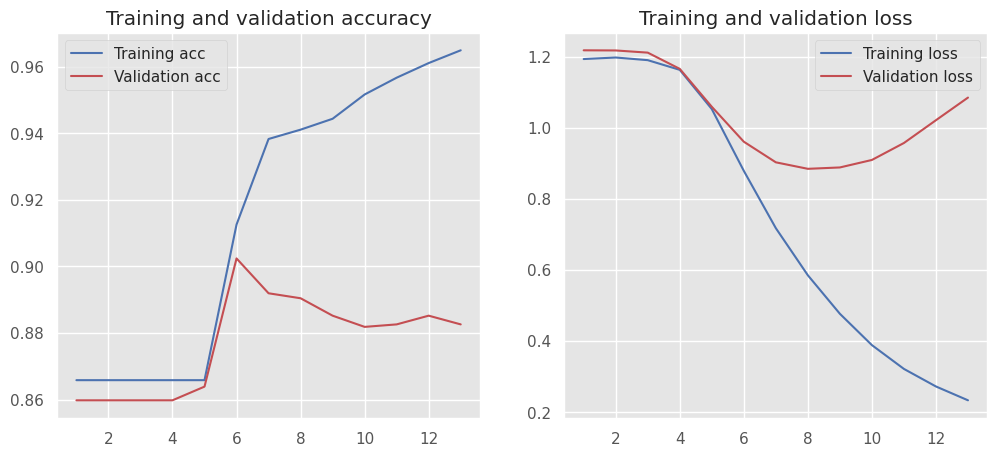

In [97]:
criterion_weighted = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
history_weighted = train_pytorch_model(
    model_weighted,
    train_text_tfidf_features,
    Y_train,
    epochs=40, batch_size=32, validation_split=0.2,
    optimizer=torch.optim.Adam(model_weighted.parameters(), lr=0.001),
    criterion=criterion_weighted,
    patience=5,
    device=device)
plot_history(history_weighted)

Classification Report
              precision    recall  f1-score   support

No offensive       0.93      0.93      0.93      2889
   Offensive       0.55      0.57      0.56       453

    accuracy                           0.88      3342
   macro avg       0.74      0.75      0.75      3342
weighted avg       0.88      0.88      0.88      3342

Confusion matrix, without normalization


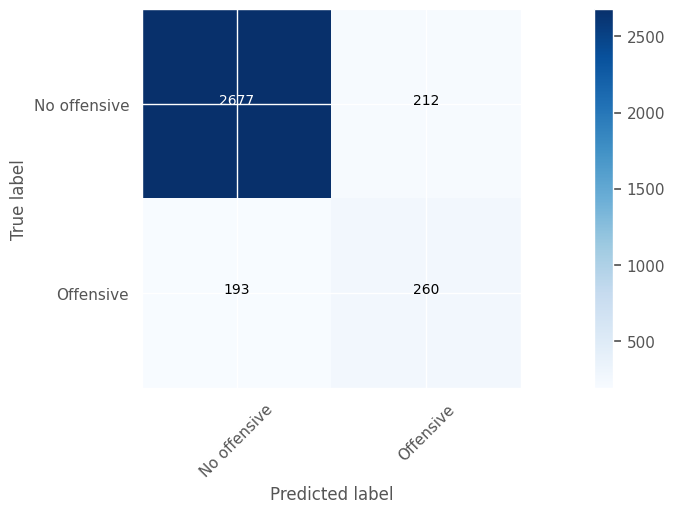

F1 Macro: 0.7459


In [98]:
y_pred_weighted = evaluate_pytorch_model(model_weighted, test_text_tfidf_features, Y_test, le, target_labels, device)

A pesar de que f1 macro sea algo menor que en el experimento anterior, el recall en la clase minoritaria Offensive es
mayor ahora, 0.59 (ahora) 0.52 (antes).

### MLP con Focal Loss

A continuación, quiero emplear otra técnica utilizada en datasets desbalanceados. En este caso voy a experimentar
con **focal loss**. Esta función de pérdidas fue propuesta para algoritmos de detección de objetos y la idea es modificar
la entropía cruzada para que el modelo preste menos atención a los ejemplos fáciles y se centre en los difíciles.

In [99]:
class FocalLoss(nn.Module):
    expects_float_targets = True

    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        p = torch.sigmoid(inputs)
        # probabilidad de la clase correcta para cada muestra
        p_t = p * targets + (1 - p) * (1 - targets)
        # alpha para positivos, (1-alpha) para negativos
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_weight = alpha_t * (1 - p_t) ** self.gamma
        return (focal_weight * bce).mean()

# alpha = proporción de muestras negativas (peso relativo de la clase positiva)
alpha = n_neg / (n_neg + n_pos)
print(f"alpha={alpha:.3f}  gamma=2.0")

input_dim = train_text_tfidf_features.shape[1]
model_focal = BinaryClassifierMLPLogits(input_dim).to(device)
print_model_info(model_focal)

alpha=0.865  gamma=2.0
MODEL ARCHITECTURE
BinaryClassifierMLPLogits(
  (fc1): Linear(in_features=22969, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
fc1.weight                               2,940,032       [128, 22969]        
fc1.bias                                 128             [128]               
fc2.weight                               8,192           [64, 128]           
fc2.bias                                 64              [64]                
fc3.weight                               64              [1, 64]             
fc3.bias                                 1               [1]                 
--------------------------------------------------------------------------------
Total Parameters:  

Epoch 1/40 - loss: 0.0406 - acc: 0.8658 - val_loss: 0.0412 - val_acc: 0.8598
 (patience: 1/5)
Epoch 2/40 - loss: 0.0404 - acc: 0.8658 - val_loss: 0.0412 - val_acc: 0.8598
Epoch 3/40 - loss: 0.0405 - acc: 0.8658 - val_loss: 0.0412 - val_acc: 0.8598
Epoch 4/40 - loss: 0.0404 - acc: 0.8658 - val_loss: 0.0410 - val_acc: 0.8598
Epoch 5/40 - loss: 0.0396 - acc: 0.8658 - val_loss: 0.0396 - val_acc: 0.8598
Epoch 6/40 - loss: 0.0354 - acc: 0.8658 - val_loss: 0.0344 - val_acc: 0.8598
Epoch 7/40 - loss: 0.0270 - acc: 0.8754 - val_loss: 0.0307 - val_acc: 0.8904
Epoch 8/40 - loss: 0.0204 - acc: 0.9246 - val_loss: 0.0299 - val_acc: 0.9069
 (patience: 1/5)
Epoch 9/40 - loss: 0.0162 - acc: 0.9444 - val_loss: 0.0318 - val_acc: 0.9065
 (patience: 2/5)
Epoch 10/40 - loss: 0.0133 - acc: 0.9532 - val_loss: 0.0333 - val_acc: 0.8953
 (patience: 3/5)
Epoch 11/40 - loss: 0.0112 - acc: 0.9583 - val_loss: 0.0374 - val_acc: 0.9005
 (patience: 4/5)
Epoch 12/40 - loss: 0.0096 - acc: 0.9634 - val_loss: 0.0401 - val_

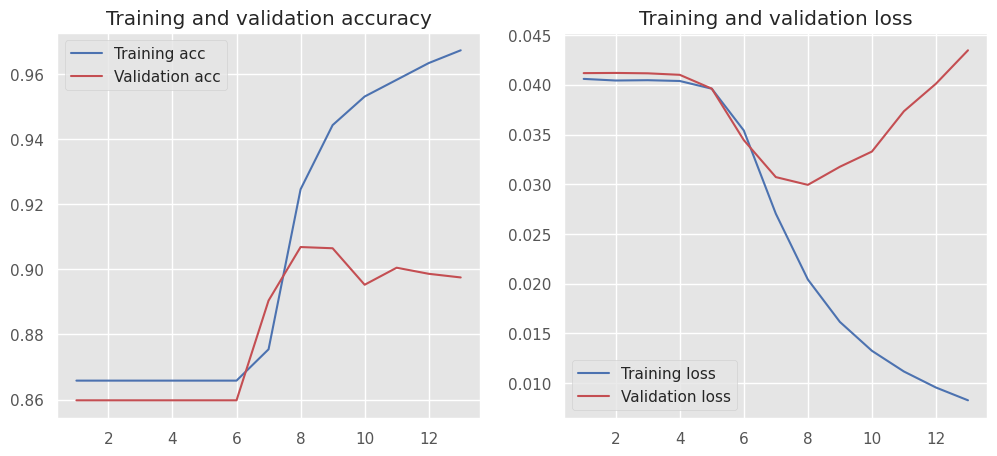

In [100]:
criterion_focal = FocalLoss(alpha=float(alpha), gamma=2.0)
history_focal = train_pytorch_model(
    model_focal,
    train_text_tfidf_features,
    Y_train,
    epochs=40, batch_size=32, validation_split=0.2,
    optimizer=torch.optim.Adam(model_focal.parameters(), lr=0.001),
    criterion=criterion_focal,
    patience=5,
    device=device)
plot_history(history_focal)

Classification Report
              precision    recall  f1-score   support

No offensive       0.93      0.95      0.94      2889
   Offensive       0.65      0.54      0.59       453

    accuracy                           0.90      3342
   macro avg       0.79      0.75      0.77      3342
weighted avg       0.89      0.90      0.89      3342

Confusion matrix, without normalization


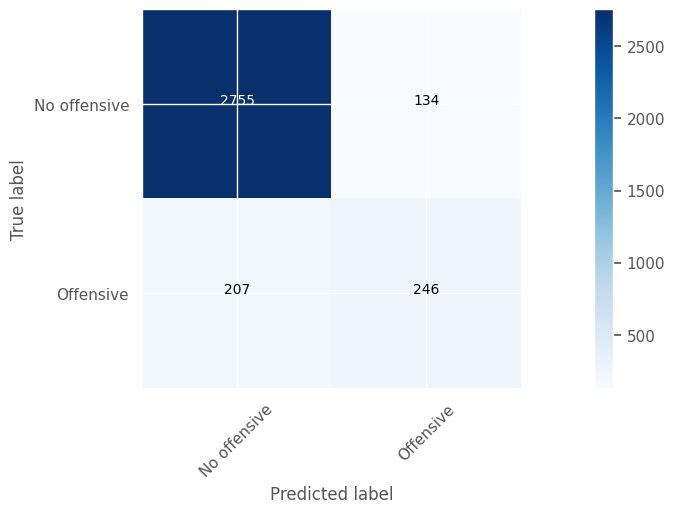

F1 Macro: 0.7662


In [101]:
y_pred_focal = evaluate_pytorch_model(model_focal, test_text_tfidf_features, Y_test, le, target_labels, device)

El f1-macro es algo mayor que en los experimentos anteriores. A continuación vamos a continuar usando focal loss y entrenar con representación de bigramas y 4 clases.

### MLP Focal Loss Bigramas TF-IDF

In [ ]:
input_dim_bigram = train_text_bigram_tfidf_features.shape[1]
model_focal_bigram = BinaryClassifierMLPLogits(input_dim_bigram).to(device)
print_model_info(model_focal_bigram)

MODEL ARCHITECTURE
BinaryClassifierMLPLogits(
  (fc1): Linear(in_features=145139, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
fc1.weight                               18,577,792      [128, 145139]       
fc1.bias                                 128             [128]               
fc2.weight                               8,192           [64, 128]           
fc2.bias                                 64              [64]                
fc3.weight                               64              [1, 64]             
fc3.bias                                 1               [1]                 
--------------------------------------------------------------------------------
Total Parameters:                        

Epoch 1/40 - loss: 0.0405 - acc: 0.8658 - val_loss: 0.0412 - val_acc: 0.8598
Epoch 2/40 - loss: 0.0404 - acc: 0.8658 - val_loss: 0.0412 - val_acc: 0.8598
 (patience: 1/5)
Epoch 3/40 - loss: 0.0404 - acc: 0.8658 - val_loss: 0.0412 - val_acc: 0.8598
Epoch 4/40 - loss: 0.0404 - acc: 0.8658 - val_loss: 0.0412 - val_acc: 0.8598
Epoch 5/40 - loss: 0.0404 - acc: 0.8658 - val_loss: 0.0411 - val_acc: 0.8598
Epoch 6/40 - loss: 0.0402 - acc: 0.8658 - val_loss: 0.0408 - val_acc: 0.8598
Epoch 7/40 - loss: 0.0383 - acc: 0.8658 - val_loss: 0.0380 - val_acc: 0.8598
Epoch 8/40 - loss: 0.0287 - acc: 0.8673 - val_loss: 0.0321 - val_acc: 0.8672
Epoch 9/40 - loss: 0.0163 - acc: 0.9374 - val_loss: 0.0311 - val_acc: 0.8998
 (patience: 1/5)
Epoch 10/40 - loss: 0.0090 - acc: 0.9811 - val_loss: 0.0344 - val_acc: 0.9061
 (patience: 2/5)
Epoch 11/40 - loss: 0.0053 - acc: 0.9893 - val_loss: 0.0395 - val_acc: 0.9046
 (patience: 3/5)
Epoch 12/40 - loss: 0.0035 - acc: 0.9922 - val_loss: 0.0466 - val_acc: 0.9046
 (pat

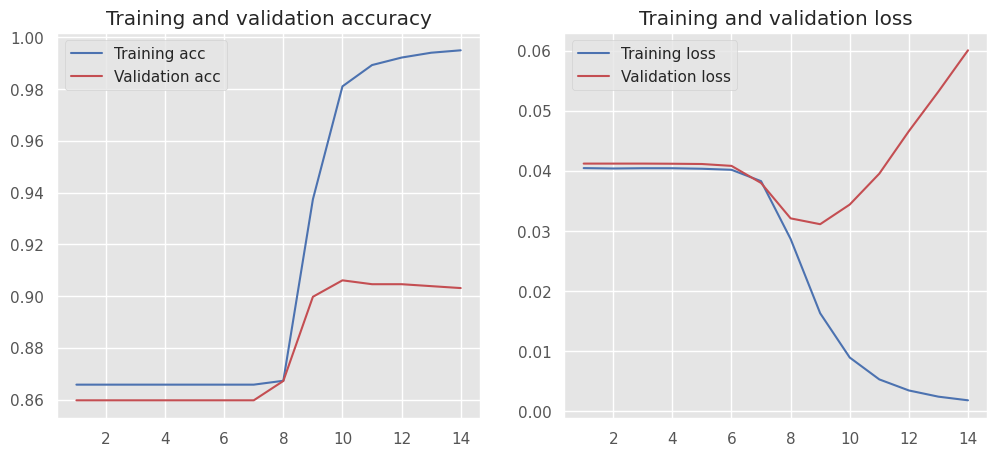

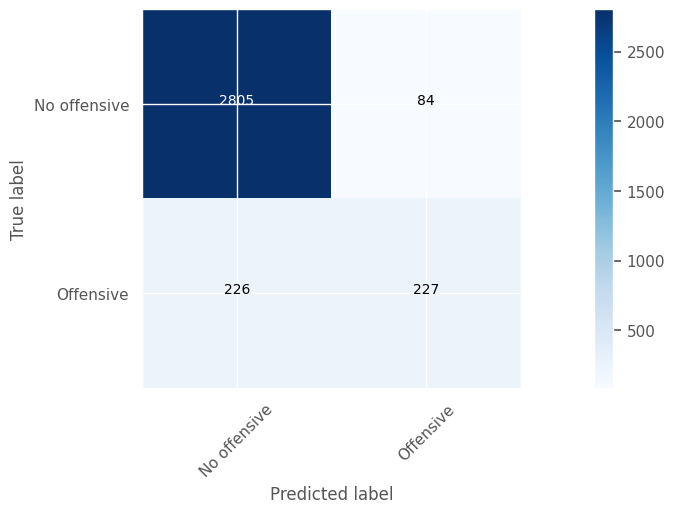

F1 Macro: 0.7709


array(['No offensive', 'No offensive', 'No offensive', ...,
       'No offensive', 'No offensive', 'No offensive'],
      shape=(3342,), dtype=object)

In [105]:
history_focal_bigram = train_pytorch_model(
    model_focal_bigram,
    train_text_bigram_tfidf_features,
    Y_train,
    epochs=40, batch_size=32, validation_split=0.2,
    optimizer=torch.optim.Adam(model_focal_bigram.parameters(), lr=0.001),
    criterion=FocalLoss(alpha=float(alpha), gamma=2.0),
    patience=5,
    device=device,
)
plot_history(history_focal_bigram)

evaluate_pytorch_model(model_focal_bigram, test_text_bigram_tfidf_features, Y_test, le, target_labels, device)

Se consigue el mejor f1-macro hasta ahora utilizando un MLP.

## Word Embeddings

En los entrenamientos anteriores hemos empleado representaciones vectoriales basadas en pesado TF, TF-IDF. Ahora vamos a 
emplear representaciones basadas en Word Embeddings. Estas representaciones son más ideales para algoritmos que procesen
secuencias como por ejemplo redes convolucionales 1D o redes recurrentes.

In [42]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

def evaluate_all(y_true, y_pred, target_labels):
    print("Classification Report")
    print(classification_report(y_true, y_pred, target_names=target_labels))
    cm = confusion_matrix(y_true, y_pred, labels=target_labels)
    plot_confusion_matrix(cm, classes=target_labels)
    f1 = f1_score(y_true, y_pred, average='macro')
    print("F1 Macro: %.4f" % f1)
    return f1

# Ground-truth string labels for the test set (used by all experiments below)
y_test_labels = le.inverse_transform(Y_test)

Selecciono una longitud de secuencia máxima de 200. Si tenemos una secuencia de entrada mayor que 200,
la secuencia se truncará. Si la secuencia es menor que 200, se añadirán tokens de padding.
De esta manera podemos hacer un procesado en batches.

In [110]:
word_counts = {}
for text in X_train['clean_comment']:
    for word in text.split():
        word_counts[word] = word_counts.get(word, 0) + 1

sorted_words = sorted(word_counts.items(), key=lambda x: -x[1])
word_index   = {word: idx + 2 for idx, (word, _) in enumerate(sorted_words)}
word_index['<OOV>'] = 1
vocab_size = len(word_index) + 1

def texts_to_sequences(texts, wi):
    return [[wi.get(w, 1) for w in t.split()] for t in texts]

MAX_SEQ_LEN = 200

def pad_sequences_torch(sequences, maxlen, padding_value=0):
    result = np.full((len(sequences), maxlen), padding_value, dtype=np.int64)
    for i, seq in enumerate(sequences):
        trunc = seq[:maxlen]
        result[i, :len(trunc)] = trunc
    return torch.tensor(result, dtype=torch.long)

train_padded = pad_sequences_torch(texts_to_sequences(X_train['clean_comment'], word_index), MAX_SEQ_LEN)
test_padded  = pad_sequences_torch(texts_to_sequences(X_test['clean_comment'],  word_index), MAX_SEQ_LEN)

print(f"Vocab size : {vocab_size}")
print(f"Train shape: {train_padded.shape}")
print(f"Test shape : {test_padded.shape}")

Vocab size : 22997
Train shape: torch.Size([13368, 200])
Test shape : torch.Size([3342, 200])


Este modelo tiene una capa de embeddings de entrada. Después la secuencia en espacio de embeddings se procesa
con MLP's.

In [111]:
class SimpleEmbeddingNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=50, hidden_dim=32):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.fc1 = nn.Linear(embedding_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x, verbose=False):
        embedded = self.embedding(x)

        if verbose:
            print(f"Embedded shape: {embedded.shape}")

        pooled = torch.mean(embedded, dim=1)

        if verbose:
            print(f"Pooled shape: {pooled.shape}")

        hidden = F.relu(self.fc1(pooled))
        output_logits = self.fc2(hidden)

        if verbose:
            print(f"Output logits shape: {output_logits.shape}")

        return output_logits

MODEL ARCHITECTURE
SimpleEmbeddingNN(
  (embedding): Embedding(22997, 80, padding_idx=0)
  (fc1): Linear(in_features=80, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embedding.weight                         1,839,760       [22997, 80]         
fc1.weight                               10,240          [128, 80]           
fc1.bias                                 128             [128]               
fc2.weight                               128             [1, 128]            
fc2.bias                                 1               [1]                 
--------------------------------------------------------------------------------
Total Parameters:                        1,850,257
Trainable Parameters:                    1,850,257
Non-trainable Parameters:             

Epoch 1/20 - loss: 1.1949 - acc: 0.8658 - val_loss: 1.2078 - val_acc: 0.8601
Epoch 2/20 - loss: 1.1670 - acc: 0.8656 - val_loss: 1.1646 - val_acc: 0.8601
Epoch 3/20 - loss: 1.0808 - acc: 0.8617 - val_loss: 1.0908 - val_acc: 0.8613
Epoch 4/20 - loss: 0.9615 - acc: 0.8614 - val_loss: 1.0084 - val_acc: 0.8306
Epoch 5/20 - loss: 0.8357 - acc: 0.8631 - val_loss: 0.9820 - val_acc: 0.8706
Epoch 6/20 - loss: 0.7078 - acc: 0.8764 - val_loss: 0.9434 - val_acc: 0.8594
 (patience: 1/5)
Epoch 7/20 - loss: 0.6025 - acc: 0.8942 - val_loss: 0.9596 - val_acc: 0.8545
 (patience: 2/5)
Epoch 8/20 - loss: 0.5156 - acc: 0.9060 - val_loss: 1.0099 - val_acc: 0.8628
 (patience: 3/5)
Epoch 9/20 - loss: 0.4424 - acc: 0.9216 - val_loss: 1.0438 - val_acc: 0.8598
 (patience: 4/5)
Epoch 10/20 - loss: 0.3807 - acc: 0.9326 - val_loss: 1.1471 - val_acc: 0.8755
 (patience: 5/5)
Early stopping triggered at epoch 11
Classification Report
              precision    recall  f1-score   support

No offensive       0.95      0

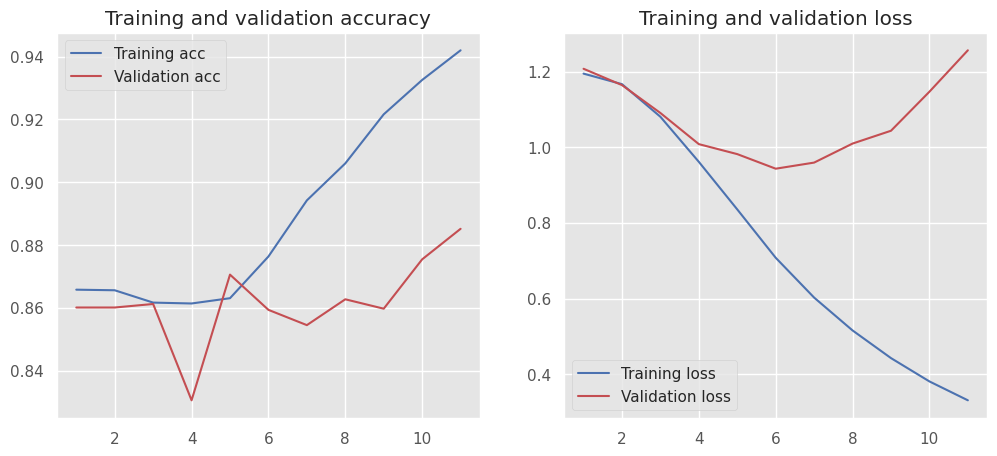

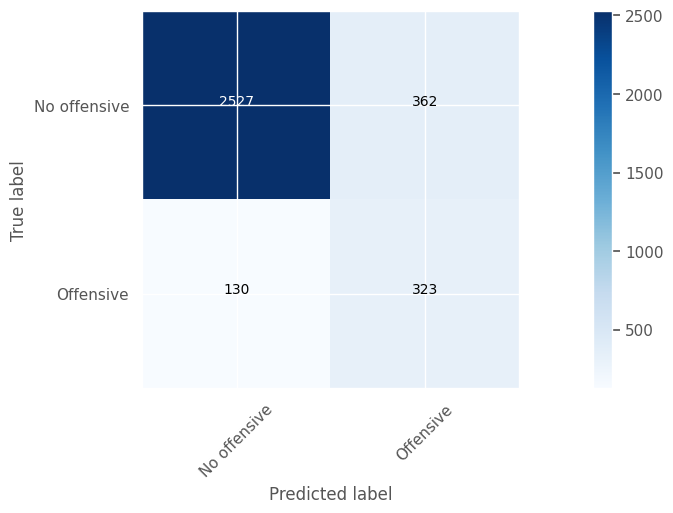

F1 Macro: 0.7395


0.7394749901288917

In [119]:
simple_model = SimpleEmbeddingNN(vocab_size=vocab_size, embedding_dim=80, hidden_dim=128).to(device)
print_model_info(simple_model)

n_neg_we = (Y_train == 0).sum()
n_pos_we = (Y_train == 1).sum()
pos_weight_we = torch.tensor([n_neg_we / n_pos_we], dtype=torch.float32).to(device)

simple_history = train_pytorch_model(
    simple_model, train_padded, Y_train,
    epochs=20, batch_size=64, validation_split=0.2,
    optimizer=torch.optim.Adam(simple_model.parameters(), lr=0.001, weight_decay=1e-4),
    criterion=nn.BCEWithLogitsLoss(pos_weight=pos_weight_we),
    device=device, patience=5,
)
plot_history(simple_history)

simple_model.eval()
with torch.no_grad():
    logits = simple_model(test_padded.to(device)).squeeze(1)
    simple_preds_enc = (logits > 0).long().cpu().numpy()

simple_preds_labels = le.inverse_transform(simple_preds_enc)
evaluate_all(y_test_labels, simple_preds_labels, target_labels)

## CNN 1D
Las CNN 1D son capaces de encontrar patrones locales en secuencias 1D. La información debe estar ordenada, por este motivo, las representaciones TF y TF-IDF no son adecuadas para ser procesadas por una convolución 1D. Utilizaremos en este caso
una representación de word embeddings que sí tiene en cuenta el orden de la secuencia.

A continuación vamos a utilizar una arquitectura que dio mejores resultados en la práctica de CNNs, esta consistia en un procesado en paralelo con distintos tamaños de kernel. TextCNN (Kim 2014). También usamos la técnica de **max pooling**.

MODEL ARCHITECTURE
TextCNN(
  (embedding): Embedding(22997, 100, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(100, 128, kernel_size=(2,), stride=(1,))
    (1): Conv1d(100, 128, kernel_size=(3,), stride=(1,))
    (2): Conv1d(100, 128, kernel_size=(4,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=384, out_features=2, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embedding.weight                         2,299,700       [22997, 100]        
convs.0.weight                           25,600          [128, 100, 2]       
convs.0.bias                             128             [128]               
convs.1.weight                           38,400          [128, 100, 3]       
convs.1.bias                             128             [128]               
convs.2.weight                           51,200    

Epoch 1/20 - loss: 0.3776 - acc: 0.8636 - val_loss: 0.3317 - val_acc: 0.8732
 (patience: 1/5)
Epoch 2/20 - loss: 0.2829 - acc: 0.8904 - val_loss: 0.3475 - val_acc: 0.8800
Epoch 3/20 - loss: 0.2274 - acc: 0.9114 - val_loss: 0.3165 - val_acc: 0.8904
 (patience: 1/5)
Epoch 4/20 - loss: 0.1688 - acc: 0.9323 - val_loss: 0.3388 - val_acc: 0.8919
 (patience: 2/5)
Epoch 5/20 - loss: 0.1346 - acc: 0.9461 - val_loss: 0.3425 - val_acc: 0.8934
 (patience: 3/5)
Epoch 6/20 - loss: 0.1017 - acc: 0.9600 - val_loss: 0.3967 - val_acc: 0.8930
 (patience: 4/5)
Epoch 7/20 - loss: 0.0845 - acc: 0.9687 - val_loss: 0.4233 - val_acc: 0.8934
 (patience: 5/5)
Early stopping triggered at epoch 8
Classification Report
              precision    recall  f1-score   support

No offensive       0.91      0.98      0.94      2889
   Offensive       0.74      0.39      0.51       453

    accuracy                           0.90      3342
   macro avg       0.83      0.68      0.73      3342
weighted avg       0.89      

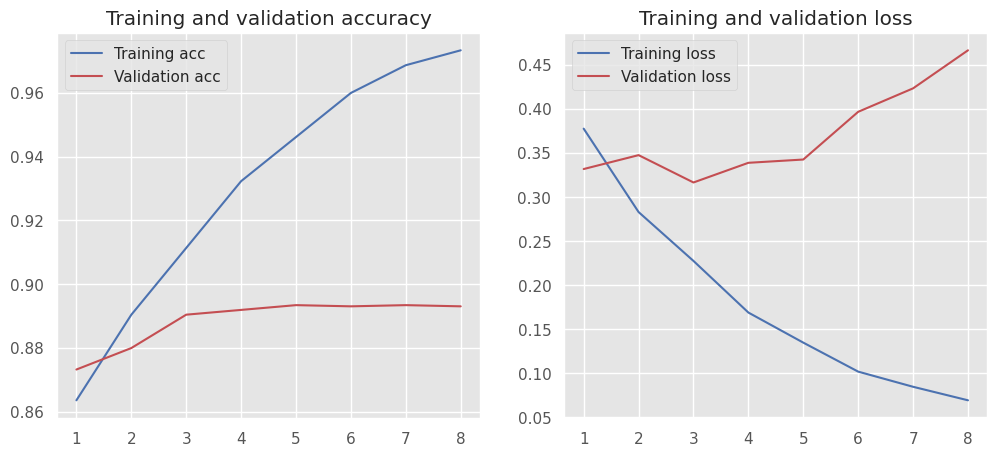

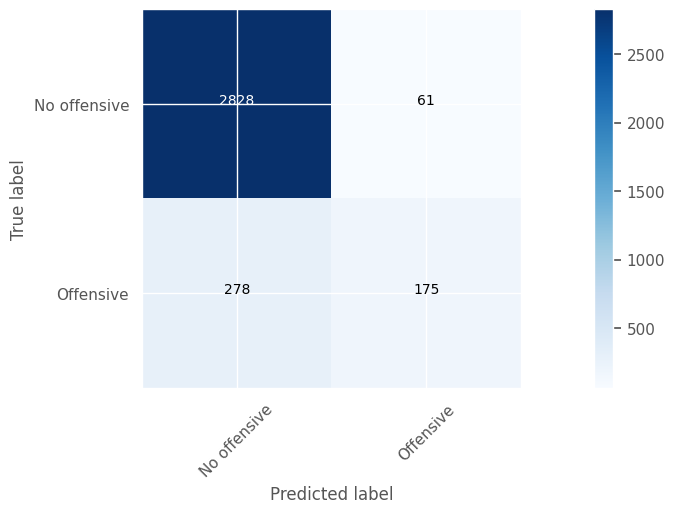

F1 Macro: 0.7257


0.7257177304260566

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class TextCNN(nn.Module):
    def __init__(self, vocab_size, emb_dim, num_filters, kernel_sizes, num_classes, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(emb_dim, num_filters, k) for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        pooled = [F.relu(conv(x)).max(dim=2).values for conv in self.convs]
        return self.fc(self.dropout(torch.cat(pooled, dim=1)))

cnn_model = TextCNN(
    vocab_size=vocab_size, emb_dim=100, num_filters=128,
    kernel_sizes=[2, 3, 4], num_classes=2, dropout=0.5
).to(device)
print_model_info(cnn_model)

cnn_history = train_pytorch_model(
    cnn_model, train_padded, Y_train,
    epochs=20, batch_size=64, validation_split=0.2,
    optimizer=torch.optim.Adam(cnn_model.parameters(), lr=0.001),
    criterion=nn.CrossEntropyLoss(), device=device, patience=5,
)
plot_history(cnn_history)

cnn_model.eval()
with torch.no_grad():
    cnn_preds_enc = torch.argmax(cnn_model(test_padded.to(device)), dim=1).cpu().numpy()

cnn_preds_labels = le.inverse_transform(cnn_preds_enc)
evaluate_all(y_test_labels, cnn_preds_labels, target_labels)

## Redes recurrentes
Vamos a utilizar una red recurrente LSTM bidireccional porque tenemos acceso a toda la secuencia.

MODEL ARCHITECTURE
EmbeddingLSTMClassifier(
  (embedding): Embedding(22997, 300, padding_idx=0)
  (lstm): LSTM(300, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=2, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embedding.weight                         6,899,100       [22997, 300]        
lstm.weight_ih_l0                        307,200         [1024, 300]         
lstm.weight_hh_l0                        262,144         [1024, 256]         
lstm.bias_ih_l0                          1,024           [1024]              
lstm.bias_hh_l0                          1,024           [1024]              
lstm.weight_ih_l0_reverse                307,200         [1024, 300]         
lstm.weight_hh_l0_reverse                262,144         [1024, 2

Epoch 1/20 - loss: 0.3556 - acc: 0.8673 - val_loss: 0.3146 - val_acc: 0.8859
Epoch 2/20 - loss: 0.2673 - acc: 0.8929 - val_loss: 0.3001 - val_acc: 0.8923
Epoch 3/20 - loss: 0.2109 - acc: 0.9162 - val_loss: 0.2967 - val_acc: 0.8945
 (patience: 1/5)
Epoch 4/20 - loss: 0.1623 - acc: 0.9380 - val_loss: 0.3298 - val_acc: 0.8874
 (patience: 2/5)
Epoch 5/20 - loss: 0.1148 - acc: 0.9536 - val_loss: 0.4331 - val_acc: 0.8904
 (patience: 3/5)
Epoch 6/20 - loss: 0.0835 - acc: 0.9687 - val_loss: 0.4489 - val_acc: 0.8807
 (patience: 4/5)
Epoch 7/20 - loss: 0.0661 - acc: 0.9751 - val_loss: 0.4884 - val_acc: 0.8822
 (patience: 5/5)
Early stopping triggered at epoch 8
Classification Report
              precision    recall  f1-score   support

No offensive       0.93      0.95      0.94      2889
   Offensive       0.61      0.51      0.56       453

    accuracy                           0.89      3342
   macro avg       0.77      0.73      0.75      3342
weighted avg       0.88      0.89      0.89   

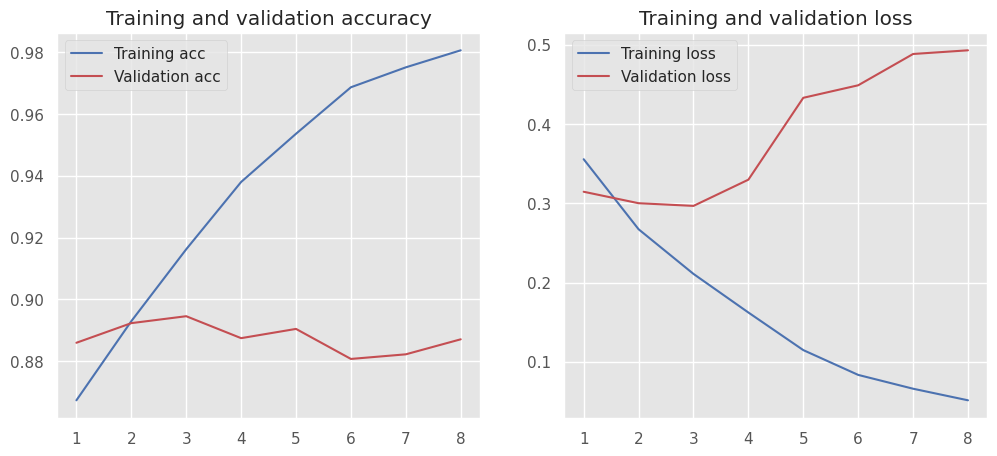

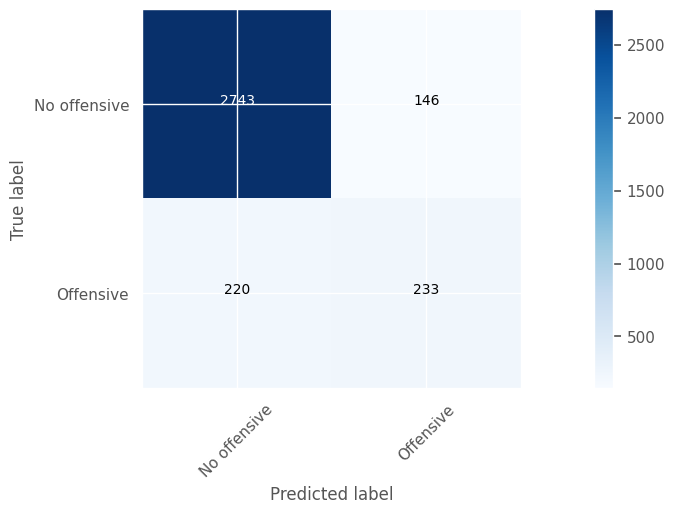

F1 Macro: 0.7488


0.7487767167043483

In [125]:
class EmbeddingLSTMClassifier(nn.Module):

    def __init__(self, vocab_size, emb_dim, lstm_hidden, num_classes,
                 lstm_layers=2, bidirectional=True, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            emb_dim, lstm_hidden, lstm_layers,
            batch_first=True, bidirectional=bidirectional,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )
        lstm_out_dim = lstm_hidden * (2 if bidirectional else 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_out_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        x = out.max(dim=1).values
        return self.fc(self.dropout(x))


lstm_model = EmbeddingLSTMClassifier(
    vocab_size=vocab_size, emb_dim=300, lstm_hidden=256,
    num_classes=2, lstm_layers=2, bidirectional=True, dropout=0.5
).to(device)
print_model_info(lstm_model)

lstm_history = train_pytorch_model(
    lstm_model, train_padded, Y_train,
    epochs=20, batch_size=64, validation_split=0.2,
    optimizer=torch.optim.Adam(lstm_model.parameters(), lr=0.0005, weight_decay=1e-4),
    criterion=nn.CrossEntropyLoss(), device=device, patience=5,
)
plot_history(lstm_history)

lstm_model.eval()
with torch.no_grad():
    lstm_preds_enc = torch.argmax(lstm_model(test_padded.to(device)), dim=1).cpu().numpy()

lstm_preds_labels = le.inverse_transform(lstm_preds_enc)
evaluate_all(y_test_labels, lstm_preds_labels, target_labels)

## Modelos contextuales
Son modelos que no generan texto, pero se pueden usar para una tarea de clasificación binaria. Como BERT.

### Fine tuning

### dccuchile/bert-base-spanish-wwm-cased 2 clases

In [38]:
from datasets import Dataset, DatasetDict, ClassLabel
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    EarlyStoppingCallback,
)

BERT_CHECKPOINT = "dccuchile/bert-base-spanish-wwm-cased"

# Use original (unlemmatised) comments — BERT tokeniser handles Spanish natively
bert_train_texts  = dataset.iloc[:len(training_set)]['comment'].tolist()
bert_test_texts   = dataset.iloc[len(training_set):]['comment'].tolist()
bert_train_labels = encoded_y_train.tolist()
bert_test_labels  = Y_test.tolist()

train_ds_bert = Dataset.from_pandas(pd.DataFrame({"text": bert_train_texts, "label": bert_train_labels}))
test_ds_bert  = Dataset.from_pandas(pd.DataFrame({"text": bert_test_texts,  "label": bert_test_labels}))

class_label_bert = ClassLabel(names=list(target_labels))
train_ds_bert = train_ds_bert.cast_column("label", class_label_bert)
test_ds_bert  = test_ds_bert.cast_column("label", class_label_bert)

split_bert   = train_ds_bert.train_test_split(test_size=0.2, seed=42)
ds_dict_bert = DatasetDict({"train": split_bert["train"], "validation": split_bert["test"], "test": test_ds_bert})

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_CHECKPOINT)
BERT_MAX_LEN   = 128

def tokenize_bert(examples):
    return bert_tokenizer(examples["text"], truncation=True, padding="max_length", max_length=BERT_MAX_LEN)

tokenized_bert = ds_dict_bert.map(tokenize_bert, batched=True)

id2label_bert = {i: l for i, l in enumerate(target_labels)}
label2id_bert = {l: i for i, l in enumerate(target_labels)}

bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_CHECKPOINT, num_labels=2, id2label=id2label_bert, label2id=label2id_bert
)

def compute_metrics_bert(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"f1_macro": f1_score(labels, preds, average='macro')}

bert_args = TrainingArguments(
    output_dir="./bert_offendes",
    eval_strategy="epoch", save_strategy="epoch",
    learning_rate=2e-5, per_device_train_batch_size=32, per_device_eval_batch_size=32,
    num_train_epochs=3, weight_decay=0.01,
    load_best_model_at_end=True, metric_for_best_model="f1_macro", greater_is_better=True,
    fp16=torch.cuda.is_available(), report_to="none", seed=42, logging_steps=100,
)


Casting the dataset: 100%|██████████| 3342/3342 [00:00<00:00, 2300946.15 examples/s]


Map: 100%|██████████| 3342/3342 [00:00<00:00, 21787.20 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


2026-06-07 12:48:37.000682: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.



Casting the dataset:   0%|                               | 0/13368 [00:00<?, ? examples/s]


Casting the dataset: 100%|██████████████| 13368/13368 [00:00<00:00, 1272599.38 examples/s]


Casting the dataset:   0%|                                | 0/3342 [00:00<?, ? examples/s]


Casting the dataset: 100%|████████████████| 3342/3342 [00:00<00:00, 1956093.21 examples/s]

...


Map: 100%|██████████████████████████████████| 3342/3342 [00:00<00:00, 23515.28 examples/s]


Map: 100%|██████████████████████████████████| 3342/3342 [00:00<00:00, 23229.75 examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1 Macro
1,0.235400,0.197274,0.825218
2,0.135400,0.224616,0.824598
3,0.082000,0.294596,0.826567


Classification Report
              precision    recall  f1-score   support

No offensive       0.95      0.96      0.96      2889
   Offensive       0.72      0.70      0.71       453

    accuracy                           0.92      3342
   macro avg       0.84      0.83      0.83      3342
weighted avg       0.92      0.92      0.92      3342

Confusion matrix, without normalization


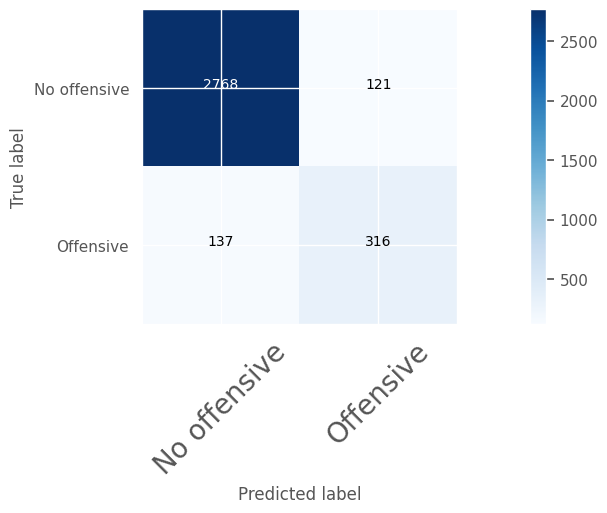

F1 Macro: 0.8328


0.8327917683151498

In [ ]:
bert_args = TrainingArguments(
    output_dir="./bert_offendes",
    eval_strategy="epoch", save_strategy="epoch",
    learning_rate=2e-5, per_device_train_batch_size=32, per_device_eval_batch_size=32,
    num_train_epochs=3, weight_decay=0.01,
    load_best_model_at_end=True, metric_for_best_model="f1_macro", greater_is_better=True,
    fp16=torch.cuda.is_available(), report_to="none", seed=42, logging_steps=100,
)

bert_trainer = Trainer(
    model=bert_model, args=bert_args,
    train_dataset=tokenized_bert["train"], eval_dataset=tokenized_bert["validation"],
    compute_metrics=compute_metrics_bert,
    data_collator=DataCollatorWithPadding(bert_tokenizer),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)
bert_trainer.train()

# ── Predictions & evaluation ──────────────────────────────────────────────────
bert_preds_output = bert_trainer.predict(tokenized_bert["test"])
bert_preds_enc    = np.argmax(bert_preds_output.predictions, axis=1)
bert_preds_labels = le.inverse_transform(bert_preds_enc)
evaluate_all(y_test_labels, bert_preds_labels, target_labels)

### dccuchile/bert-base-spanish-wwm-cased 4 clases

Map:   0%|          | 0/10694 [00:00<?, ? examples/s]

Map: 100%|██████████| 3342/3342 [00:00<00:00, 20867.46 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1 Macro
1,0.370200,0.318610,0.577682
2,0.242400,0.304766,0.741637
3,0.155000,0.354776,0.730305


Classification Report
              precision    recall  f1-score   support

          NO       0.94      0.95      0.95      2642
         NOM       0.69      0.70      0.70       247
         OFG       0.53      0.37      0.44        43
         OFP       0.73      0.72      0.73       410

    accuracy                           0.90      3342
   macro avg       0.73      0.69      0.70      3342
weighted avg       0.89      0.90      0.89      3342

Confusion matrix, without normalization


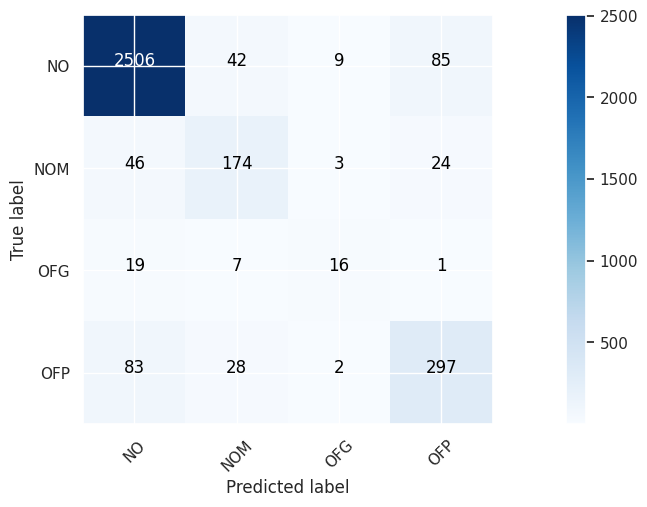

F1 Macro: 0.7026


0.70264403776537

In [43]:
# ── Fine-tuning del mismo modelo BERT para 4 clases (NO / NOM / OFG / OFP) ──
# Reutilizamos: bert_train_texts, bert_test_texts, bert_tokenizer,
#               BERT_MAX_LEN, tokenize_bert, compute_metrics_bert, BERT_CHECKPOINT

encoded_y_test_4c_bert = le_4c.transform(y_test_4c.label.values)

train_ds_bert_4c = Dataset.from_pandas(pd.DataFrame({
    "text":  bert_train_texts,
    "label": encoded_y_train_4c.tolist(),
}))
test_ds_bert_4c = Dataset.from_pandas(pd.DataFrame({
    "text":  bert_test_texts,
    "label": encoded_y_test_4c_bert.tolist(),
}))

class_label_4c = ClassLabel(names=list(target_labels_4c))
train_ds_bert_4c = train_ds_bert_4c.cast_column("label", class_label_4c)
test_ds_bert_4c  = test_ds_bert_4c.cast_column("label", class_label_4c)

split_bert_4c   = train_ds_bert_4c.train_test_split(test_size=0.2, seed=42)
ds_dict_bert_4c = DatasetDict({
    "train":      split_bert_4c["train"],
    "validation": split_bert_4c["test"],
    "test":       test_ds_bert_4c,
})

tokenized_bert_4c = ds_dict_bert_4c.map(tokenize_bert, batched=True)

id2label_4c = {i: l for i, l in enumerate(target_labels_4c)}
label2id_4c = {l: i for i, l in enumerate(target_labels_4c)}

bert_model_4c = AutoModelForSequenceClassification.from_pretrained(
    BERT_CHECKPOINT, num_labels=4, id2label=id2label_4c, label2id=label2id_4c
)

bert_args_4c = TrainingArguments(
    output_dir="./bert_offendes_4c",
    eval_strategy="epoch", save_strategy="epoch",
    learning_rate=2e-5, per_device_train_batch_size=32, per_device_eval_batch_size=32,
    num_train_epochs=3, weight_decay=0.01,
    load_best_model_at_end=True, metric_for_best_model="f1_macro", greater_is_better=True,
    fp16=torch.cuda.is_available(), report_to="none", seed=42, logging_steps=100,
)

bert_trainer_4c = Trainer(
    model=bert_model_4c, args=bert_args_4c,
    train_dataset=tokenized_bert_4c["train"], eval_dataset=tokenized_bert_4c["validation"],
    compute_metrics=compute_metrics_bert,
    data_collator=DataCollatorWithPadding(bert_tokenizer),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)
bert_trainer_4c.train()

# ── Predictions & evaluation ──────────────────────────────────────────────────
bert_preds_4c_output = bert_trainer_4c.predict(tokenized_bert_4c["test"])
bert_preds_4c_enc    = np.argmax(bert_preds_4c_output.predictions, axis=1)
bert_preds_4c_labels = le_4c.inverse_transform(bert_preds_4c_enc)
y_test_4c_labels     = le_4c.inverse_transform(encoded_y_test_4c_bert)
evaluate_all(y_test_4c_labels, bert_preds_4c_labels, list(target_labels_4c))

### Zero-shot
Usar algún checkpoint the hugging face de modelo entrenado para clasificar texto en ofensivo, no ofensivo.

Device set to use cuda:0



Zero-shot inference:   0%|                                        | 0/105 [00:00<?, ?it/s]


Zero-shot inference:   1%|▎                               | 1/105 [00:01<02:20,  1.35s/it]


Zero-shot inference:   2%|▌                               | 2/105 [00:02<01:41,  1.01it/s]


Zero-shot inference:   3%|▉                               | 3/105 [00:02<01:29,  1.14it/s]

...


Zero-shot inference:  98%|█████████████████████████████▍| 103/105 [01:17<00:01,  1.35it/s]


Zero-shot inference:  99%|█████████████████████████████▋| 104/105 [01:18<00:00,  1.34it/s]


Zero-shot inference: 100%|██████████████████████████████| 105/105 [01:18<00:00,  1.62it/s]


Zero-shot inference: 100%|██████████████████████████████| 105/105 [01:18<00:00,  1.34it/s]

Classification Report
              precision    recall  f1-score   support

No offensive       0.96      0.50      0.66      2889
   Offensive       0.21      0.87      0.34       453

    accuracy                           0.55      3342
   macro avg       0.59      0.69      0.50      3342
weighted avg       0.86      0.55      0.62      3342

Confusion matrix, without normalization


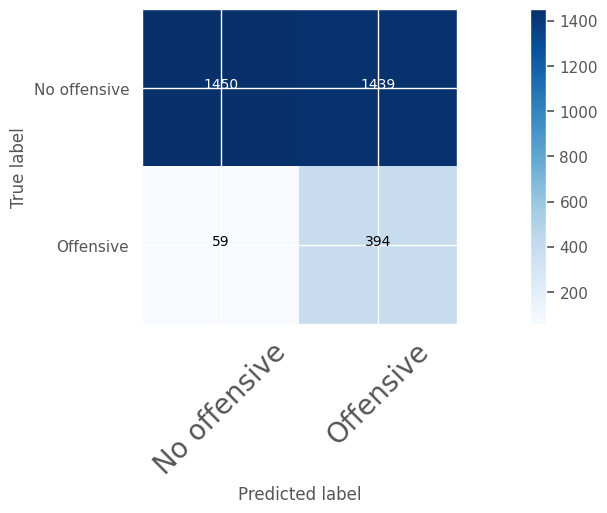

F1 Macro: 0.5020


0.502048771870774

In [79]:
from transformers import pipeline
from tqdm import tqdm

# Multilingual zero-shot NLI model; no task-specific training required
ZS_MODEL = "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli"
zs_pipe  = pipeline(
    "zero-shot-classification",
    model=ZS_MODEL,
    device=0 if torch.cuda.is_available() else -1,
)

# Candidate labels in English; NLI model is English-centric but supports multilingual
candidate_labels = ["offensive comment", "non-offensive comment"]
label_map_zs = {"offensive comment": "Offensive", "non-offensive comment": "No offensive"}

test_texts_zs   = test_set['comment'].tolist()
ZS_BATCH_SIZE   = 32
zs_ctx_preds_labels = []

for i in tqdm(range(0, len(test_texts_zs), ZS_BATCH_SIZE), desc="Zero-shot inference"):
    batch = [t[:500] for t in test_texts_zs[i:i + ZS_BATCH_SIZE]]
    results = zs_pipe(batch, candidate_labels=candidate_labels, multi_label=False)
    for r in results:
        zs_ctx_preds_labels.append(label_map_zs[r['labels'][0]])

evaluate_all(y_test_labels, zs_ctx_preds_labels, target_labels)

## Large Language models
Modelos que generan texto

### Fine tuning


Loading checkpoint shards:   0%|                                    | 0/3 [00:00<?, ?it/s]


Loading checkpoint shards:  33%|█████████▎                  | 1/3 [00:06<00:13,  6.79s/it]


Loading checkpoint shards:  67%|██████████████████▋         | 2/3 [00:13<00:07,  7.00s/it]


Loading checkpoint shards: 100%|████████████████████████████| 3/3 [00:19<00:00,  6.57s/it]


Loading checkpoint shards: 100%|████████████████████████████| 3/3 [00:19<00:00,  6.67s/it]

...


LLM inference: 100%|███████████████████████████████████▊| 416/418 [10:50<00:03,  1.87s/it]


LLM inference: 100%|███████████████████████████████████▉| 417/418 [10:51<00:01,  1.72s/it]


LLM inference: 100%|████████████████████████████████████| 418/418 [10:52<00:00,  1.56s/it]


LLM inference: 100%|████████████████████████████████████| 418/418 [10:52<00:00,  1.56s/it]

Classification Report
              precision    recall  f1-score   support

No offensive       0.89      0.99      0.94      2889
   Offensive       0.71      0.23      0.34       453

    accuracy                           0.88      3342
   macro avg       0.80      0.61      0.64      3342
weighted avg       0.87      0.88      0.86      3342

Confusion matrix, without normalization


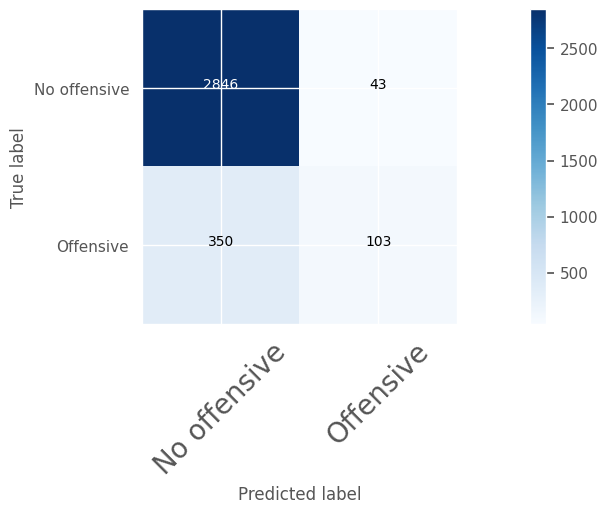

F1 Macro: 0.6397


0.6396607328291606

In [80]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
from torch.utils.data import Dataset as TorchDataset, DataLoader
import torch, re

LLM_MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.3"

llm_tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL_NAME)
llm_tokenizer.pad_token = llm_tokenizer.eos_token

quant_cfg = BitsAndBytesConfig(load_in_8bit=True)
llm_base = AutoModelForCausalLM.from_pretrained(
    LLM_MODEL_NAME, quantization_config=quant_cfg, device_map="auto"
)
llm_base.eval()
print(f"Base model loaded  ({sum(p.numel() for p in llm_base.parameters())/1e9:.2f}B params)")


# ── Helper shared by all LLM sections ────────────────────────────────────────
def parse_offense_label(text: str) -> str:
    t = text.lower().strip()
    if "no offensive" in t or "not offensive" in t or "non-offensive" in t or "non offensive" in t:
        return "No offensive"
    if "offensive" in t:
        return "Offensive"
    return "No offensive"   # safe default for Spanish comments that are mostly non-offensive


LLM_MAX_NEW   = 8
LLM_TEMP      = 0.1
LLM_BATCH     = 8
LLM_MAX_INPUT = 512

def llm_generate(prompts, model):
    outputs = []
    model.eval()
    for i in tqdm(range(0, len(prompts), LLM_BATCH), desc="LLM inference"):
        batch = prompts[i:i + LLM_BATCH]
        enc   = llm_tokenizer(batch, return_tensors="pt", padding=True,
                              truncation=True, max_length=LLM_MAX_INPUT)
        enc   = {k: v.to(model.device) for k, v in enc.items()}
        with torch.no_grad():
            gen = model.generate(
                **enc, max_new_tokens=LLM_MAX_NEW, temperature=LLM_TEMP,
                do_sample=True, pad_token_id=llm_tokenizer.eos_token_id,
            )
        decoded = llm_tokenizer.batch_decode(
            gen[:, enc["input_ids"].shape[1]:], skip_special_tokens=True
        )
        outputs.extend(decoded)
    return outputs


# ── LoRA fine-tuning ──────────────────────────────────────────────────────────
def format_instruct(comment, label):
    return (
        f'[INST] Clasifica este comentario de YouTube en español como '
        f'"Offensive" o "No offensive". Solo responde con la etiqueta.\n'
        f'Comentario: {comment[:300]} [/INST] {label}'
    )

FT_SUBSET = 800
ft_df  = training_set.sample(FT_SUBSET, random_state=42)
ft_texts = [format_instruct(row['comment'], row['joint_label']) for _, row in ft_df.iterrows()]

ft_enc = llm_tokenizer(ft_texts, padding=True, truncation=True, max_length=256, return_tensors="pt")

class InstructDS(TorchDataset):
    def __init__(self, enc):
        self.ids  = enc["input_ids"]
        self.mask = enc["attention_mask"]
    def __len__(self):  return len(self.ids)
    def __getitem__(self, i):
        return {"input_ids": self.ids[i], "attention_mask": self.mask[i],
                "labels": self.ids[i].clone()}

lora_cfg = LoraConfig(
    task_type=TaskType.CAUSAL_LM, r=8, lora_alpha=16,
    target_modules=["q_proj", "v_proj"], lora_dropout=0.05, bias="none",
)
lora_model = get_peft_model(prepare_model_for_kbit_training(llm_base), lora_cfg)
lora_model.print_trainable_parameters()

ft_loader  = DataLoader(InstructDS(ft_enc), batch_size=4, shuffle=True)
opt_lora   = torch.optim.AdamW(lora_model.parameters(), lr=2e-4)

lora_model.train()
for step, batch in enumerate(ft_loader):
    if step >= 100:
        break
    ids    = batch["input_ids"].to(lora_model.device)
    mask   = batch["attention_mask"].to(lora_model.device)
    labels = batch["labels"].to(lora_model.device)
    loss   = lora_model(input_ids=ids, attention_mask=mask, labels=labels).loss
    loss.backward()
    opt_lora.step()
    opt_lora.zero_grad()
    if step % 25 == 0:
        print(f"Step {step:3d}  loss={loss.item():.4f}")

lora_model.eval()

# ── Predictions with LoRA model ───────────────────────────────────────────────
def zs_prompt(comment):
    return (
        f"[INST] Clasifica este comentario de YouTube en español como "
        f'"Offensive" o "No offensive". Solo responde con la etiqueta.\n'
        f"Comentario: {comment} [/INST]"
    )

test_comments_llm = test_set['comment'].tolist()
lora_prompts      = [zs_prompt(c) for c in test_comments_llm]
lora_outputs      = llm_generate(lora_prompts, lora_model)
lora_preds        = [parse_offense_label(o) for o in lora_outputs]

evaluate_all(y_test_labels, lora_preds, target_labels)

### Zero-shot


LLM inference:   0%|                                              | 0/418 [00:00<?, ?it/s]


LLM inference:   0%|                                      | 1/418 [00:00<06:28,  1.07it/s]


LLM inference:   0%|▏                                     | 2/418 [00:01<06:26,  1.08it/s]


LLM inference:   1%|▎                                     | 3/418 [00:03<08:53,  1.29s/it]


LLM inference:   1%|▎                                     | 4/418 [00:04<09:01,  1.31s/it]

...


LLM inference: 100%|███████████████████████████████████▊| 416/418 [09:00<00:03,  1.77s/it]


LLM inference: 100%|███████████████████████████████████▉| 417/418 [09:01<00:01,  1.55s/it]


LLM inference: 100%|████████████████████████████████████| 418/418 [09:02<00:00,  1.30s/it]


LLM inference: 100%|████████████████████████████████████| 418/418 [09:02<00:00,  1.30s/it]

Classification Report
              precision    recall  f1-score   support

No offensive       0.99      0.46      0.63      2889
   Offensive       0.22      0.97      0.36       453

    accuracy                           0.53      3342
   macro avg       0.60      0.72      0.50      3342
weighted avg       0.88      0.53      0.60      3342

Confusion matrix, without normalization


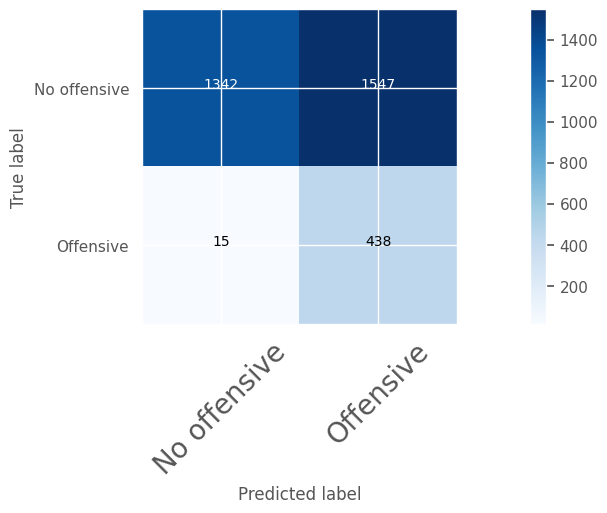

F1 Macro: 0.4957


0.4957176314570254

In [81]:
# Uses llm_base (without LoRA) and helpers defined in the Fine-tuning section.
# Disable LoRA adapters so we evaluate the base model in isolation.
lora_model.disable_adapter_layers()

zs_llm_prompts = [zs_prompt(c) for c in test_comments_llm]
zs_llm_outputs = llm_generate(zs_llm_prompts, lora_model)
zs_llm_preds   = [parse_offense_label(o) for o in zs_llm_outputs]

evaluate_all(y_test_labels, zs_llm_preds, target_labels)

### Few-shot


LLM inference:   0%|                                              | 0/418 [00:00<?, ?it/s]


LLM inference:   0%|                                      | 1/418 [00:02<14:15,  2.05s/it]


LLM inference:   0%|▏                                     | 2/418 [00:04<13:57,  2.01s/it]


LLM inference:   1%|▎                                     | 3/418 [00:07<17:15,  2.49s/it]


LLM inference:   1%|▎                                     | 4/418 [00:09<16:53,  2.45s/it]

...


LLM inference: 100%|███████████████████████████████████▊| 416/418 [16:21<00:04,  2.46s/it]


LLM inference: 100%|███████████████████████████████████▉| 417/418 [16:23<00:02,  2.34s/it]


LLM inference: 100%|████████████████████████████████████| 418/418 [16:24<00:00,  2.16s/it]


LLM inference: 100%|████████████████████████████████████| 418/418 [16:24<00:00,  2.36s/it]

Classification Report
              precision    recall  f1-score   support

No offensive       0.96      0.85      0.90      2889
   Offensive       0.45      0.77      0.56       453

    accuracy                           0.84      3342
   macro avg       0.70      0.81      0.73      3342
weighted avg       0.89      0.84      0.86      3342

Confusion matrix, without normalization


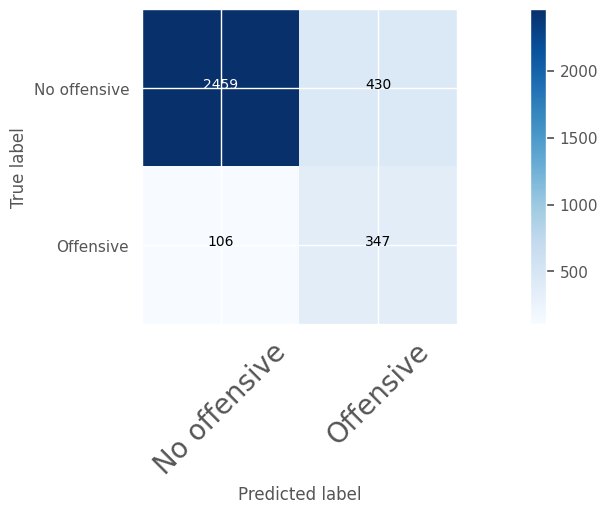

F1 Macro: 0.7330


0.7329755739801622

In [82]:
# LoRA adapters remain disabled (zero-shot cell did that); base model is used here too.
NUM_FS = 2  # examples per class

def select_fs_examples(df, num_per_class=2, seed=42):
    examples = []
    for label in ['No offensive', 'Offensive']:
        pool = df[df['joint_label'] == label].sample(num_per_class, random_state=seed)
        for _, row in pool.iterrows():
            examples.append((row['comment'][:200], label))
    return examples


def fs_prompt(comment, examples):
    header = (
        'Clasifica el siguiente comentario de YouTube en español como '
        '"Offensive" o "No offensive". Solo responde con la etiqueta.\n\n'
    )
    shots = "".join(
        f"Comentario: {ex_text}\nEtiqueta: {ex_label}\n\n"
        for ex_text, ex_label in examples
    )
    return header + shots + f"Comentario: {comment}\nEtiqueta:"


fs_examples   = select_fs_examples(training_set, num_per_class=NUM_FS)
fs_llm_prompts = [fs_prompt(c, fs_examples) for c in test_comments_llm]
fs_llm_outputs = llm_generate(fs_llm_prompts, lora_model)
fs_llm_preds   = [parse_offense_label(o) for o in fs_llm_outputs]

evaluate_all(y_test_labels, fs_llm_preds, target_labels)